In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

/Users/apple/Desktop/chooser_option_project/venv/lib/python3.8/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [12]:
jpm = yf.download("JPM", start="2018-01-01", end="2025-01-01")
jpm.head()

Failed to get ticker 'JPM' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%%**********************]  1 of 1 completed

1 Failed download:
['JPM']: Exception('%ticker%: No timezone found, symbol may be delisted')


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


In [3]:
rates = pdr.DataReader("DGS1", "fred", "2018-01-01", "2024-12-31")
rates.head()

,DGS1
DATE,
2018-01-01,NaN
2018-01-02,1.83
2018-01-03,1.81
2018-01-04,1.82
2018-01-05,1.80


In [4]:
jpm2 = pdr.DataReader("JPM", "stooq", "2018-01-01", "2024-12-31")
jpm2.head()

ParserError: Error tokenizing data. C error: Expected 1 fields in line 6, saw 2


In [5]:
jpm3 = pdr.DataReader("JPM", "yahoo", "2018-01-01", "2024-12-31")
jpm3.head()

RemoteDataError: Unable to read URL: https://finance.yahoo.com/quote/JPM/history?period1=1514750400&period2=1735675199&interval=1d&frequency=1d&filter=history
Response Text:
b'<html><meta charset=\'utf-8\'>\n<script>\nif(window != window.top){\ndocument.write(\'<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t=\'\n    + new Date().getTime() + \'&_R=\'\n    + encodeURIComponent(document.referrer)\n    + \'&err=404\'\n    + \'" width="0px" height="0px"/>\');\n}else{\nwindow.location.replace(\'https://\' + window.location.host + \'/?err=404\');\n}\n</script>\n<noscript>\n<META http-equiv="refresh" content="0;URL=https://finance.yahoo.com/?err=404">\n</noscript></html>'

In [6]:
rates.to_csv("data/raw/treasury_1y_raw.csv")

In [7]:
import requests
import pandas as pd

api_key = "LTX1CWKCFSTVYKS2"
symbol = "JPM"

url = (
    f"https://www.alphavantage.co/query?"
    f"function=TIME_SERIES_DAILY_ADJUSTED&symbol={symbol}"
    f"&outputsize=full&apikey={api_key}"
)

response = requests.get(url)
data = response.json()

list(data.keys())[:10]

['Information']

In [8]:
print(data["Information"])

Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints


In [11]:
import requests
import pandas as pd

api_key = "LTX1CWKCFSTVYKS2"
symbol = "JPM"

url = (
    f"https://www.alphavantage.co/query?"
    f"function=TIME_SERIES_DAILY&symbol={symbol}"
    f"&apikey={api_key}"
)

response = requests.get(url)
data = response.json()
list(data.keys())

['Meta Data', 'Time Series (Daily)']

In [15]:
jpm = yf.download(
    "JPM",
    start="2018-01-01",
    end="2025-01-01",
    progress=False,
    threads=False,
    auto_adjust=False
)
jpm.head()

Failed to get ticker 'JPM' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['JPM']: Exception('%ticker%: No timezone found, symbol may be delisted')


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


In [16]:
ticker = yf.Ticker("JPM")
info = ticker.fast_info
info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [17]:
import os

os.listdir("data/raw")

['.DS_Store',
 'JPMorgan Stock Price History.csv',
 'CBOE Volatility Index Historical Data.csv',
 'treasury_1y_raw.csv']

In [19]:
jpm_manual = pd.read_csv("data/raw/JPMorgan Stock Price History.csv")
jpm_manual.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/31/2024,239.71,240.05,241.44,239.03,4.87M,0.16%
1,12/30/2024,239.32,238.77,240.84,237.11,5.72M,-0.77%
2,12/27/2024,241.17,242.72,243.39,240.04,5.73M,-0.81%
3,12/26/2024,243.14,241.43,243.26,240.79,4.45M,0.34%
4,12/24/2024,242.31,239.43,242.49,239.07,3.73M,1.64%


In [20]:
jpm_manual.columns.tolist()

['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

In [21]:
vix_manual = pd.read_csv("data/raw/CBOE Volatility Index Historical Data.csv")
vix_manual.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/31/2024,17.35,17.39,17.81,16.68,NaN,-0.29%
1,12/30/2024,17.40,17.21,19.22,16.44,NaN,9.09%
2,12/27/2024,15.95,15.38,18.45,15.29,NaN,8.28%
3,12/26/2024,14.73,14.99,15.93,14.55,NaN,3.22%
4,12/24/2024,14.27,16.97,17.04,14.27,NaN,-14.96%


In [22]:
vix_manual.columns.tolist()

['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

In [23]:
rates_saved = pd.read_csv("data/raw/treasury_1y_raw.csv")
rates_saved.head()

,DATE,DGS1
0,2018-01-01,NaN
1,2018-01-02,1.83
2,2018-01-03,1.81
3,2018-01-04,1.82
4,2018-01-05,1.80


In [24]:
rates_clean = rates_saved.copy()

rates_clean["DATE"] = pd.to_datetime(rates_clean["DATE"])
rates_clean = rates_clean.rename(columns={"DATE": "Date", "DGS1": "Treasury_1Y"})
rates_clean = rates_clean.sort_values("Date").reset_index(drop=True)

rates_clean.head()

,Date,Treasury_1Y
0,2018-01-01,NaN
1,2018-01-02,1.83
2,2018-01-03,1.81
3,2018-01-04,1.82
4,2018-01-05,1.80


In [25]:
rates_clean.tail()

,Date,Treasury_1Y
1822,2024-12-25,NaN
1823,2024-12-26,4.23
1824,2024-12-27,4.20
1825,2024-12-30,4.17
1826,2024-12-31,4.16


In [26]:
jpm_clean = jpm_manual.copy()

jpm_clean["Date"] = pd.to_datetime(jpm_clean["Date"], format="%m/%d/%Y")

jpm_clean = jpm_clean.rename(columns={
    "Price": "Close",
    "Vol.": "Volume",
    "Change %": "ChangePct"
})

jpm_clean = jpm_clean.sort_values("Date").reset_index(drop=True)

jpm_clean.head()

,Date,Close,Open,High,Low,Volume,ChangePct
0,2018-01-02,107.95,107.63,108.02,106.81,13.58M,0.94%
1,2018-01-03,108.06,107.86,108.49,107.48,11.90M,0.10%
2,2018-01-04,109.04,108.36,110.03,108.20,12.95M,0.91%
3,2018-01-05,108.34,109.26,109.55,107.78,14.15M,-0.64%
4,2018-01-08,108.50,108.15,108.68,107.70,12.47M,0.15%


In [27]:
jpm_clean.tail()

,Date,Close,Open,High,Low,Volume,ChangePct
1756,2024-12-24,242.31,239.43,242.49,239.07,3.73M,1.64%
1757,2024-12-26,243.14,241.43,243.26,240.79,4.45M,0.34%
1758,2024-12-27,241.17,242.72,243.39,240.04,5.73M,-0.81%
1759,2024-12-30,239.32,238.77,240.84,237.11,5.72M,-0.77%
1760,2024-12-31,239.71,240.05,241.44,239.03,4.87M,0.16%


In [28]:
def convert_volume(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x.endswith("M"):
        return float(x[:-1]) * 1_000_000
    elif x.endswith("K"):
        return float(x[:-1]) * 1_000
    elif x.endswith("B"):
        return float(x[:-1]) * 1_000_000_000
    else:
        return float(x)

jpm_clean["Volume"] = jpm_clean["Volume"].apply(convert_volume)
jpm_clean["ChangePct"] = jpm_clean["ChangePct"].str.replace("%", "", regex=False).astype(float)

numeric_cols = ["Open", "High", "Low", "Close"]
jpm_clean[numeric_cols] = jpm_clean[numeric_cols].astype(float)

jpm_clean.head()

,Date,Close,Open,High,Low,Volume,ChangePct
0,2018-01-02,107.95,107.63,108.02,106.81,13580000.0,0.94
1,2018-01-03,108.06,107.86,108.49,107.48,11900000.0,0.10
2,2018-01-04,109.04,108.36,110.03,108.20,12950000.0,0.91
3,2018-01-05,108.34,109.26,109.55,107.78,14150000.0,-0.64
4,2018-01-08,108.50,108.15,108.68,107.70,12470000.0,0.15


In [29]:
jpm_clean.dtypes

Date         datetime64[ns]
Close               float64
Open                float64
High                float64
Low                 float64
Volume              float64
ChangePct           float64
dtype: object

In [30]:
jpm_clean.to_csv("data/processed/jpm_prices_clean.csv", index=False)

In [33]:
vix_clean = vix_manual.copy()

vix_clean["Date"] = pd.to_datetime(vix_clean["Date"], format="%m/%d/%Y")

vix_clean = vix_clean.rename(columns={
    "Price": "Close",
    "Vol.": "Volume",
    "Change %": "ChangePct"
})

vix_clean = vix_clean.sort_values("Date").reset_index(drop=True)

vix_clean.head()

,Date,Close,Open,High,Low,Volume,ChangePct
0,2018-01-02,9.77,10.95,11.07,9.52,NaN,-11.50%
1,2018-01-03,9.15,9.56,9.65,8.94,NaN,-6.35%
2,2018-01-04,9.22,9.01,9.31,8.92,NaN,0.77%
3,2018-01-05,9.22,9.10,9.54,9.00,NaN,0.00%
4,2018-01-08,9.52,9.61,9.89,9.32,NaN,3.25%


In [34]:
vix_clean.tail()

,Date,Close,Open,High,Low,Volume,ChangePct
1787,2024-12-24,14.27,16.97,17.04,14.27,NaN,-14.96%
1788,2024-12-26,14.73,14.99,15.93,14.55,NaN,3.22%
1789,2024-12-27,15.95,15.38,18.45,15.29,NaN,8.28%
1790,2024-12-30,17.40,17.21,19.22,16.44,NaN,9.09%
1791,2024-12-31,17.35,17.39,17.81,16.68,NaN,-0.29%


In [35]:
vix_clean["Volume"] = vix_clean["Volume"].apply(convert_volume)
vix_clean["ChangePct"] = vix_clean["ChangePct"].str.replace("%", "", regex=False).astype(float)

numeric_cols_vix = ["Open", "High", "Low", "Close"]
vix_clean[numeric_cols_vix] = vix_clean[numeric_cols_vix].astype(float)

vix_clean.head()

,Date,Close,Open,High,Low,Volume,ChangePct
0,2018-01-02,9.77,10.95,11.07,9.52,None,-11.50
1,2018-01-03,9.15,9.56,9.65,8.94,None,-6.35
2,2018-01-04,9.22,9.01,9.31,8.92,None,0.77
3,2018-01-05,9.22,9.10,9.54,9.00,None,0.00
4,2018-01-08,9.52,9.61,9.89,9.32,None,3.25


In [36]:
vix_clean.dtypes

Date         datetime64[ns]
Close               float64
Open                float64
High                float64
Low                 float64
Volume               object
ChangePct           float64
dtype: object

In [37]:
vix_clean.to_csv("data/processed/vix_clean.csv", index=False)

In [38]:
rates_clean.to_csv("data/processed/treasury_1y_clean.csv", index=False)

In [39]:
jpm_merge = jpm_clean[["Date", "Close"]].rename(columns={"Close": "JPM_Close"})
vix_merge = vix_clean[["Date", "Close"]].rename(columns={"Close": "VIX_Close"})
rates_merge = rates_clean.copy()

merged_preview = jpm_merge.merge(vix_merge, on="Date", how="outer")
merged_preview = merged_preview.merge(rates_merge, on="Date", how="outer")

merged_preview = merged_preview.sort_values("Date").reset_index(drop=True)

merged_preview.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y
0,2018-01-01,NaN,NaN,NaN
1,2018-01-02,107.95,9.77,1.83
2,2018-01-03,108.06,9.15,1.81
3,2018-01-04,109.04,9.22,1.82
4,2018-01-05,108.34,9.22,1.80


In [40]:
merged_preview.tail()

,Date,JPM_Close,VIX_Close,Treasury_1Y
1822,2024-12-25,NaN,NaN,NaN
1823,2024-12-26,243.14,14.73,4.23
1824,2024-12-27,241.17,15.95,4.20
1825,2024-12-30,239.32,17.40,4.17
1826,2024-12-31,239.71,17.35,4.16


In [41]:
merged_preview.isna().sum()

Date            0
JPM_Close      66
VIX_Close      35
Treasury_1Y    77
dtype: int64

In [42]:
merged_preview.to_csv("data/processed/merged_preview.csv", index=False)

In [43]:
summary = {
    "dataset": ["JPM", "VIX", "Treasury_1Y"],
    "rows": [len(jpm_clean), len(vix_clean), len(rates_clean)],
    "start_date": [
        str(jpm_clean["Date"].min().date()),
        str(vix_clean["Date"].min().date()),
        str(rates_clean["Date"].min().date())
    ],
    "end_date": [
        str(jpm_clean["Date"].max().date()),
        str(vix_clean["Date"].max().date()),
        str(rates_clean["Date"].max().date())
    ]
}

summary_df = pd.DataFrame(summary)
summary_df

,dataset,rows,start_date,end_date
0,JPM,1761,2018-01-02,2024-12-31
1,VIX,1792,2018-01-02,2024-12-31
2,Treasury_1Y,1827,2018-01-01,2024-12-31


In [44]:
summary_df.to_csv("outputs/week1_data_summary.csv", index=False)

In [45]:
vix_clean["Volume"] = pd.to_numeric(vix_clean["Volume"], errors="coerce")
vix_clean.dtypes

Date         datetime64[ns]
Close               float64
Open                float64
High                float64
Low                 float64
Volume              float64
ChangePct           float64
dtype: object

In [46]:
vix_clean.to_csv("data/processed/vix_clean.csv", index=False)

In [47]:
print("JPM missing values:")
print(jpm_clean.isna().sum())
print()

print("VIX missing values:")
print(vix_clean.isna().sum())
print()

print("Treasury missing values:")
print(rates_clean.isna().sum())

JPM missing values:
Date         0
Close        0
Open         0
High         0
Low          0
Volume       0
ChangePct    0
dtype: int64

VIX missing values:
Date            0
Close           0
Open            0
High            0
Low             0
Volume       1792
ChangePct       0
dtype: int64

Treasury missing values:
Date            0
Treasury_1Y    77
dtype: int64


In [48]:
print("Merged preview missing values:")
print(merged_preview.isna().sum())

Merged preview missing values:
Date            0
JPM_Close      66
VIX_Close      35
Treasury_1Y    77
dtype: int64


In [49]:
missing_rows = merged_preview[merged_preview.isna().any(axis=1)]
missing_rows.head(10)

,Date,JPM_Close,VIX_Close,Treasury_1Y
0,2018-01-01,NaN,NaN,NaN
10,2018-01-15,NaN,NaN,NaN
35,2018-02-19,NaN,NaN,NaN
64,2018-03-30,NaN,NaN,NaN
105,2018-05-28,NaN,NaN,NaN
132,2018-07-04,NaN,NaN,NaN
175,2018-09-03,NaN,NaN,NaN
200,2018-10-08,115.32,15.69,NaN
225,2018-11-12,108.95,20.45,NaN
233,2018-11-22,NaN,NaN,NaN


In [50]:
len(missing_rows)

79

In [51]:
model_data = merged_preview.copy()

model_data = model_data[["Date", "JPM_Close", "VIX_Close", "Treasury_1Y"]].copy()

model_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y
0,2018-01-01,NaN,NaN,NaN
1,2018-01-02,107.95,9.77,1.83
2,2018-01-03,108.06,9.15,1.81
3,2018-01-04,109.04,9.22,1.82
4,2018-01-05,108.34,9.22,1.80


In [52]:
model_data["Treasury_1Y"] = model_data["Treasury_1Y"].ffill()
model_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y
0,2018-01-01,NaN,NaN,NaN
1,2018-01-02,107.95,9.77,1.83
2,2018-01-03,108.06,9.15,1.81
3,2018-01-04,109.04,9.22,1.82
4,2018-01-05,108.34,9.22,1.80


In [53]:
model_data = model_data.dropna(subset=["JPM_Close", "VIX_Close"]).reset_index(drop=True)
model_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y
0,2018-01-02,107.95,9.77,1.83
1,2018-01-03,108.06,9.15,1.81
2,2018-01-04,109.04,9.22,1.82
3,2018-01-05,108.34,9.22,1.80
4,2018-01-08,108.50,9.52,1.79


In [54]:
print(model_data.isna().sum())
print()
print(model_data.shape)

Date           0
JPM_Close      0
VIX_Close      0
Treasury_1Y    0
dtype: int64

(1761, 4)


In [55]:
print(model_data["Date"].min())
print(model_data["Date"].max())
print(model_data.head())
print(model_data.tail())

2018-01-02 00:00:00
2024-12-31 00:00:00
        Date  JPM_Close  VIX_Close  Treasury_1Y
0 2018-01-02     107.95       9.77         1.83
1 2018-01-03     108.06       9.15         1.81
2 2018-01-04     109.04       9.22         1.82
3 2018-01-05     108.34       9.22         1.80
4 2018-01-08     108.50       9.52         1.79
           Date  JPM_Close  VIX_Close  Treasury_1Y
1756 2024-12-24     242.31      14.27         4.24
1757 2024-12-26     243.14      14.73         4.23
1758 2024-12-27     241.17      15.95         4.20
1759 2024-12-30     239.32      17.40         4.17
1760 2024-12-31     239.71      17.35         4.16


In [56]:
model_data.to_csv("data/processed/model_data_base.csv", index=False)

In [57]:
feature_data = model_data.copy()
feature_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y
0,2018-01-02,107.95,9.77,1.83
1,2018-01-03,108.06,9.15,1.81
2,2018-01-04,109.04,9.22,1.82
3,2018-01-05,108.34,9.22,1.80
4,2018-01-08,108.50,9.52,1.79


In [58]:
feature_data["JPM_Return"] = feature_data["JPM_Close"].pct_change()
feature_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return
0,2018-01-02,107.95,9.77,1.83,NaN
1,2018-01-03,108.06,9.15,1.81,0.001019
2,2018-01-04,109.04,9.22,1.82,0.009069
3,2018-01-05,108.34,9.22,1.80,-0.006420
4,2018-01-08,108.50,9.52,1.79,0.001477


In [59]:
import numpy as np

feature_data["JPM_LogReturn"] = np.log(feature_data["JPM_Close"] / feature_data["JPM_Close"].shift(1))
feature_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn
0,2018-01-02,107.95,9.77,1.83,NaN,NaN
1,2018-01-03,108.06,9.15,1.81,0.001019,0.001018
2,2018-01-04,109.04,9.22,1.82,0.009069,0.009028
3,2018-01-05,108.34,9.22,1.80,-0.006420,-0.006440
4,2018-01-08,108.50,9.52,1.79,0.001477,0.001476


In [60]:
feature_data["VIX_Return"] = feature_data["VIX_Close"].pct_change()
feature_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn,VIX_Return
0,2018-01-02,107.95,9.77,1.83,NaN,NaN,NaN
1,2018-01-03,108.06,9.15,1.81,0.001019,0.001018,-0.063460
2,2018-01-04,109.04,9.22,1.82,0.009069,0.009028,0.007650
3,2018-01-05,108.34,9.22,1.80,-0.006420,-0.006440,0.000000
4,2018-01-08,108.50,9.52,1.79,0.001477,0.001476,0.032538


In [61]:
feature_data["Treasury_1Y_Change"] = feature_data["Treasury_1Y"].diff()
feature_data.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change
0,2018-01-02,107.95,9.77,1.83,NaN,NaN,NaN,NaN
1,2018-01-03,108.06,9.15,1.81,0.001019,0.001018,-0.063460,-0.02
2,2018-01-04,109.04,9.22,1.82,0.009069,0.009028,0.007650,0.01
3,2018-01-05,108.34,9.22,1.80,-0.006420,-0.006440,0.000000,-0.02
4,2018-01-08,108.50,9.52,1.79,0.001477,0.001476,0.032538,-0.01


In [62]:
feature_data["JPM_Vol_5D"] = feature_data["JPM_LogReturn"].rolling(window=5).std()

In [65]:
feature_data["JPM_Vol_10D"] = feature_data["JPM_LogReturn"].rolling(window=10).std()

In [64]:
feature_data["JPM_Vol_20D"] = feature_data["JPM_LogReturn"].rolling(window=20).std()

In [66]:
feature_data.head(10)

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D
0,2018-01-02,107.95,9.77,1.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-03,108.06,9.15,1.81,0.001019,0.001018,-0.063460,-0.02,NaN,NaN,NaN
2,2018-01-04,109.04,9.22,1.82,0.009069,0.009028,0.007650,0.01,NaN,NaN,NaN
3,2018-01-05,108.34,9.22,1.80,-0.006420,-0.006440,0.000000,-0.02,NaN,NaN,NaN
4,2018-01-08,108.50,9.52,1.79,0.001477,0.001476,0.032538,-0.01,NaN,NaN,NaN
5,2018-01-09,109.05,10.08,1.78,0.005069,0.005056,0.058824,-0.01,0.005727,NaN,NaN
6,2018-01-10,110.25,9.82,1.78,0.011004,0.010944,-0.025794,0.00,0.006892,NaN,NaN
7,2018-01-11,110.84,9.88,1.77,0.005351,0.005337,0.006110,-0.01,0.006400,NaN,NaN
8,2018-01-12,112.67,10.16,1.78,0.016510,0.016375,0.028340,0.01,0.005852,NaN,NaN
9,2018-01-16,112.27,11.66,1.79,-0.003550,-0.003557,0.147638,0.01,0.007438,NaN,NaN


In [67]:
feature_data.isna().sum()

Date                   0
JPM_Close              0
VIX_Close              0
Treasury_1Y            0
JPM_Return             1
JPM_LogReturn          1
VIX_Return             1
Treasury_1Y_Change     1
JPM_Vol_5D             5
JPM_Vol_10D           10
JPM_Vol_20D           20
dtype: int64

In [68]:
feature_data_clean = feature_data.dropna().reset_index(drop=True)
feature_data_clean.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D
0,2018-01-31,115.67,13.54,1.90,0.004865,0.004853,-0.084517,0.02,0.005960,0.006625,0.006622
1,2018-02-01,116.87,13.47,1.89,0.010374,0.010321,-0.005170,-0.01,0.007554,0.007089,0.006767
2,2018-02-02,114.28,17.31,1.88,-0.022161,-0.022411,0.285078,-0.01,0.012841,0.010727,0.008849
3,2018-02-05,108.80,37.32,1.85,-0.047952,-0.049140,1.155979,-0.03,0.023822,0.018506,0.014455
4,2018-02-06,112.11,29.98,1.87,0.030423,0.029969,-0.196677,0.02,0.030845,0.021578,0.015917


In [69]:
feature_data_clean.tail()

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D
1736,2024-12-24,242.31,14.27,4.24,0.016444,0.016310,-0.149583,-0.02,0.021791,0.015277,0.011852
1737,2024-12-26,243.14,14.73,4.23,0.003425,0.003420,0.032235,-0.01,0.007425,0.015293,0.011906
1738,2024-12-27,241.17,15.95,4.20,-0.008102,-0.008135,0.082824,-0.03,0.011224,0.015286,0.011999
1739,2024-12-30,239.32,17.40,4.17,-0.007671,-0.007701,0.090909,-0.03,0.010047,0.015342,0.012066
1740,2024-12-31,239.71,17.35,4.16,0.001630,0.001628,-0.002874,-0.01,0.009997,0.015345,0.011759


In [70]:
print(feature_data_clean.shape)
print(feature_data_clean.isna().sum())

(1741, 11)
Date                  0
JPM_Close             0
VIX_Close             0
Treasury_1Y           0
JPM_Return            0
JPM_LogReturn         0
VIX_Return            0
Treasury_1Y_Change    0
JPM_Vol_5D            0
JPM_Vol_10D           0
JPM_Vol_20D           0
dtype: int64


In [71]:
feature_data_clean.to_csv("data/processed/feature_data_base.csv", index=False)

In [72]:
feature_data_clean.columns.tolist()

['Date',
 'JPM_Close',
 'VIX_Close',
 'Treasury_1Y',
 'JPM_Return',
 'JPM_LogReturn',
 'VIX_Return',
 'Treasury_1Y_Change',
 'JPM_Vol_5D',
 'JPM_Vol_10D',
 'JPM_Vol_20D']

In [73]:
feature_data_clean.describe()

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D
count,1741,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000
mean,2021-07-16 03:49:06.582424064,138.008507,19.972269,2.494095,0.000597,0.000421,0.003567,0.001310,0.014750,0.015480,0.015988
min,2018-01-31 00:00:00,79.030000,10.850000,0.040000,-0.149649,-0.162106,-0.281566,-0.600000,0.001158,0.002880,0.004685
25%,2019-10-23 00:00:00,111.290000,14.640000,0.270000,-0.007927,-0.007959,-0.044152,-0.010000,0.008180,0.009609,0.010797
50%,2021-07-16 00:00:00,131.740000,18.150000,2.340000,0.000560,0.000560,-0.008306,0.000000,0.012086,0.013170,0.013881
75%,2023-04-10 00:00:00,155.480000,22.960000,4.520000,0.009083,0.009042,0.035119,0.010000,0.017458,0.017451,0.017631
max,2024-12-31 00:00:00,250.290000,82.690000,5.490000,0.180125,0.165620,1.155979,0.340000,0.135449,0.105834,0.086093
std,NaN,34.981926,7.693901,1.889360,0.018753,0.018716,0.088621,0.046467,0.011995,0.010751,0.009862


In [74]:
feature_data_clean[[
    "JPM_Return",
    "JPM_LogReturn",
    "VIX_Return",
    "Treasury_1Y_Change",
    "JPM_Vol_5D",
    "JPM_Vol_10D",
    "JPM_Vol_20D"
]].describe()

,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D
count,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000
mean,0.000597,0.000421,0.003567,0.001310,0.014750,0.015480,0.015988
std,0.018753,0.018716,0.088621,0.046467,0.011995,0.010751,0.009862
min,-0.149649,-0.162106,-0.281566,-0.600000,0.001158,0.002880,0.004685
25%,-0.007927,-0.007959,-0.044152,-0.010000,0.008180,0.009609,0.010797
50%,0.000560,0.000560,-0.008306,0.000000,0.012086,0.013170,0.013881
75%,0.009083,0.009042,0.035119,0.010000,0.017458,0.017451,0.017631
max,0.180125,0.165620,1.155979,0.340000,0.135449,0.105834,0.086093


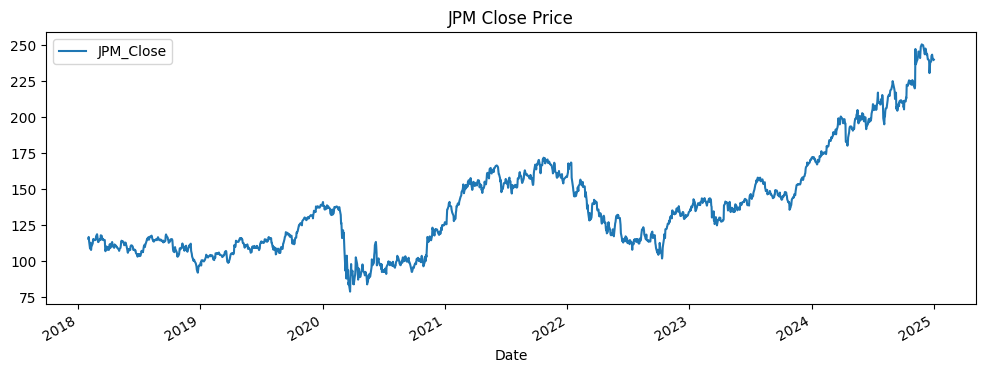

In [83]:
feature_data_clean.plot(x="Date", y="JPM_Close", figsize=(12, 4), title="JPM Close Price")
plt.savefig("outputs/jpm_close_price.png", dpi=300, bbox_inches="tight")
plt.show()

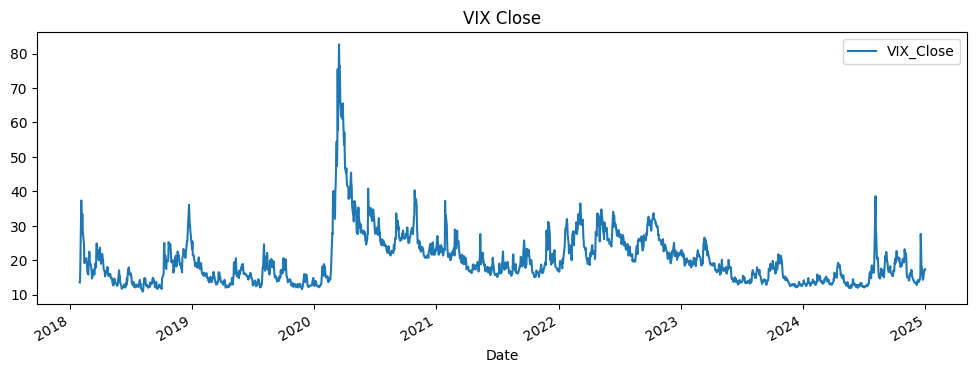

In [84]:
feature_data_clean.plot(x="Date", y="VIX_Close", figsize=(12, 4), title="VIX Close")
plt.savefig("outputs/vix_close.png", dpi=300, bbox_inches="tight")
plt.show()

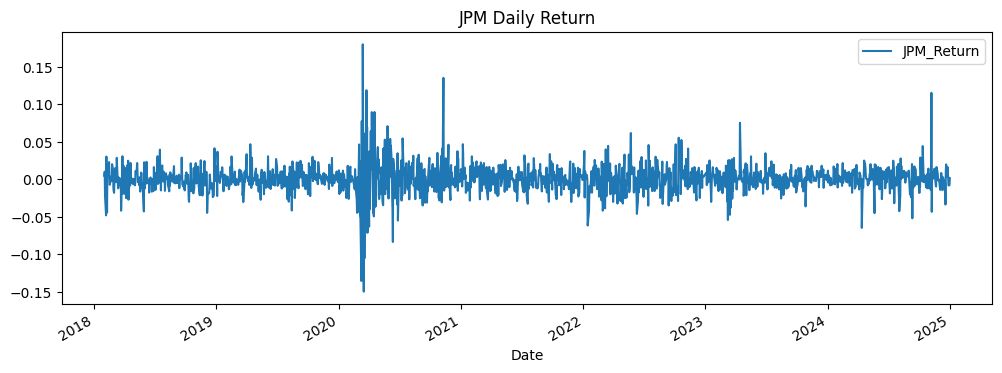

In [85]:
feature_data_clean.plot(x="Date", y="JPM_Return", figsize=(12, 4), title="JPM Daily Return")
plt.savefig("outputs/jpm_daily_return.png", dpi=300, bbox_inches="tight")
plt.show()

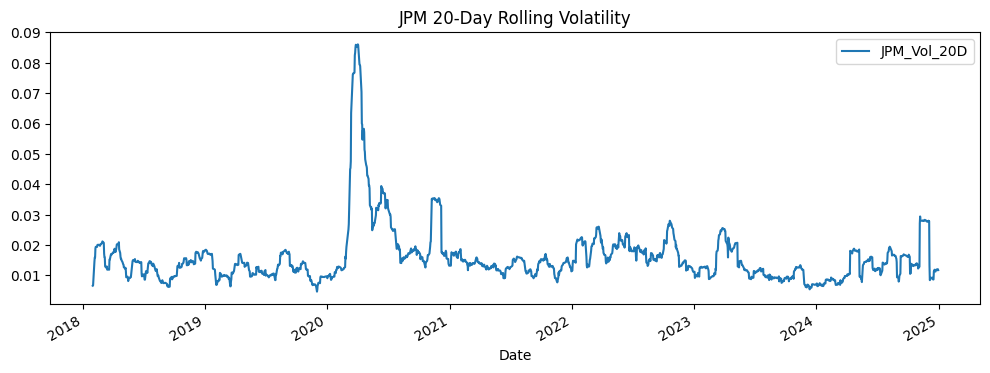

In [86]:
feature_data_clean.plot(x="Date", y="JPM_Vol_20D", figsize=(12, 4), title="JPM 20-Day Rolling Volatility")
plt.savefig("outputs/jpm_20d_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

In [79]:
feature_data_clean[[
    "JPM_Return",
    "VIX_Return",
    "Treasury_1Y_Change",
    "JPM_Vol_5D",
    "JPM_Vol_10D",
    "JPM_Vol_20D"
]].corr()

,JPM_Return,VIX_Return,Treasury_1Y_Change,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D
JPM_Return,1.000000,-0.487122,0.170973,0.006479,0.026455,0.020301
VIX_Return,-0.487122,1.000000,-0.096849,-0.007904,-0.026832,-0.037391
Treasury_1Y_Change,0.170973,-0.096849,1.000000,-0.030282,-0.015668,0.008314
JPM_Vol_5D,0.006479,-0.007904,-0.030282,1.000000,0.874404,0.759791
JPM_Vol_10D,0.026455,-0.026832,-0.015668,0.874404,1.000000,0.892326
JPM_Vol_20D,0.020301,-0.037391,0.008314,0.759791,0.892326,1.000000


In [80]:
feature_data_clean[[
    "JPM_Return",
    "VIX_Return",
    "Treasury_1Y_Change"
]].sort_values("JPM_Return").head(10)

,JPM_Return,VIX_Return,Treasury_1Y_Change
533,-0.149649,0.429881,-0.09
528,-0.135455,0.298522,-0.08
535,-0.105269,0.007114,-0.09
594,-0.083443,0.479507,0.01
531,-0.082430,0.400186,-0.01
542,-0.071239,0.074426,-0.02
1559,-0.064678,0.160966,-0.04
545,-0.062979,0.065745,-0.01
997,-0.061463,-0.055145,0.04
605,-0.054818,0.077902,0.00


In [81]:
feature_data_clean[[
    "Date",
    "JPM_Return",
    "VIX_Return",
    "Treasury_1Y_Change"
]].sort_values("JPM_Return", ascending=False).head(10)

,Date,JPM_Return,VIX_Return,Treasury_1Y_Change
532,2020-03-13,0.180125,-0.233735,-0.01
699,2020-11-09,0.135392,0.035800,0.00
539,2020-03-24,0.118942,0.001299,0.08
1703,2024-11-06,0.115445,-0.205954,0.04
556,2020-04-17,0.089889,-0.048866,-0.01
551,2020-04-09,0.089714,-0.038754,0.02
529,2020-03-10,0.077697,-0.131473,0.12
1309,2023-04-14,0.075510,-0.041011,0.11
582,2020-05-26,0.070974,-0.005327,0.00
541,2020-03-26,0.069661,-0.046130,-0.06


In [82]:
summary_stats = feature_data_clean.describe()
summary_stats.to_csv("outputs/week2_feature_summary_stats.csv")
summary_stats

,Date,JPM_Close,VIX_Close,Treasury_1Y,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D
count,1741,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000,1741.000000
mean,2021-07-16 03:49:06.582424064,138.008507,19.972269,2.494095,0.000597,0.000421,0.003567,0.001310,0.014750,0.015480,0.015988
min,2018-01-31 00:00:00,79.030000,10.850000,0.040000,-0.149649,-0.162106,-0.281566,-0.600000,0.001158,0.002880,0.004685
25%,2019-10-23 00:00:00,111.290000,14.640000,0.270000,-0.007927,-0.007959,-0.044152,-0.010000,0.008180,0.009609,0.010797
50%,2021-07-16 00:00:00,131.740000,18.150000,2.340000,0.000560,0.000560,-0.008306,0.000000,0.012086,0.013170,0.013881
75%,2023-04-10 00:00:00,155.480000,22.960000,4.520000,0.009083,0.009042,0.035119,0.010000,0.017458,0.017451,0.017631
max,2024-12-31 00:00:00,250.290000,82.690000,5.490000,0.180125,0.165620,1.155979,0.340000,0.135449,0.105834,0.086093
std,NaN,34.981926,7.693901,1.889360,0.018753,0.018716,0.088621,0.046467,0.011995,0.010751,0.009862


In [87]:
rates_3m = pdr.DataReader("DGS3MO", "fred", "2018-01-01", "2024-12-31")
rates_6m = pdr.DataReader("DGS6MO", "fred", "2018-01-01", "2024-12-31")

rates_3m = rates_3m.reset_index().rename(columns={"DATE": "Date", "DGS3MO": "Treasury_3M"})
rates_6m = rates_6m.reset_index().rename(columns={"DATE": "Date", "DGS6MO": "Treasury_6M"})

rates_3m["Date"] = pd.to_datetime(rates_3m["Date"])
rates_6m["Date"] = pd.to_datetime(rates_6m["Date"])

rates_3m = rates_3m.sort_values("Date").reset_index(drop=True)
rates_6m = rates_6m.sort_values("Date").reset_index(drop=True)

model_data_ext = model_data.copy()
model_data_ext = model_data_ext.merge(rates_3m, on="Date", how="left")
model_data_ext = model_data_ext.merge(rates_6m, on="Date", how="left")

model_data_ext["Treasury_3M"] = model_data_ext["Treasury_3M"].ffill().bfill()
model_data_ext["Treasury_6M"] = model_data_ext["Treasury_6M"].ffill().bfill()

model_data_ext["JPM_Return"] = model_data_ext["JPM_Close"].pct_change()
model_data_ext["JPM_LogReturn"] = np.log(model_data_ext["JPM_Close"] / model_data_ext["JPM_Close"].shift(1))
model_data_ext["VIX_Return"] = model_data_ext["VIX_Close"].pct_change()
model_data_ext["Treasury_1Y_Change"] = model_data_ext["Treasury_1Y"].diff()

model_data_ext["Treasury_1Y_Mom_5D"] = model_data_ext["Treasury_1Y"] / model_data_ext["Treasury_1Y"].shift(5) - 1
model_data_ext["Treasury_1Y_Mom_20D"] = model_data_ext["Treasury_1Y"] / model_data_ext["Treasury_1Y"].shift(20) - 1

model_data_ext["Corr_JPM_VIX_20D"] = model_data_ext["JPM_LogReturn"].rolling(20).corr(model_data_ext["VIX_Return"])
model_data_ext["Corr_JPM_VIX_60D"] = model_data_ext["JPM_LogReturn"].rolling(60).corr(model_data_ext["VIX_Return"])

model_data_ext.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,Treasury_3M,Treasury_6M,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,Treasury_1Y_Mom_5D,Treasury_1Y_Mom_20D,Corr_JPM_VIX_20D,Corr_JPM_VIX_60D
0,2018-01-02,107.95,9.77,1.83,1.44,1.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-03,108.06,9.15,1.81,1.41,1.59,0.001019,0.001018,-0.063460,-0.02,NaN,NaN,NaN,NaN
2,2018-01-04,109.04,9.22,1.82,1.41,1.60,0.009069,0.009028,0.007650,0.01,NaN,NaN,NaN,NaN
3,2018-01-05,108.34,9.22,1.80,1.39,1.58,-0.006420,-0.006440,0.000000,-0.02,NaN,NaN,NaN,NaN
4,2018-01-08,108.50,9.52,1.79,1.45,1.60,0.001477,0.001476,0.032538,-0.01,NaN,NaN,NaN,NaN


In [88]:
model_data_ext.isna().sum()

Date                    0
JPM_Close               0
VIX_Close               0
Treasury_1Y             0
Treasury_3M             0
Treasury_6M             0
JPM_Return              1
JPM_LogReturn           1
VIX_Return              1
Treasury_1Y_Change      1
Treasury_1Y_Mom_5D      5
Treasury_1Y_Mom_20D    20
Corr_JPM_VIX_20D       20
Corr_JPM_VIX_60D       60
dtype: int64

In [89]:
feature_data_ext = model_data_ext.dropna().reset_index(drop=True)
feature_data_ext.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,Treasury_3M,Treasury_6M,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,Treasury_1Y_Mom_5D,Treasury_1Y_Mom_20D,Corr_JPM_VIX_20D,Corr_JPM_VIX_60D
0,2018-03-29,109.97,19.97,2.09,1.73,1.93,0.018241,0.018076,-0.126804,-0.03,0.019512,0.019512,-0.826421,-0.740739
1,2018-04-02,107.85,23.62,2.08,1.77,1.92,-0.019278,-0.019466,0.182774,-0.01,0.019608,0.009709,-0.860836,-0.745482
2,2018-04-03,109.33,21.10,2.09,1.75,1.92,0.013723,0.013629,-0.106689,0.01,0.014563,0.014563,-0.869869,-0.749021
3,2018-04-04,110.99,20.06,2.07,1.71,1.90,0.015183,0.015069,-0.049289,-0.02,-0.014286,0.004854,-0.868335,-0.751103
4,2018-04-05,111.88,18.94,2.07,1.72,1.93,0.008019,0.007987,-0.055833,0.00,-0.023585,0.009756,-0.875961,-0.752016


In [90]:
print(feature_data_ext.shape)
print(feature_data_ext.isna().sum())

(1701, 14)
Date                   0
JPM_Close              0
VIX_Close              0
Treasury_1Y            0
Treasury_3M            0
Treasury_6M            0
JPM_Return             0
JPM_LogReturn          0
VIX_Return             0
Treasury_1Y_Change     0
Treasury_1Y_Mom_5D     0
Treasury_1Y_Mom_20D    0
Corr_JPM_VIX_20D       0
Corr_JPM_VIX_60D       0
dtype: int64


In [91]:
feature_data_ext.to_csv("data/processed/feature_data_extended.csv", index=False)

In [93]:
feature_data_ext.describe()

,Date,JPM_Close,VIX_Close,Treasury_1Y,Treasury_3M,Treasury_6M,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,Treasury_1Y_Mom_5D,Treasury_1Y_Mom_20D,Corr_JPM_VIX_20D,Corr_JPM_VIX_60D
count,1701,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000
mean,2021-08-14 04:13:07.301587456,138.577137,19.959918,2.505456,2.460012,2.520582,0.000644,0.000469,0.003008,0.001199,0.008122,0.039487,-0.491998,-0.509232
min,2018-03-29 00:00:00,79.030000,10.850000,0.040000,0.000000,0.020000,-0.149649,-0.162106,-0.281566,-0.600000,-0.651685,-0.895105,-0.896454,-0.779392
25%,2019-12-05 00:00:00,111.230000,14.570000,0.240000,0.140000,0.180000,-0.007917,-0.007949,-0.043882,-0.010000,-0.016461,-0.045187,-0.680088,-0.635493
50%,2021-08-13 00:00:00,133.060000,18.070000,2.370000,2.100000,2.230000,0.000560,0.000560,-0.008147,0.000000,0.000000,0.001869,-0.528538,-0.521481
75%,2023-04-24 00:00:00,156.020000,22.960000,4.600000,4.720000,4.730000,0.009083,0.009042,0.034831,0.010000,0.022222,0.062189,-0.349222,-0.412056
max,2024-12-31 00:00:00,250.290000,82.690000,5.490000,5.630000,5.610000,0.180125,0.165620,0.740391,0.340000,0.800000,1.375000,0.347052,0.030687
std,NaN,35.188652,7.742562,1.909956,2.070083,2.024034,0.018758,0.018717,0.083227,0.046914,0.108455,0.246444,0.238760,0.150846


In [94]:
feature_data_ext.describe().to_csv("outputs/week2_extended_feature_summary_stats.csv")

In [95]:
feature_data_ext.columns.tolist()

['Date',
 'JPM_Close',
 'VIX_Close',
 'Treasury_1Y',
 'Treasury_3M',
 'Treasury_6M',
 'JPM_Return',
 'JPM_LogReturn',
 'VIX_Return',
 'Treasury_1Y_Change',
 'Treasury_1Y_Mom_5D',
 'Treasury_1Y_Mom_20D',
 'Corr_JPM_VIX_20D',
 'Corr_JPM_VIX_60D']

In [96]:
treasury_missing = merged_preview["Treasury_1Y"].isna()

max_gap = 0
current_gap = 0
gap_lengths = []

for is_missing in treasury_missing:
    if is_missing:
        current_gap += 1
    else:
        if current_gap > 0:
            gap_lengths.append(current_gap)
            max_gap = max(max_gap, current_gap)
            current_gap = 0

if current_gap > 0:
    gap_lengths.append(current_gap)
    max_gap = max(max_gap, current_gap)

print("Max consecutive missing days in Treasury_1Y:", max_gap)
print("Count of gaps > 3 days:", len([g for g in gap_lengths if g > 3]))
print("Gaps > 3 days:", [g for g in gap_lengths if g > 3])

Max consecutive missing days in Treasury_1Y: 1
Count of gaps > 3 days: 0
Gaps > 3 days: []


In [97]:
merged_flagged = merged_preview.copy()

merged_flagged["Is_JPM_Missing"] = merged_flagged["JPM_Close"].isna().astype(int)
merged_flagged["Is_VIX_Missing"] = merged_flagged["VIX_Close"].isna().astype(int)
merged_flagged["Is_Treasury_Missing"] = merged_flagged["Treasury_1Y"].isna().astype(int)
merged_flagged["Is_NonTrading_Day"] = (
    merged_flagged["JPM_Close"].isna() | merged_flagged["VIX_Close"].isna()
).astype(int)

merged_flagged.to_csv("data/processed/merged_preview_with_flags.csv", index=False)
merged_flagged.head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,Is_JPM_Missing,Is_VIX_Missing,Is_Treasury_Missing,Is_NonTrading_Day
0,2018-01-01,NaN,NaN,NaN,1,1,1,1
1,2018-01-02,107.95,9.77,1.83,0,0,0,0
2,2018-01-03,108.06,9.15,1.81,0,0,0,0
3,2018-01-04,109.04,9.22,1.82,0,0,0,0
4,2018-01-05,108.34,9.22,1.80,0,0,0,0


In [99]:
model_data_ext["JPM_Vol_20D"] = model_data_ext["JPM_LogReturn"].rolling(20).std()
model_data_ext["VolOfVol_20D"] = model_data_ext["JPM_Vol_20D"].rolling(20).std()

In [100]:
model_data_ext["RealizedVol_5D"] = np.sqrt(model_data_ext["JPM_LogReturn"].rolling(5).apply(lambda x: np.sum(x**2), raw=True))
model_data_ext["RealizedVol_20D"] = np.sqrt(model_data_ext["JPM_LogReturn"].rolling(20).apply(lambda x: np.sum(x**2), raw=True))

model_data_ext["VolOfVol_20D"] = model_data_ext["JPM_Vol_20D"].rolling(20).std()

In [101]:
feature_data_ext = model_data_ext.dropna().reset_index(drop=True)

print(feature_data_ext.shape)
print(feature_data_ext.isna().sum())

(1701, 18)
Date                   0
JPM_Close              0
VIX_Close              0
Treasury_1Y            0
Treasury_3M            0
Treasury_6M            0
JPM_Return             0
JPM_LogReturn          0
VIX_Return             0
Treasury_1Y_Change     0
Treasury_1Y_Mom_5D     0
Treasury_1Y_Mom_20D    0
Corr_JPM_VIX_20D       0
Corr_JPM_VIX_60D       0
RealizedVol_5D         0
RealizedVol_20D        0
JPM_Vol_20D            0
VolOfVol_20D           0
dtype: int64


In [102]:
feature_data_ext[(feature_data_ext["Date"] >= "2020-03-01") & (feature_data_ext["Date"] <= "2020-03-31")].head()

,Date,JPM_Close,VIX_Close,Treasury_1Y,Treasury_3M,Treasury_6M,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,Treasury_1Y_Mom_5D,Treasury_1Y_Mom_20D,Corr_JPM_VIX_20D,Corr_JPM_VIX_60D,RealizedVol_5D,RealizedVol_20D,JPM_Vol_20D,VolOfVol_20D
483,2020-03-02,121.52,33.42,0.89,1.13,0.95,0.046594,0.045541,-0.166791,-0.08,-0.340741,-0.386207,-0.711767,-0.698099,0.089098,0.098895,0.022261,0.002897
484,2020-03-03,116.96,36.82,0.73,0.95,0.83,-0.037525,-0.038247,0.101735,-0.16,-0.438462,-0.500000,-0.694533,-0.689027,0.085530,0.105761,0.023310,0.003556
485,2020-03-04,119.85,31.99,0.59,0.72,0.68,0.024709,0.024409,-0.131179,-0.14,-0.531746,-0.601351,-0.704127,-0.699155,0.088895,0.107596,0.023889,0.004113
486,2020-03-05,113.97,39.62,0.48,0.62,0.53,-0.049061,-0.050306,0.238512,-0.11,-0.593220,-0.677852,-0.720740,-0.717808,0.092878,0.117573,0.025183,0.004668
487,2020-03-06,108.08,41.94,0.39,0.45,0.41,-0.051680,-0.053064,0.058556,-0.09,-0.597938,-0.741722,-0.667798,-0.694819,0.097360,0.128992,0.026874,0.005250


In [104]:
model_data_ext["JPM_Vol_5D"] = model_data_ext["JPM_LogReturn"].rolling(5).std()
model_data_ext["JPM_Vol_10D"] = model_data_ext["JPM_LogReturn"].rolling(10).std()
model_data_ext["JPM_Vol_20D"] = model_data_ext["JPM_LogReturn"].rolling(20).std()

feature_data_ext = model_data_ext.dropna().reset_index(drop=True)
feature_data_ext.columns.tolist()

['Date',
 'JPM_Close',
 'VIX_Close',
 'Treasury_1Y',
 'Treasury_3M',
 'Treasury_6M',
 'JPM_Return',
 'JPM_LogReturn',
 'VIX_Return',
 'Treasury_1Y_Change',
 'Treasury_1Y_Mom_5D',
 'Treasury_1Y_Mom_20D',
 'Corr_JPM_VIX_20D',
 'Corr_JPM_VIX_60D',
 'RealizedVol_5D',
 'RealizedVol_20D',
 'JPM_Vol_20D',
 'VolOfVol_20D',
 'JPM_Vol_5D',
 'JPM_Vol_10D']

In [105]:
winsor_cols = [
    "JPM_Return",
    "JPM_LogReturn",
    "VIX_Return",
    "Treasury_1Y_Change",
    "Treasury_1Y_Mom_5D",
    "Treasury_1Y_Mom_20D",
    "Corr_JPM_VIX_20D",
    "Corr_JPM_VIX_60D",
    "JPM_Vol_5D",
    "JPM_Vol_10D",
    "JPM_Vol_20D",
    "RealizedVol_5D",
    "RealizedVol_20D",
    "VolOfVol_20D"
]

feature_data_ext_capped = feature_data_ext.copy()

for col in winsor_cols:
    lower = feature_data_ext_capped[col].quantile(0.005)
    upper = feature_data_ext_capped[col].quantile(0.995)
    feature_data_ext_capped[col] = feature_data_ext_capped[col].clip(lower=lower, upper=upper)

In [106]:
feature_data_ext_capped[[
    "JPM_Return",
    "VIX_Return",
    "Treasury_1Y_Change",
    "Corr_JPM_VIX_20D",
    "RealizedVol_20D",
    "VolOfVol_20D"
]].describe()

,JPM_Return,VIX_Return,Treasury_1Y_Change,Corr_JPM_VIX_20D,RealizedVol_20D,VolOfVol_20D
count,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000
mean,0.000628,0.002542,0.001370,-0.492228,0.071265,0.002398
std,0.016793,0.078701,0.041451,0.237801,0.043568,0.002700
min,-0.058141,-0.179025,-0.175000,-0.873676,0.028712,0.000327
25%,-0.007917,-0.043882,-0.010000,-0.680088,0.048405,0.001093
50%,0.000560,-0.008147,0.000000,-0.528538,0.061814,0.001628
75%,0.009083,0.034831,0.010000,-0.349222,0.077824,0.002627
max,0.070317,0.410543,0.185000,0.254519,0.361593,0.022046


In [107]:
feature_data_ext.to_csv("data/processed/feature_data_extended.csv", index=False)
feature_data_ext_capped.to_csv("data/processed/feature_data_extended_capped_995.csv", index=False)

In [109]:
from scipy.stats import norm

In [110]:
import numpy as np
from scipy.stats import norm

In [111]:
def bs_call_price(S, K, r, q, sigma, T):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan
    
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call


def bs_put_price(S, K, r, q, sigma, T):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan
    
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    return put

In [112]:
def chooser_option_price(S, K, r, q, sigma, T, tc):
    if tc <= 0 or T <= 0 or tc >= T:
        return np.nan
    if sigma <= 0 or S <= 0 or K <= 0:
        return np.nan
    
    adjusted_strike = K * np.exp(-(r - q) * (T - tc))
    
    call_part = bs_call_price(S, K, r, q, sigma, T)
    put_part = bs_put_price(S, adjusted_strike, r, q, sigma, tc)
    
    return call_part + put_part

In [113]:
test_row = feature_data_ext.iloc[0]

S_test = test_row["JPM_Close"]
r_test = test_row["Treasury_1Y"] / 100
sigma_test = test_row["JPM_Vol_20D"] * np.sqrt(252)

K = 150
T = 1.0
tc = 0.5
q = 0.0

test_price = chooser_option_price(S_test, K, r_test, q, sigma_test, T, tc)
test_price

40.1324714577483

In [114]:
feature_data_ext["Sigma_Annual"] = feature_data_ext["JPM_Vol_20D"] * np.sqrt(252)
feature_data_ext["RiskFree_1Y"] = feature_data_ext["Treasury_1Y"] / 100

K = 150
T = 1.0
tc = 0.5
q = 0.0

feature_data_ext["ChooserPrice_BSM"] = feature_data_ext.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

feature_data_ext[["Date", "JPM_Close", "Sigma_Annual", "RiskFree_1Y", "ChooserPrice_BSM"]].head()

,Date,JPM_Close,Sigma_Annual,RiskFree_1Y,ChooserPrice_BSM
0,2018-03-29,109.97,0.271271,0.0209,40.132471
1,2018-04-02,107.85,0.278594,0.0208,42.026369
2,2018-04-03,109.33,0.277293,0.0209,40.848843
3,2018-04-04,110.99,0.284116,0.0207,39.959394
4,2018-04-05,111.88,0.286120,0.0207,39.433136


In [115]:
feature_data_ext["ChooserPrice_BSM"].describe()

count    1701.000000
mean       38.433463
std        19.824962
min        12.659910
25%        23.406677
50%        34.532219
75%        45.595980
max       114.083986
Name: ChooserPrice_BSM, dtype: float64

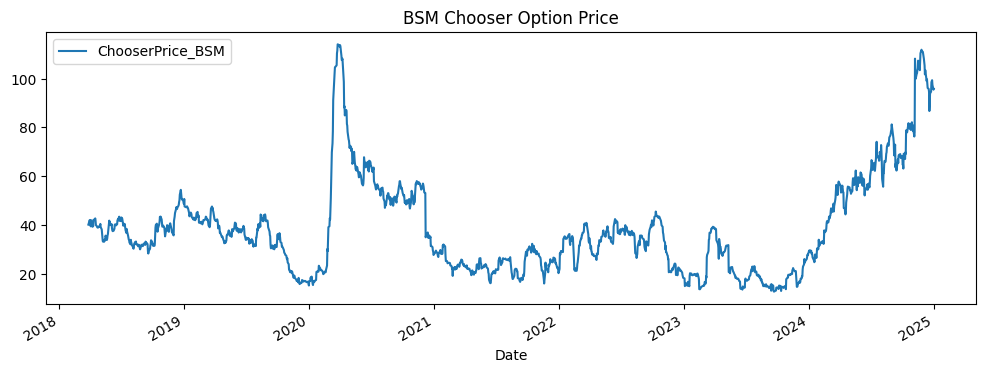

In [116]:
feature_data_ext.plot(x="Date", y="ChooserPrice_BSM", figsize=(12, 4), title="BSM Chooser Option Price")
plt.show()

In [117]:
feature_data_ext.to_csv("data/processed/feature_data_with_bsm_chooser.csv", index=False)

In [118]:
test_row = feature_data_ext.iloc[0]

S_test = test_row["JPM_Close"]
r_test = test_row["RiskFree_1Y"]
sigma_test = test_row["Sigma_Annual"]

K = 150
T = 1.0
tc = 0.5
q = 0.0

for s in [0.8 * sigma_test, sigma_test, 1.2 * sigma_test]:
    price = chooser_option_price(S_test, K, r_test, q, s, T, tc)
    print("sigma =", round(s, 4), "-> chooser price =", round(price, 4))

sigma = 0.217 -> chooser price = 38.3128
sigma = 0.2713 -> chooser price = 40.1325
sigma = 0.3255 -> chooser price = 42.5793


In [119]:
feature_data_ext["BSM_Call"] = feature_data_ext.apply(
    lambda row: bs_call_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_Annual"],
        T=T
    ),
    axis=1
)

feature_data_ext["BSM_Put"] = feature_data_ext.apply(
    lambda row: bs_put_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_Annual"],
        T=T
    ),
    axis=1
)

feature_data_ext[["Date", "BSM_Call", "BSM_Put", "ChooserPrice_BSM"]].head()

,Date,BSM_Call,BSM_Put,ChooserPrice_BSM
0,2018-03-29,2.507920,39.435454,40.132471
1,2018-04-02,2.346605,41.408830,42.026369
2,2018-04-03,2.566094,40.133627,40.848843
3,2018-04-04,3.077216,39.014132,39.959394
4,2018-04-05,3.322120,38.369036,39.433136


In [120]:
feature_data_ext.to_csv("data/processed/feature_data_with_bsm_chooser.csv", index=False)

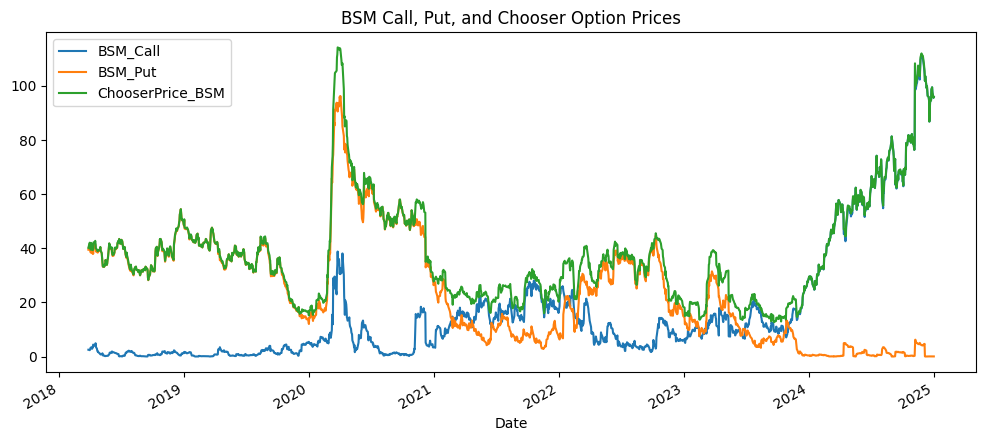

In [121]:
feature_data_ext.plot(
    x="Date",
    y=["BSM_Call", "BSM_Put", "ChooserPrice_BSM"],
    figsize=(12, 5),
    title="BSM Call, Put, and Chooser Option Prices"
)
plt.show()

In [122]:
feature_data_ext["ChooserPrice_q0"] = feature_data_ext.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=150,
        r=row["RiskFree_1Y"],
        q=0.00,
        sigma=row["Sigma_Annual"],
        T=1.0,
        tc=0.5
    ),
    axis=1
)

feature_data_ext["ChooserPrice_q2pct"] = feature_data_ext.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=150,
        r=row["RiskFree_1Y"],
        q=0.02,
        sigma=row["Sigma_Annual"],
        T=1.0,
        tc=0.5
    ),
    axis=1
)

feature_data_ext["ChooserPrice_q3pct"] = feature_data_ext.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=150,
        r=row["RiskFree_1Y"],
        q=0.03,
        sigma=row["Sigma_Annual"],
        T=1.0,
        tc=0.5
    ),
    axis=1
)

In [123]:
feature_data_ext[[
    "ChooserPrice_q0",
    "ChooserPrice_q2pct",
    "ChooserPrice_q3pct"
]].describe()

,ChooserPrice_q0,ChooserPrice_q2pct,ChooserPrice_q3pct
count,1701.000000,1701.000000,1701.000000
mean,38.433463,38.727402,38.936428
std,19.824962,19.352056,19.168931
min,12.659910,12.004254,11.848123
25%,23.406677,23.058888,23.191050
50%,34.532219,36.068485,36.898031
75%,45.595980,46.693694,47.557711
max,114.083986,114.647080,114.976129


In [124]:
feature_data_ext["Diff_q2_minus_q0"] = feature_data_ext["ChooserPrice_q2pct"] - feature_data_ext["ChooserPrice_q0"]
feature_data_ext["Diff_q3_minus_q0"] = feature_data_ext["ChooserPrice_q3pct"] - feature_data_ext["ChooserPrice_q0"]

feature_data_ext[[
    "Diff_q2_minus_q0",
    "Diff_q3_minus_q0"
]].describe()

,Diff_q2_minus_q0,Diff_q3_minus_q0
count,1701.000000,1701.000000
mean,0.293938,0.502964
std,2.108733,3.147033
min,-4.897920,-7.310350
25%,-0.818781,-1.094856
50%,0.894935,1.391665
75%,2.130358,3.228320
max,2.638636,3.989220


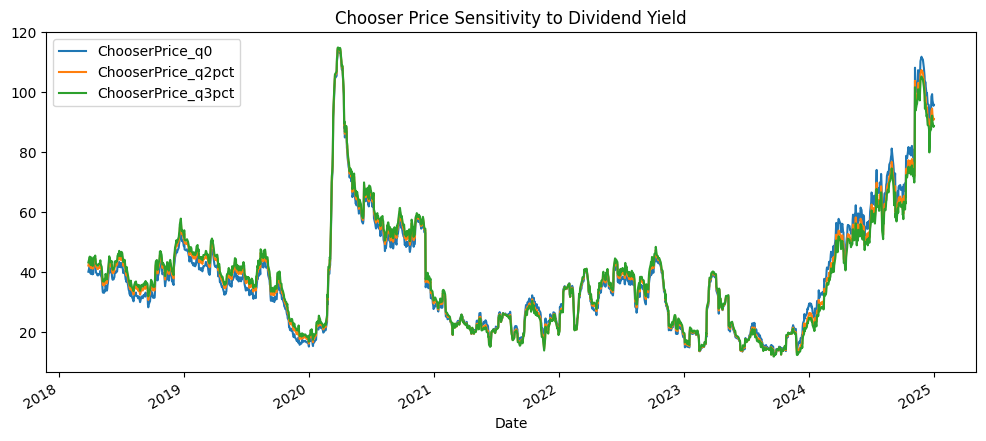

In [125]:
feature_data_ext.plot(
    x="Date",
    y=["ChooserPrice_q0", "ChooserPrice_q2pct", "ChooserPrice_q3pct"],
    figsize=(12, 5),
    title="Chooser Price Sensitivity to Dividend Yield"
)
plt.show()

In [126]:
test_row = feature_data_ext.iloc[0]

S_test = test_row["JPM_Close"]
r_test = test_row["RiskFree_1Y"]
sigma_test = test_row["Sigma_Annual"]

for q_test in [0.00, 0.02, 0.03]:
    price = chooser_option_price(S_test, 150, r_test, q_test, sigma_test, 1.0, 0.5)
    print("q =", q_test, "-> chooser price =", round(price, 4))

q = 0.0 -> chooser price = 40.1325
q = 0.02 -> chooser price = 42.1903
q = 0.03 -> chooser price = 43.2489


In [127]:
feature_data_ext.to_csv("data/processed/feature_data_with_dividend_sensitivity.csv", index=False)

In [128]:
feature_data_ext[[
    "ChooserPrice_q0",
    "ChooserPrice_q2pct",
    "ChooserPrice_q3pct",
    "Diff_q2_minus_q0",
    "Diff_q3_minus_q0"
]].describe().to_csv("outputs/dividend_sensitivity_summary.csv")

In [129]:
q = 0.02

In [130]:
model_data_ext["JPM_Vol_60D"] = model_data_ext["JPM_LogReturn"].rolling(60).std()
model_data_ext["JPM_Vol_120D"] = model_data_ext["JPM_LogReturn"].rolling(120).std()

model_data_ext["Sigma_20D_Annual"] = model_data_ext["JPM_Vol_20D"] * np.sqrt(252)
model_data_ext["Sigma_60D_Annual"] = model_data_ext["JPM_Vol_60D"] * np.sqrt(252)
model_data_ext["Sigma_120D_Annual"] = model_data_ext["JPM_Vol_120D"] * np.sqrt(252)

In [131]:
vol_window_data = model_data_ext.dropna(subset=[
    "Sigma_20D_Annual",
    "Sigma_60D_Annual",
    "Sigma_120D_Annual"
]).reset_index(drop=True)

vol_window_data[["Date", "Sigma_20D_Annual", "Sigma_60D_Annual", "Sigma_120D_Annual"]].head()

,Date,Sigma_20D_Annual,Sigma_60D_Annual,Sigma_120D_Annual
0,2018-06-25,0.228578,0.207489,0.231695
1,2018-06-26,0.169839,0.203825,0.231691
2,2018-06-27,0.154318,0.203983,0.232346
3,2018-06-28,0.162939,0.204389,0.233431
4,2018-06-29,0.155584,0.203899,0.233619


In [132]:
vol_window_data[[
    "Sigma_20D_Annual",
    "Sigma_60D_Annual",
    "Sigma_120D_Annual"
]].describe()

,Sigma_20D_Annual,Sigma_60D_Annual,Sigma_120D_Annual
count,1641.000000,1641.000000,1641.000000
mean,0.254489,0.263382,0.270001
std,0.160566,0.142009,0.127162
min,0.074378,0.111926,0.138779
25%,0.168542,0.193738,0.200931
50%,0.218730,0.222971,0.225355
75%,0.279378,0.298558,0.292724
max,1.366689,0.928033,0.719723


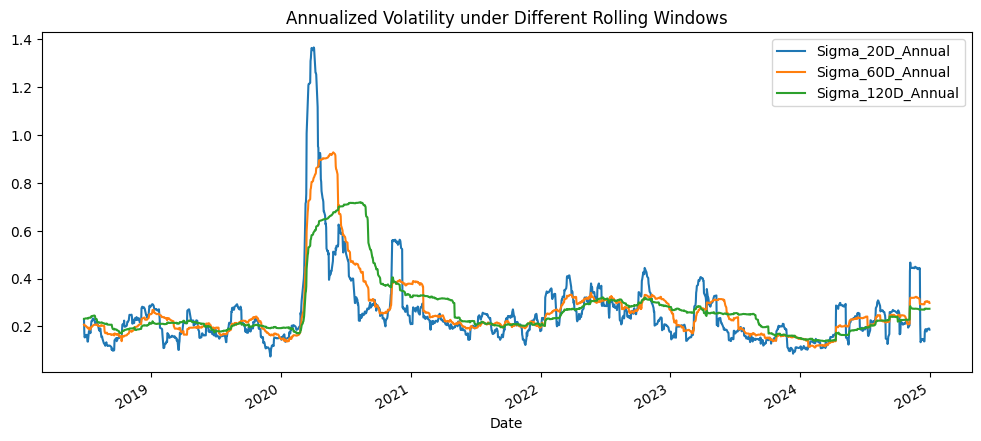

In [133]:
vol_window_data.plot(
    x="Date",
    y=["Sigma_20D_Annual", "Sigma_60D_Annual", "Sigma_120D_Annual"],
    figsize=(12, 5),
    title="Annualized Volatility under Different Rolling Windows"
)
plt.show()

In [135]:
vol_window_data["RiskFree_1Y"] = vol_window_data["Treasury_1Y"] / 100

In [136]:
K = 150
T = 1.0
tc = 0.5
q = 0.02

vol_window_data["ChooserPrice_sigma20"] = vol_window_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_20D_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

vol_window_data["ChooserPrice_sigma60"] = vol_window_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_60D_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

vol_window_data["ChooserPrice_sigma120"] = vol_window_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_120D_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

In [137]:
vol_window_data[[
    "ChooserPrice_sigma20",
    "ChooserPrice_sigma60",
    "ChooserPrice_sigma120"
]].describe()

,ChooserPrice_sigma20,ChooserPrice_sigma60,ChooserPrice_sigma120
count,1641.000000,1641.000000,1641.000000
mean,38.647053,39.016229,39.520339
std,19.692366,18.681437,17.727715
min,12.004254,13.486496,15.556464
25%,22.760075,24.494271,25.491490
50%,35.246047,35.174955,35.187861
75%,48.667968,46.380247,46.247198
max,114.647080,103.110138,102.268418


In [138]:
vol_window_data["Diff_sigma20_minus_60"] = vol_window_data["ChooserPrice_sigma20"] - vol_window_data["ChooserPrice_sigma60"]
vol_window_data["Diff_sigma20_minus_120"] = vol_window_data["ChooserPrice_sigma20"] - vol_window_data["ChooserPrice_sigma120"]

vol_window_data[[
    "Diff_sigma20_minus_60",
    "Diff_sigma20_minus_120"
]].describe()

,Diff_sigma20_minus_60,Diff_sigma20_minus_120
count,1641.000000,1641.000000
mean,-0.369176,-0.873286
std,5.612714,7.153086
min,-25.715674,-23.209953
25%,-1.931880,-4.107853
50%,-0.307806,-0.546133
75%,0.790906,1.101343
max,35.834464,48.566210


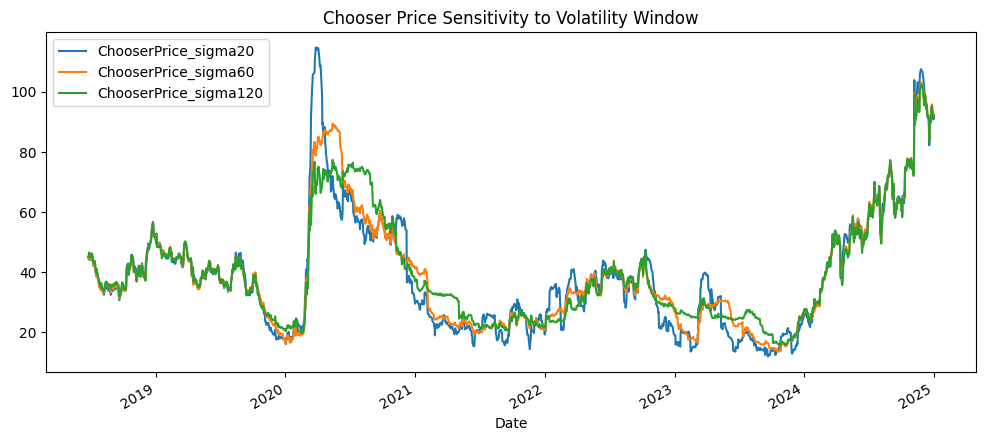

In [139]:
vol_window_data.plot(
    x="Date",
    y=["ChooserPrice_sigma20", "ChooserPrice_sigma60", "ChooserPrice_sigma120"],
    figsize=(12, 5),
    title="Chooser Price Sensitivity to Volatility Window"
)
plt.show()

In [140]:
vol_window_data.to_csv("data/processed/vol_window_sensitivity.csv", index=False)

In [141]:
vol_window_data[[
    "Sigma_20D_Annual",
    "Sigma_60D_Annual",
    "Sigma_120D_Annual",
    "ChooserPrice_sigma20",
    "ChooserPrice_sigma60",
    "ChooserPrice_sigma120"
]].describe().to_csv("outputs/vol_window_sensitivity_summary.csv")

In [142]:
moneyness_data = feature_data_ext.copy()

moneyness_data["K_ATM"] = moneyness_data["JPM_Close"]
moneyness_data["K_ITM"] = 0.9 * moneyness_data["JPM_Close"]
moneyness_data["K_OTM"] = 1.1 * moneyness_data["JPM_Close"]

T = 1.0
tc = 0.5
q = 0.02

In [144]:
moneyness_data = feature_data_ext.copy()

moneyness_data["K_ATM"] = moneyness_data["JPM_Close"]
moneyness_data["K_ITM"] = 0.9 * moneyness_data["JPM_Close"]
moneyness_data["K_OTM"] = 1.1 * moneyness_data["JPM_Close"]

moneyness_data["Sigma_20D_Annual"] = moneyness_data["JPM_Vol_20D"] * np.sqrt(252)
moneyness_data["RiskFree_1Y"] = moneyness_data["Treasury_1Y"] / 100

T = 1.0
tc = 0.5
q = 0.02

In [145]:
moneyness_data["ChooserPrice_ATM"] = moneyness_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=row["K_ATM"],
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_20D_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

moneyness_data["ChooserPrice_ITM"] = moneyness_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=row["K_ITM"],
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_20D_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

moneyness_data["ChooserPrice_OTM"] = moneyness_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=row["K_OTM"],
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["Sigma_20D_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

In [146]:
moneyness_data[[
    "ChooserPrice_ITM",
    "ChooserPrice_ATM",
    "ChooserPrice_OTM"
]].describe()

,ChooserPrice_ITM,ChooserPrice_ATM,ChooserPrice_OTM
count,1701.000000,1701.000000,1701.000000
mean,25.015614,22.539340,26.107661
std,10.310855,11.282872,11.470202
min,11.849893,6.582808,11.549012
25%,18.913031,15.716378,18.825463
50%,22.436385,19.733032,23.026204
75%,28.119788,26.083134,30.280078
max,80.489697,84.606817,89.318998


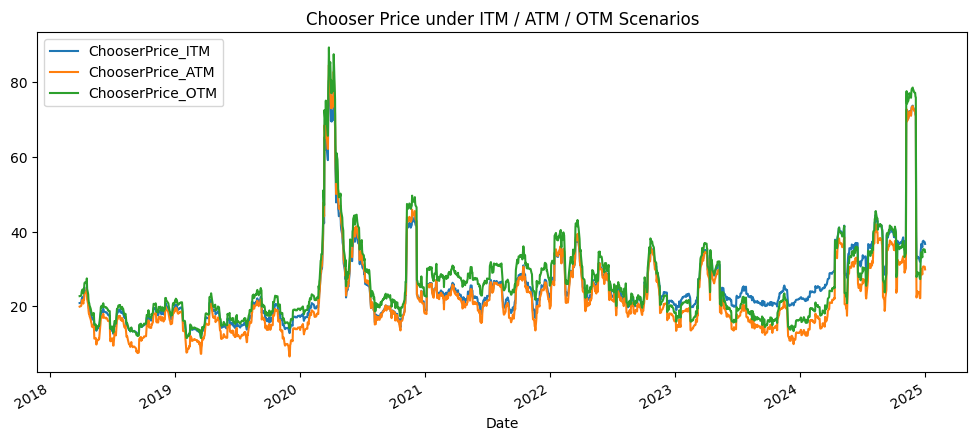

In [147]:
moneyness_data.plot(
    x="Date",
    y=["ChooserPrice_ITM", "ChooserPrice_ATM", "ChooserPrice_OTM"],
    figsize=(12, 5),
    title="Chooser Price under ITM / ATM / OTM Scenarios"
)
plt.show()

In [148]:
moneyness_data["Diff_ITM_minus_ATM"] = moneyness_data["ChooserPrice_ITM"] - moneyness_data["ChooserPrice_ATM"]
moneyness_data["Diff_OTM_minus_ATM"] = moneyness_data["ChooserPrice_OTM"] - moneyness_data["ChooserPrice_ATM"]
moneyness_data["Diff_OTM_minus_ITM"] = moneyness_data["ChooserPrice_OTM"] - moneyness_data["ChooserPrice_ITM"]

moneyness_data[[
    "Diff_ITM_minus_ATM",
    "Diff_OTM_minus_ATM",
    "Diff_OTM_minus_ITM"
]].describe()

,Diff_ITM_minus_ATM,Diff_OTM_minus_ATM,Diff_OTM_minus_ITM
count,1701.000000,1701.000000,1701.000000
mean,2.476274,3.568321,1.092047
std,2.652206,1.260268,3.123491
min,-4.117120,1.821017,-6.909725
25%,0.760159,2.678553,-0.334283
50%,1.796776,3.263107,1.344350
75%,3.726413,4.204311,3.653565
max,10.427390,8.199846,8.829301


In [149]:
moneyness_data.to_csv("data/processed/moneyness_sensitivity.csv", index=False)

In [152]:
import requests
import pandas as pd
import json

api_key = "DRDNSNLGO3KPQJ3V"

url = "https://www.alphavantage.co/query"
params = {
    "function": "HISTORICAL_OPTIONS",
    "symbol": "JPM",
    "date": "2024-12-31",
    "datatype": "json",
    "apikey": api_key
}

r = requests.get(url, params=params, timeout=60)
print("status code:", r.status_code)

data = r.json()
print(type(data))

if isinstance(data, dict):
    print("top-level keys:", list(data.keys())[:10])
else:
    print("returned non-dict data")

status code: 200
<class 'dict'>
top-level keys: ['endpoint', 'message', 'data']


In [153]:
print(json.dumps(data, indent=2)[:5000])

{
  "endpoint": "Historical Options",
  "message": "success",
  "data": [
    {
      "contractID": "JPM250103C00125000",
      "symbol": "JPM",
      "expiration": "2025-01-03",
      "strike": "125.00",
      "type": "call",
      "last": "107.75",
      "mark": "114.90",
      "bid": "113.10",
      "bid_size": "32",
      "ask": "116.70",
      "ask_size": "36",
      "volume": "0",
      "open_interest": "1",
      "date": "2024-12-31",
      "implied_volatility": "3.04895",
      "delta": "0.99370",
      "gamma": "0.00027",
      "theta": "-0.21060",
      "vega": "0.00386",
      "rho": "0.01013"
    },
    {
      "contractID": "JPM250103P00125000",
      "symbol": "JPM",
      "expiration": "2025-01-03",
      "strike": "125.00",
      "type": "put",
      "last": "0.00",
      "mark": "0.01",
      "bid": "0.00",
      "bid_size": "0",
      "ask": "0.01",
      "ask_size": "100",
      "volume": "0",
      "open_interest": "100",
      "date": "2024-12-31",
      "implied_v

In [154]:
options_df = pd.DataFrame(data["data"])
options_df.head()

,contractID,symbol,expiration,strike,type,last,mark,bid,bid_size,ask,ask_size,volume,open_interest,date,implied_volatility,delta,gamma,theta,vega,rho
0,JPM250103C00125000,JPM,2025-01-03,125.00,call,107.75,114.90,113.10,32,116.70,36,0,1,2024-12-31,3.04895,0.99370,0.00027,-0.21060,0.00386,0.01013
1,JPM250103P00125000,JPM,2025-01-03,125.00,put,0.00,0.01,0.00,0,0.01,100,0,100,2024-12-31,2.32702,-0.00070,0.00005,-0.02049,0.00053,-0.00001
2,JPM250103C00130000,JPM,2025-01-03,130.00,call,0.00,109.88,108.10,32,111.65,35,0,0,2024-12-31,2.82457,0.99411,0.00027,-0.18623,0.00363,0.01055
3,JPM250103P00130000,JPM,2025-01-03,130.00,put,0.00,0.01,0.00,0,1.29,1,0,0,2024-12-31,2.19043,-0.00073,0.00005,-0.01999,0.00055,-0.00002
4,JPM250103C00135000,JPM,2025-01-03,135.00,call,0.00,104.88,103.10,32,106.65,35,0,0,2024-12-31,2.65872,0.99386,0.00030,-0.18293,0.00377,0.01096


In [155]:
options_df.columns.tolist()

['contractID',
 'symbol',
 'expiration',
 'strike',
 'type',
 'last',
 'mark',
 'bid',
 'bid_size',
 'ask',
 'ask_size',
 'volume',
 'open_interest',
 'date',
 'implied_volatility',
 'delta',
 'gamma',
 'theta',
 'vega',
 'rho']

In [156]:
options_df["expiration"] = pd.to_datetime(options_df["expiration"])
numeric_cols = ["strike", "last", "mark", "bid", "ask", "volume", "open_interest"]

for col in numeric_cols:
    options_df[col] = pd.to_numeric(options_df[col], errors="coerce")

options_df.dtypes

contractID                    object
symbol                        object
expiration            datetime64[ns]
strike                       float64
type                          object
last                         float64
mark                         float64
bid                          float64
bid_size                      object
ask                          float64
ask_size                      object
volume                         int64
open_interest                  int64
date                          object
implied_volatility            object
delta                         object
gamma                         object
theta                         object
vega                          object
rho                           object
dtype: object

In [157]:
options_df.to_csv("data/raw/jpm_options_2024_12_31_raw.csv", index=False)

In [158]:
options_df["expiration"].sort_values().drop_duplicates().tail(20)

0      2025-01-03
192    2025-01-10
330    2025-01-17
434    2025-01-24
517    2025-01-31
588    2025-02-07
676    2025-02-21
769    2025-03-21
865    2025-04-17
951    2025-05-16
1047   2025-06-20
1157   2025-07-18
1242   2025-08-15
1332   2025-09-19
1445   2025-12-19
1543   2026-01-16
1641   2026-06-18
1721   2026-12-18
1794   2027-01-15
Name: expiration, dtype: datetime64[ns]

In [160]:
target_exp = pd.Timestamp("2025-12-31")

options_df["days_to_target_exp"] = (options_df["expiration"] - target_exp).abs().dt.days

options_df[["expiration", "days_to_target_exp"]].drop_duplicates().sort_values("days_to_target_exp").head(15)

,expiration,days_to_target_exp
1366,2025-12-19,12
1474,2026-01-16,16
1274,2025-09-19,103
1184,2025-08-15,138
1086,2025-07-18,166
1580,2026-06-18,169
972,2025-06-20,194
898,2025-05-16,229
804,2025-04-17,258
704,2025-03-21,285


In [162]:
target_exp = pd.Timestamp("2025-12-31")
options_df["days_to_target_exp"] = (options_df["expiration"] - target_exp).abs().dt.days
chosen_exp = options_df.loc[options_df["days_to_target_exp"].idxmin(), "expiration"]
chosen_exp

Timestamp('2025-12-19 00:00:00')

In [163]:
exp_df = options_df[options_df["expiration"] == chosen_exp].copy()
exp_df.shape

(108, 21)

In [164]:
chosen_exp

Timestamp('2025-12-19 00:00:00')

In [165]:
exp_df["strike_diff_150"] = (exp_df["strike"] - 150).abs()

exp_df[[
    "contractID", "type", "strike", "expiration",
    "last", "mark", "bid", "ask",
    "volume", "open_interest", "implied_volatility",
    "delta", "gamma", "theta", "vega", "rho",
    "strike_diff_150"
]].sort_values(["strike_diff_150", "type"]).head(20)

,contractID,type,strike,expiration,last,mark,bid,ask,volume,open_interest,implied_volatility,delta,gamma,theta,vega,rho,strike_diff_150
1400,JPM251219C00150000,call,150.0,2025-12-19,88.00,93.62,91.80,95.45,0,342,0.01488,1.00000,0.00000,-0.01706,0.00000,1.39119,0.0
1401,JPM251219P00150000,put,150.0,2025-12-19,0.00,1.71,1.66,1.76,0,871,0.33682,-0.04388,0.00117,-0.00901,0.21896,-0.11741,0.0
1398,JPM251219C00145000,call,145.0,2025-12-19,100.18,98.08,96.20,99.95,0,331,0.01488,1.00000,0.00000,-0.01650,0.00000,1.34482,5.0
1402,JPM251219C00155000,call,155.0,2025-12-19,82.70,89.40,87.90,90.90,0,234,0.01488,1.00000,0.00000,-0.01763,0.00000,1.43756,5.0
1399,JPM251219P00145000,put,145.0,2025-12-19,0.00,1.49,1.45,1.53,0,3266,0.34658,-0.03851,0.00102,-0.00840,0.19698,-0.10320,5.0
1403,JPM251219P00155000,put,155.0,2025-12-19,0.00,1.96,1.92,2.01,0,510,0.33682,-0.05388,0.00138,-0.01053,0.25801,-0.14488,5.0
1396,JPM251219C00140000,call,140.0,2025-12-19,102.34,102.25,100.70,103.80,0,365,0.01488,1.00000,0.00000,-0.01593,0.00000,1.29844,10.0
1404,JPM251219C00160000,call,160.0,2025-12-19,83.50,84.80,83.10,86.50,0,484,0.01488,1.00000,0.00000,-0.01820,0.00000,1.48394,10.0
1397,JPM251219P00140000,put,140.0,2025-12-19,0.00,1.30,1.26,1.34,0,1526,0.35633,-0.03367,0.00089,-0.00780,0.17645,-0.09034,10.0
1405,JPM251219P00160000,put,160.0,2025-12-19,0.00,2.26,2.21,2.31,0,1137,0.32707,-0.06083,0.00156,-0.01115,0.28384,-0.16332,10.0


In [166]:
benchmark_call = exp_df[exp_df["type"] == "call"].sort_values("strike_diff_150").head(1)
benchmark_put = exp_df[exp_df["type"] == "put"].sort_values("strike_diff_150").head(1)

benchmark_call
benchmark_put

,contractID,symbol,expiration,strike,type,last,mark,bid,bid_size,ask,...,open_interest,date,implied_volatility,delta,gamma,theta,vega,rho,days_to_target_exp,strike_diff_150
1401,JPM251219P00150000,JPM,2025-12-19,150.0,put,0.0,1.71,1.66,6,1.76,...,871,2024-12-31,0.33682,-0.04388,0.00117,-0.00901,0.21896,-0.11741,12,0.0


In [167]:
benchmark_call = exp_df[(exp_df["type"] == "call") & (exp_df["strike"] == 150)].copy()
benchmark_put = exp_df[(exp_df["type"] == "put") & (exp_df["strike"] == 150)].copy()

benchmark_call
benchmark_put

,contractID,symbol,expiration,strike,type,last,mark,bid,bid_size,ask,...,open_interest,date,implied_volatility,delta,gamma,theta,vega,rho,days_to_target_exp,strike_diff_150
1401,JPM251219P00150000,JPM,2025-12-19,150.0,put,0.0,1.71,1.66,6,1.76,...,871,2024-12-31,0.33682,-0.04388,0.00117,-0.00901,0.21896,-0.11741,12,0.0


In [168]:
model_row = feature_data_ext[feature_data_ext["Date"] == "2024-12-31"].copy()
model_row

,Date,JPM_Close,VIX_Close,Treasury_1Y,Treasury_3M,Treasury_6M,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,...,Sigma_Annual,RiskFree_1Y,ChooserPrice_BSM,BSM_Call,BSM_Put,ChooserPrice_q0,ChooserPrice_q2pct,ChooserPrice_q3pct,Diff_q2_minus_q0,Diff_q3_minus_q0
1700,2024-12-31,239.71,17.35,4.16,4.37,4.24,0.00163,0.001628,-0.002874,-0.01,...,0.186667,0.0416,95.855022,95.854709,0.03272,95.855022,91.121915,88.792478,-4.733106,-7.062544


In [169]:
row = model_row.iloc[0]

S = row["JPM_Close"]
r = row["RiskFree_1Y"]
sigma = row["Sigma_Annual"]
q = 0.02
K = 150
T = 353 / 365   # 2024-12-31 到 2025-12-19 约 353 天

bsm_call = bs_call_price(S, K, r, q, sigma, T)
bsm_put = bs_put_price(S, K, r, q, sigma, T)

print("BSM Call =", bsm_call)
print("BSM Put  =", bsm_put)

BSM Call = 91.07270858783542
BSM Put  = 0.039674215193773454


In [170]:
actual_call_mark = float(benchmark_call["mark"].iloc[0])
actual_put_mark = float(benchmark_put["mark"].iloc[0])

comparison_df = pd.DataFrame({
    "ContractType": ["Call", "Put"],
    "Strike": [150, 150],
    "Expiration": [benchmark_call["expiration"].iloc[0], benchmark_put["expiration"].iloc[0]],
    "BSM_Price": [bsm_call, bsm_put],
    "Actual_Mark": [actual_call_mark, actual_put_mark],
})

comparison_df["Error"] = comparison_df["BSM_Price"] - comparison_df["Actual_Mark"]
comparison_df["AbsError"] = comparison_df["Error"].abs()

comparison_df

,ContractType,Strike,Expiration,BSM_Price,Actual_Mark,Error,AbsError
0,Call,150,2025-12-19,91.072709,93.62,-2.547291,2.547291
1,Put,150,2025-12-19,0.039674,1.71,-1.670326,1.670326


In [171]:
comparison_df.to_csv("outputs/single_day_bsm_vs_market_2024_12_31.csv", index=False)

In [172]:
comparison_df["PctError"] = comparison_df["Error"] / comparison_df["Actual_Mark"]
comparison_df

,ContractType,Strike,Expiration,BSM_Price,Actual_Mark,Error,AbsError,PctError
0,Call,150,2025-12-19,91.072709,93.62,-2.547291,2.547291,-0.027209
1,Put,150,2025-12-19,0.039674,1.71,-1.670326,1.670326,-0.976799


In [173]:
comparison_df["Date"] = pd.Timestamp("2024-12-31")
comparison_df = comparison_df[[
    "Date", "ContractType", "Strike", "Expiration",
    "BSM_Price", "Actual_Mark", "Error", "AbsError"
]]
comparison_df

,Date,ContractType,Strike,Expiration,BSM_Price,Actual_Mark,Error,AbsError
0,2024-12-31,Call,150,2025-12-19,91.072709,93.62,-2.547291,2.547291
1,2024-12-31,Put,150,2025-12-19,0.039674,1.71,-1.670326,1.670326


In [174]:
comparison_df["PctError"] = comparison_df["Error"] / comparison_df["Actual_Mark"]
comparison_df

,Date,ContractType,Strike,Expiration,BSM_Price,Actual_Mark,Error,AbsError,PctError
0,2024-12-31,Call,150,2025-12-19,91.072709,93.62,-2.547291,2.547291,-0.027209
1,2024-12-31,Put,150,2025-12-19,0.039674,1.71,-1.670326,1.670326,-0.976799


In [191]:
import requests
import pandas as pd
import numpy as np

api_key = "DRDNSNLGO3KPQJ3V"

def get_options_chain_for_date(symbol, date_str, api_key):
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "HISTORICAL_OPTIONS",
        "symbol": symbol,
        "date": date_str,
        "datatype": "json",
        "apikey": api_key
    }
    
    r = requests.get(url, params=params, timeout=60)
    data = r.json()
    
    if "data" not in data:
        return None, data
    
    df = pd.DataFrame(data["data"])
    
    if df.empty:
        return df, data
    
    df["expiration"] = pd.to_datetime(df["expiration"], errors="coerce")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    numeric_cols = [
        "strike", "last", "mark", "bid", "ask", "volume", "open_interest",
        "implied_volatility", "delta", "gamma", "theta", "vega", "rho"
    ]
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    return df, data

In [192]:
def select_benchmark_contracts(options_df, target_strike=150, target_expiry="2025-12-31"):
    if options_df is None or options_df.empty:
        return None, None, None
    
    target_exp = pd.Timestamp(target_expiry)
    options_df = options_df.copy()
    options_df["days_to_target_exp"] = (options_df["expiration"] - target_exp).abs().dt.days
    
    chosen_exp = options_df.loc[options_df["days_to_target_exp"].idxmin(), "expiration"]
    exp_df = options_df[options_df["expiration"] == chosen_exp].copy()
    
    exp_df["strike_diff"] = (exp_df["strike"] - target_strike).abs()
    
    benchmark_call = exp_df[exp_df["type"] == "call"].sort_values("strike_diff").head(1)
    benchmark_put = exp_df[exp_df["type"] == "put"].sort_values("strike_diff").head(1)
    
    return chosen_exp, benchmark_call, benchmark_put

In [193]:
def compare_bsm_vs_market_for_date(
    date_str,
    feature_df,
    api_key,
    symbol="JPM",
    target_strike=150,
    q=0.02
):
    # 1. 拉期权链
    options_df, raw_data = get_options_chain_for_date(symbol, date_str, api_key)
    if options_df is None or options_df.empty:
        return None, options_df
    
    # 2. 用 date_str 推目标到期日 = 一年后附近
    trade_date = pd.Timestamp(date_str)
    target_expiry = trade_date + pd.Timedelta(days=365)
    
    chosen_exp, benchmark_call, benchmark_put = select_benchmark_contracts(
        options_df,
        target_strike=target_strike,
        target_expiry=target_expiry.strftime("%Y-%m-%d")
    )
    
    if benchmark_call is None or benchmark_put is None:
        return None, options_df
    
    # 3. 取模型那一天的输入
    model_row = feature_df[feature_df["Date"] == trade_date].copy()
    if model_row.empty:
        return None, options_df
    
    row = model_row.iloc[0]
    
    S = row["JPM_Close"]
    r = row["RiskFree_1Y"]
    sigma = row["Sigma_Annual"]
    K = target_strike
    T = (chosen_exp - trade_date).days / 365
    
    # 4. 算 BSM
    bsm_call = bs_call_price(S, K, r, q, sigma, T)
    bsm_put = bs_put_price(S, K, r, q, sigma, T)
    
    actual_call_mark = float(benchmark_call["mark"].iloc[0])
    actual_put_mark = float(benchmark_put["mark"].iloc[0])
    
    result_df = pd.DataFrame({
        "Date": [trade_date, trade_date],
        "ContractType": ["Call", "Put"],
        "Strike": [target_strike, target_strike],
        "Expiration": [chosen_exp, chosen_exp],
        "S": [S, S],
        "r": [r, r],
        "sigma": [sigma, sigma],
        "q": [q, q],
        "T": [T, T],
        "BSM_Price": [bsm_call, bsm_put],
        "Actual_Mark": [actual_call_mark, actual_put_mark]
    })
    
    result_df["Error"] = result_df["BSM_Price"] - result_df["Actual_Mark"]
    result_df["AbsError"] = result_df["Error"].abs()
    result_df["PctError"] = result_df["Error"] / result_df["Actual_Mark"]
    
    return result_df, options_df

In [194]:
single_result, single_options = compare_bsm_vs_market_for_date(
    date_str="2024-12-31",
    feature_df=feature_data_ext,
    api_key=api_key,
    symbol="JPM",
    target_strike=150,
    q=0.02
)

single_result

,Date,ContractType,Strike,Expiration,S,r,sigma,q,T,BSM_Price,Actual_Mark,Error,AbsError,PctError
0,2024-12-31,Call,150,2025-12-19,239.71,0.0416,0.186667,0.02,0.967123,91.072709,93.62,-2.547291,2.547291,-0.027209
1,2024-12-31,Put,150,2025-12-19,239.71,0.0416,0.186667,0.02,0.967123,0.039674,1.71,-1.670326,1.670326,-0.976799


In [195]:
test_dates = ["2020-03-16", "2021-06-30", "2023-12-29", "2024-12-31"]

all_results = []
all_option_chains = {}

for d in test_dates:
    print("Running:", d)
    result_df, options_df = compare_bsm_vs_market_for_date(
        date_str=d,
        feature_df=feature_data_ext,
        api_key=api_key,
        symbol="JPM",
        target_strike=150,
        q=0.02
    )
    
    if result_df is not None:
        all_results.append(result_df)
    
    if options_df is not None:
        all_option_chains[d] = options_df

Running: 2020-03-16
Running: 2021-06-30
Running: 2023-12-29
Running: 2024-12-31


In [196]:
multi_date_comparison = pd.concat(all_results, ignore_index=True)
multi_date_comparison

,Date,ContractType,Strike,Expiration,S,r,sigma,q,T,BSM_Price,Actual_Mark,Error,AbsError,PctError
0,2020-03-16,Call,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,24.411221,1.76,22.651221,22.651221,12.870012
1,2020-03-16,Put,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,87.377168,65.00,22.377168,22.377168,0.344264
2,2021-06-30,Call,150,2022-06-17,155.54,0.0007,0.196631,0.02,0.964384,13.015589,15.47,-2.454411,2.454411,-0.158656
3,2021-06-30,Put,150,2022-06-17,155.54,0.0007,0.196631,0.02,0.964384,10.345621,12.88,-2.534379,2.534379,-0.196769
4,2023-12-29,Call,150,2024-12-20,170.10,0.0479,0.109714,0.02,0.978082,24.270493,30.05,-5.779507,5.779507,-0.192330
5,2023-12-29,Put,150,2024-12-20,170.10,0.0479,0.109714,0.02,0.978082,0.600153,6.05,-5.449847,5.449847,-0.900801
6,2024-12-31,Call,150,2025-12-19,239.71,0.0416,0.186667,0.02,0.967123,91.072709,93.62,-2.547291,2.547291,-0.027209
7,2024-12-31,Put,150,2025-12-19,239.71,0.0416,0.186667,0.02,0.967123,0.039674,1.71,-1.670326,1.670326,-0.976799


In [197]:
summary_by_type = multi_date_comparison.groupby("ContractType").agg(
    MAE=("AbsError", "mean"),
    RMSE=("Error", lambda x: np.sqrt(np.mean(x**2))),
    MeanError=("Error", "mean"),
    MeanPctError=("PctError", "mean"),
    Count=("Error", "count")
).reset_index()

summary_by_type

,ContractType,MAE,RMSE,MeanError,MeanPctError,Count
0,Call,8.358108,11.821520,2.967503,3.122954,4
1,Put,8.007930,11.615201,3.180654,-0.432526,4


In [198]:
overall_summary = pd.DataFrame({
    "MAE": [multi_date_comparison["AbsError"].mean()],
    "RMSE": [np.sqrt(np.mean(multi_date_comparison["Error"]**2))],
    "MeanError": [multi_date_comparison["Error"].mean()],
    "MeanPctError": [multi_date_comparison["PctError"].mean()],
    "Count": [len(multi_date_comparison)]
})

overall_summary

,MAE,RMSE,MeanError,MeanPctError,Count
0,8.183019,11.718815,3.074078,1.345214,8


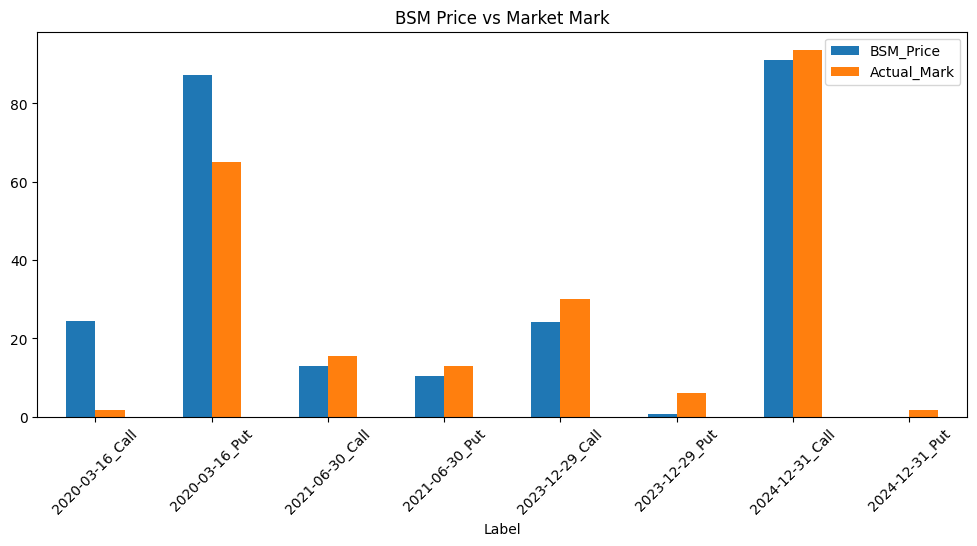

In [199]:
plot_df = multi_date_comparison.copy()
plot_df["Label"] = plot_df["Date"].dt.strftime("%Y-%m-%d") + "_" + plot_df["ContractType"]

plot_df.plot(
    x="Label",
    y=["BSM_Price", "Actual_Mark"],
    kind="bar",
    figsize=(12, 5),
    title="BSM Price vs Market Mark"
)
plt.xticks(rotation=45)
plt.show()

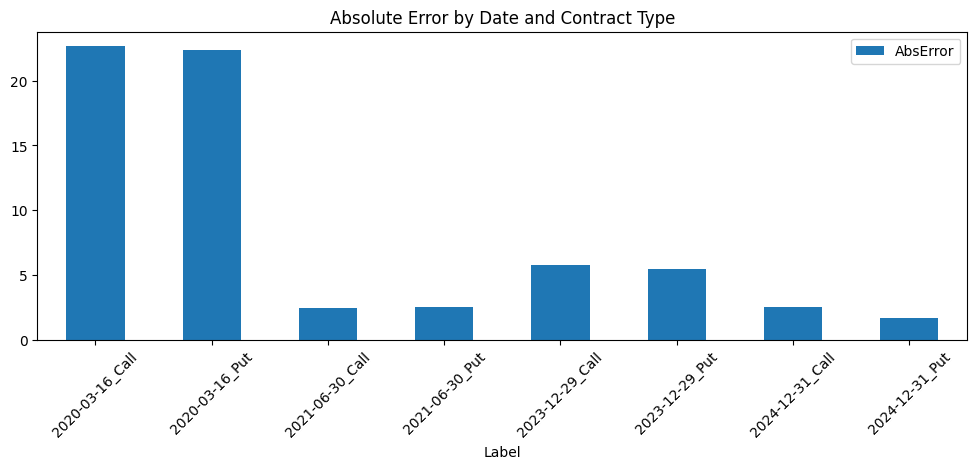

In [200]:
plot_df.plot(
    x="Label",
    y="AbsError",
    kind="bar",
    figsize=(12, 4),
    title="Absolute Error by Date and Contract Type"
)
plt.xticks(rotation=45)
plt.show()

In [201]:
multi_date_comparison["Moneyness"] = multi_date_comparison["S"] / multi_date_comparison["Strike"]
multi_date_comparison

,Date,ContractType,Strike,Expiration,S,r,sigma,q,T,BSM_Price,Actual_Mark,Error,AbsError,PctError,Moneyness
0,2020-03-16,Call,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,24.411221,1.76,22.651221,22.651221,12.870012,0.589067
1,2020-03-16,Put,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,87.377168,65.00,22.377168,22.377168,0.344264,0.589067
2,2021-06-30,Call,150,2022-06-17,155.54,0.0007,0.196631,0.02,0.964384,13.015589,15.47,-2.454411,2.454411,-0.158656,1.036933
3,2021-06-30,Put,150,2022-06-17,155.54,0.0007,0.196631,0.02,0.964384,10.345621,12.88,-2.534379,2.534379,-0.196769,1.036933
4,2023-12-29,Call,150,2024-12-20,170.10,0.0479,0.109714,0.02,0.978082,24.270493,30.05,-5.779507,5.779507,-0.192330,1.134000
5,2023-12-29,Put,150,2024-12-20,170.10,0.0479,0.109714,0.02,0.978082,0.600153,6.05,-5.449847,5.449847,-0.900801,1.134000
6,2024-12-31,Call,150,2025-12-19,239.71,0.0416,0.186667,0.02,0.967123,91.072709,93.62,-2.547291,2.547291,-0.027209,1.598067
7,2024-12-31,Put,150,2025-12-19,239.71,0.0416,0.186667,0.02,0.967123,0.039674,1.71,-1.670326,1.670326,-0.976799,1.598067


In [202]:
multi_date_comparison.to_csv("data/processed/multi_date_bsm_vs_market_comparison.csv", index=False)
summary_by_type.to_csv("outputs/multi_date_bsm_error_summary_by_type.csv", index=False)
overall_summary.to_csv("outputs/multi_date_bsm_error_summary_overall.csv", index=False)

In [203]:
test_dates_ext = [
    "2018-06-29", "2018-12-31",
    "2019-06-28", "2019-12-31",
    "2020-03-16", "2020-06-30",
    "2021-06-30", "2021-12-31",
    "2022-06-30", "2022-12-30",
    "2023-12-29", "2024-12-31"
]

In [204]:
all_results_ext = []
all_option_chains_ext = {}

for d in test_dates_ext:
    print("Running:", d)
    result_df, options_df = compare_bsm_vs_market_for_date(
        date_str=d,
        feature_df=feature_data_ext,
        api_key=api_key,
        symbol="JPM",
        target_strike=150,
        q=0.02
    )
    
    if result_df is not None:
        all_results_ext.append(result_df)
    
    if options_df is not None:
        all_option_chains_ext[d] = options_df

Running: 2018-06-29
Running: 2018-12-31
Running: 2019-06-28
Running: 2019-12-31
Running: 2020-03-16
Running: 2020-06-30
Running: 2021-06-30
Running: 2021-12-31
Running: 2022-06-30
Running: 2022-12-30
Running: 2023-12-29
Running: 2024-12-31


In [205]:
multi_date_comparison_ext = pd.concat(all_results_ext, ignore_index=True)
multi_date_comparison_ext

,Date,ContractType,Strike,Expiration,S,r,sigma,q,T,BSM_Price,Actual_Mark,Error,AbsError,PctError
0,2018-06-29,Call,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,0.059933,0.33,-0.270067,0.270067,-0.818386
1,2018-06-29,Put,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,44.498709,45.35,-0.851291,0.851291,-0.018772
2,2018-12-31,Call,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,1.126511,0.16,0.966511,0.966511,6.040695
3,2018-12-31,Put,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,51.456172,53.15,-1.693828,1.693828,-0.031869
4,2019-06-28,Call,150,2020-06-19,111.80,0.0192,0.180444,0.02,0.978082,0.464887,0.33,0.134887,0.134887,0.408748
5,2019-06-28,Put,150,2020-06-19,111.80,0.0192,0.180444,0.02,0.978082,38.040035,39.45,-1.409965,1.409965,-0.035741
6,2019-12-31,Call,150,2020-12-18,139.40,0.0159,0.153197,0.02,0.967123,4.145133,6.55,-2.404867,2.404867,-0.367155
7,2019-12-31,Put,150,2020-12-18,139.40,0.0159,0.153197,0.02,0.967123,15.126618,18.30,-3.173382,3.173382,-0.173409
8,2020-03-16,Call,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,24.411221,1.76,22.651221,22.651221,12.870012
9,2020-03-16,Put,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,87.377168,65.00,22.377168,22.377168,0.344264


In [206]:
summary_by_type_ext = multi_date_comparison_ext.groupby("ContractType").agg(
    MAE=("AbsError", "mean"),
    RMSE=("Error", lambda x: np.sqrt(np.mean(x**2))),
    MeanError=("Error", "mean"),
    MeanPctError=("PctError", "mean"),
    Count=("Error", "count")
).reset_index()

summary_by_type_ext

,ContractType,MAE,RMSE,MeanError,MeanPctError,Count
0,Call,4.428790,7.310743,0.610381,1.940076,12
1,Put,4.746498,7.358725,-0.228230,-0.217120,12


In [207]:
overall_summary_ext = pd.DataFrame({
    "MAE": [multi_date_comparison_ext["AbsError"].mean()],
    "RMSE": [np.sqrt(np.mean(multi_date_comparison_ext["Error"]**2))],
    "MeanError": [multi_date_comparison_ext["Error"].mean()],
    "MeanPctError": [multi_date_comparison_ext["PctError"].mean()],
    "Count": [len(multi_date_comparison_ext)]
})

overall_summary_ext

,MAE,RMSE,MeanError,MeanPctError,Count
0,4.587644,7.334773,0.191075,0.861478,24


In [208]:
date_summary_ext = multi_date_comparison_ext.groupby("Date").agg(
    MAE=("AbsError", "mean"),
    RMSE=("Error", lambda x: np.sqrt(np.mean(x**2))),
    MeanError=("Error", "mean")
).reset_index()

date_summary_ext

,Date,MAE,RMSE,MeanError
0,2018-06-29,0.560679,0.631519,-0.560679
1,2018-12-31,1.330169,1.378984,-0.363658
2,2019-06-28,0.772426,1.001548,-0.637539
3,2019-12-31,2.789124,2.815469,-2.789124
4,2020-03-16,22.514195,22.514612,22.514195
5,2020-06-30,5.087467,5.099840,5.087467
6,2021-06-30,2.494395,2.494716,-2.494395
7,2021-12-31,5.256589,5.262071,-5.256589
8,2022-06-30,1.124947,1.128156,-0.085040
9,2022-12-30,5.398247,5.483016,-5.398247


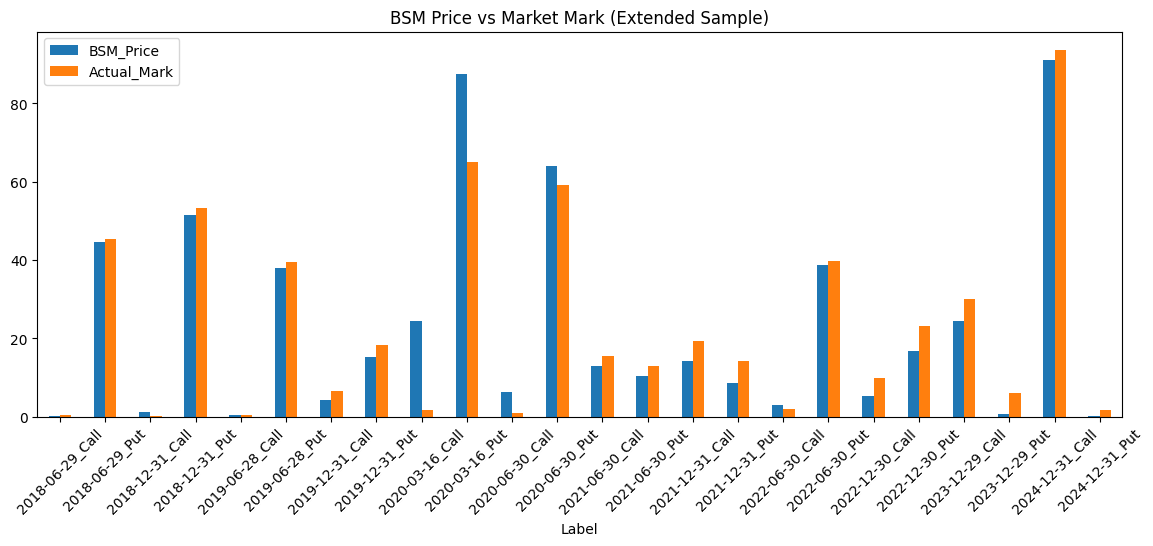

In [209]:
plot_df_ext = multi_date_comparison_ext.copy()
plot_df_ext["Label"] = plot_df_ext["Date"].dt.strftime("%Y-%m-%d") + "_" + plot_df_ext["ContractType"]

plot_df_ext.plot(
    x="Label",
    y=["BSM_Price", "Actual_Mark"],
    kind="bar",
    figsize=(14, 5),
    title="BSM Price vs Market Mark (Extended Sample)"
)
plt.xticks(rotation=45)
plt.show()

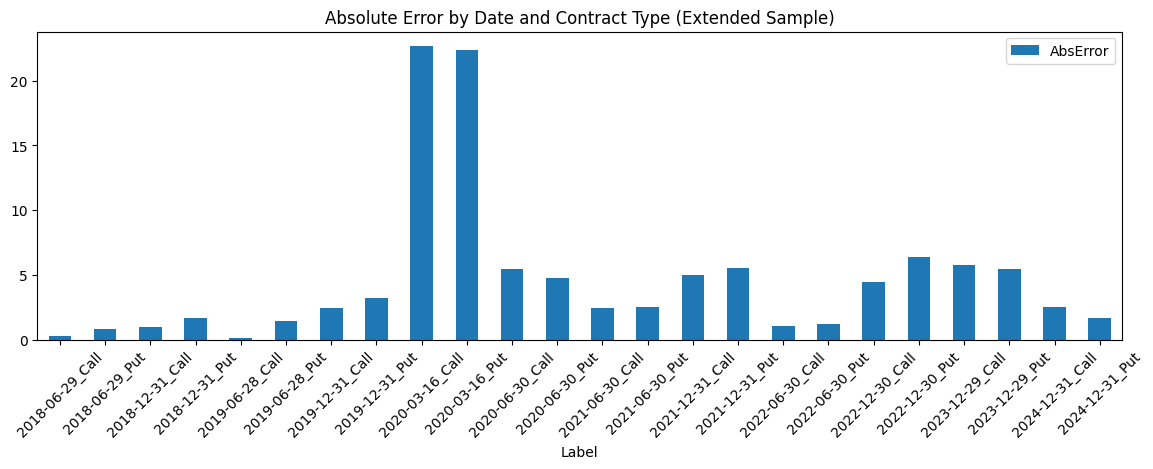

In [210]:
plot_df_ext.plot(
    x="Label",
    y="AbsError",
    kind="bar",
    figsize=(14, 4),
    title="Absolute Error by Date and Contract Type (Extended Sample)"
)
plt.xticks(rotation=45)
plt.show()

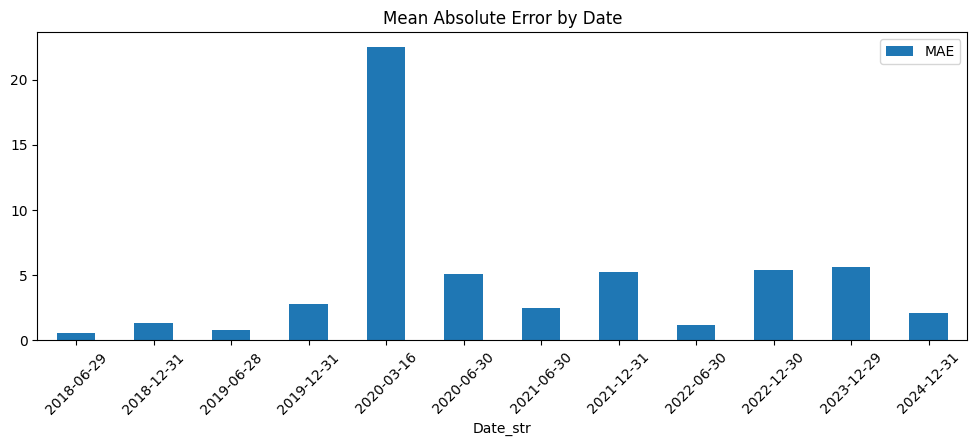

In [211]:
date_summary_ext["Date_str"] = date_summary_ext["Date"].dt.strftime("%Y-%m-%d")
date_summary_ext.plot(
    x="Date_str",
    y="MAE",
    kind="bar",
    figsize=(12, 4),
    title="Mean Absolute Error by Date"
)
plt.xticks(rotation=45)
plt.show()

In [212]:
multi_date_comparison_ext["Moneyness"] = multi_date_comparison_ext["S"] / multi_date_comparison_ext["Strike"]
multi_date_comparison_ext

,Date,ContractType,Strike,Expiration,S,r,sigma,q,T,BSM_Price,Actual_Mark,Error,AbsError,PctError,Moneyness
0,2018-06-29,Call,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,0.059933,0.33,-0.270067,0.270067,-0.818386,0.694667
1,2018-06-29,Put,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,44.498709,45.35,-0.851291,0.851291,-0.018772,0.694667
2,2018-12-31,Call,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,1.126511,0.16,0.966511,0.966511,6.040695,0.650800
3,2018-12-31,Put,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,51.456172,53.15,-1.693828,1.693828,-0.031869,0.650800
4,2019-06-28,Call,150,2020-06-19,111.80,0.0192,0.180444,0.02,0.978082,0.464887,0.33,0.134887,0.134887,0.408748,0.745333
5,2019-06-28,Put,150,2020-06-19,111.80,0.0192,0.180444,0.02,0.978082,38.040035,39.45,-1.409965,1.409965,-0.035741,0.745333
6,2019-12-31,Call,150,2020-12-18,139.40,0.0159,0.153197,0.02,0.967123,4.145133,6.55,-2.404867,2.404867,-0.367155,0.929333
7,2019-12-31,Put,150,2020-12-18,139.40,0.0159,0.153197,0.02,0.967123,15.126618,18.30,-3.173382,3.173382,-0.173409,0.929333
8,2020-03-16,Call,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,24.411221,1.76,22.651221,22.651221,12.870012,0.589067
9,2020-03-16,Put,150,2021-03-19,88.36,0.0029,1.134553,0.02,1.008219,87.377168,65.00,22.377168,22.377168,0.344264,0.589067


In [213]:
def classify_moneyness(x):
    if x > 1.1:
        return "ITM"
    elif x < 0.9:
        return "OTM"
    else:
        return "Near-ATM"

multi_date_comparison_ext["MoneynessGroup"] = multi_date_comparison_ext["Moneyness"].apply(classify_moneyness)

In [214]:
money_summary_ext = multi_date_comparison_ext.groupby("MoneynessGroup").agg(
    MAE=("AbsError", "mean"),
    RMSE=("Error", lambda x: np.sqrt(np.mean(x**2))),
    Count=("Error", "count")
).reset_index()

money_summary_ext

,MoneynessGroup,MAE,RMSE,Count
0,ITM,3.861743,4.253887,4
1,Near-ATM,3.513370,3.734517,6
2,OTM,5.255447,9.004410,14


In [215]:
multi_date_comparison_ext.to_csv("data/processed/multi_date_bsm_vs_market_comparison_extended.csv", index=False)
summary_by_type_ext.to_csv("outputs/multi_date_bsm_error_summary_by_type_extended.csv", index=False)
overall_summary_ext.to_csv("outputs/multi_date_bsm_error_summary_overall_extended.csv", index=False)
date_summary_ext.to_csv("outputs/multi_date_bsm_error_summary_by_date_extended.csv", index=False)

In [216]:
money_summary_ext.to_csv("outputs/multi_date_bsm_error_summary_by_moneyness.csv", index=False)

In [217]:
ml_data = feature_data_ext.copy()

In [218]:
ml_data["FutureRealizedVol20D"] = np.sqrt(
    ml_data["JPM_LogReturn"].shift(-1).rolling(20).apply(lambda x: np.sum(x**2), raw=True)
)

In [219]:
ml_data[["Date", "JPM_LogReturn", "FutureRealizedVol20D"]].head(25)

,Date,JPM_LogReturn,FutureRealizedVol20D
0,2018-03-29,0.018076,NaN
1,2018-04-02,-0.019466,NaN
2,2018-04-03,0.013629,NaN
3,2018-04-04,0.015069,NaN
4,2018-04-05,0.007987,NaN
5,2018-04-06,-0.025254,NaN
6,2018-04-09,0.011937,NaN
7,2018-04-10,0.018932,NaN
8,2018-04-11,-0.016941,NaN
9,2018-04-12,0.024556,NaN


In [220]:
ml_data[["Date", "FutureRealizedVol20D"]].tail(25)

,Date,FutureRealizedVol20D
1676,2024-11-25,0.124134
1677,2024-11-26,0.123952
1678,2024-11-27,0.123449
1679,2024-11-29,0.124155
1680,2024-12-02,0.123469
1681,2024-12-03,0.123363
1682,2024-12-04,0.057917
1683,2024-12-05,0.038208
1684,2024-12-06,0.040772
1685,2024-12-09,0.039793


In [221]:
feature_cols = [
    "JPM_Return",
    "JPM_LogReturn",
    "VIX_Return",
    "Treasury_1Y_Change",
    "Treasury_1Y_Mom_5D",
    "Treasury_1Y_Mom_20D",
    "Corr_JPM_VIX_20D",
    "Corr_JPM_VIX_60D",
    "JPM_Vol_5D",
    "JPM_Vol_10D",
    "JPM_Vol_20D",
    "RealizedVol_5D",
    "RealizedVol_20D",
    "VolOfVol_20D",
    "Treasury_3M",
    "Treasury_6M",
    "Treasury_1Y"
]

In [222]:
ml_vol_data = ml_data[["Date"] + feature_cols + ["FutureRealizedVol20D"]].dropna().reset_index(drop=True)
ml_vol_data.head()

,Date,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,Treasury_1Y_Mom_5D,Treasury_1Y_Mom_20D,Corr_JPM_VIX_20D,Corr_JPM_VIX_60D,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D,RealizedVol_5D,RealizedVol_20D,VolOfVol_20D,Treasury_3M,Treasury_6M,Treasury_1Y,FutureRealizedVol20D
0,2018-04-26,0.001000,0.001000,-0.089686,-0.01,0.018100,0.061321,-0.541691,-0.718106,0.002425,0.011889,0.015475,0.008137,0.067593,0.001592,1.82,2.02,2.25,0.065443
1,2018-04-27,-0.006358,-0.006378,-0.051108,-0.01,0.009009,0.071770,-0.482786,-0.714328,0.002810,0.008421,0.015011,0.010093,0.065443,0.001736,1.82,2.02,2.24,0.062739
2,2018-04-30,-0.005667,-0.005683,0.033744,0.00,-0.004444,0.076923,-0.406388,-0.715737,0.002914,0.008560,0.014387,0.010516,0.062739,0.001931,1.87,2.04,2.24,0.061240
3,2018-05-01,0.000000,0.000000,-0.027621,0.02,0.004444,0.081340,-0.363983,-0.707157,0.003327,0.008560,0.014047,0.009408,0.061240,0.002125,1.85,2.05,2.26,0.059886
4,2018-05-02,-0.007906,-0.007937,0.030988,-0.02,-0.008850,0.082126,-0.354663,-0.779392,0.004025,0.008545,0.013663,0.011704,0.059886,0.002322,1.84,2.03,2.24,0.059686


In [223]:
print(ml_vol_data.shape)
print(ml_vol_data.isna().sum())

(1681, 19)
Date                    0
JPM_Return              0
JPM_LogReturn           0
VIX_Return              0
Treasury_1Y_Change      0
Treasury_1Y_Mom_5D      0
Treasury_1Y_Mom_20D     0
Corr_JPM_VIX_20D        0
Corr_JPM_VIX_60D        0
JPM_Vol_5D              0
JPM_Vol_10D             0
JPM_Vol_20D             0
RealizedVol_5D          0
RealizedVol_20D         0
VolOfVol_20D            0
Treasury_3M             0
Treasury_6M             0
Treasury_1Y             0
FutureRealizedVol20D    0
dtype: int64


In [224]:
n = len(ml_vol_data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = ml_vol_data.iloc[:train_end].copy()
val_data = ml_vol_data.iloc[train_end:val_end].copy()
test_data = ml_vol_data.iloc[val_end:].copy()

print("train:", train_data.shape)
print("val:", val_data.shape)
print("test:", test_data.shape)

train: (1176, 19)
val: (252, 19)
test: (253, 19)


In [225]:
print("Train:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Val:", val_data["Date"].min(), "to", val_data["Date"].max())
print("Test:", test_data["Date"].min(), "to", test_data["Date"].max())

Train: 2018-04-26 00:00:00 to 2022-12-23 00:00:00
Val: 2022-12-27 00:00:00 to 2023-12-27 00:00:00
Test: 2023-12-28 00:00:00 to 2024-12-30 00:00:00


In [226]:
ml_vol_data.to_csv("data/processed/ml_volatility_dataset.csv", index=False)
train_data.to_csv("data/processed/ml_volatility_train.csv", index=False)
val_data.to_csv("data/processed/ml_volatility_val.csv", index=False)
test_data.to_csv("data/processed/ml_volatility_test.csv", index=False)

In [228]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [229]:
X_train = train_data[feature_cols]
y_train = train_data["FutureRealizedVol20D"]

X_val = val_data[feature_cols]
y_val = val_data["FutureRealizedVol20D"]

X_test = test_data[feature_cols]
y_test = test_data["FutureRealizedVol20D"]

In [230]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [231]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [232]:
y_train_pred = lr_model.predict(X_train_scaled)
y_val_pred = lr_model.predict(X_val_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

In [233]:
def regression_metrics(y_true, y_pred, label="set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{label} MAE:  {mae:.6f}")
    print(f"{label} RMSE: {rmse:.6f}")
    print(f"{label} R2:   {r2:.6f}")

In [234]:
regression_metrics(y_train, y_train_pred, "Train")
print()
regression_metrics(y_val, y_val_pred, "Validation")
print()
regression_metrics(y_test, y_test_pred, "Test")

Train MAE:  0.003053
Train RMSE: 0.005625
Train R2:   0.987273

Validation MAE:  0.002827
Validation RMSE: 0.004657
Validation R2:   0.947111

Test MAE:  0.003949
Test RMSE: 0.007737
Test R2:   0.895263


In [235]:
train_results = train_data[["Date", "FutureRealizedVol20D"]].copy()
train_results["PredictedVol_LR"] = y_train_pred
train_results["Set"] = "Train"

val_results = val_data[["Date", "FutureRealizedVol20D"]].copy()
val_results["PredictedVol_LR"] = y_val_pred
val_results["Set"] = "Validation"

test_results = test_data[["Date", "FutureRealizedVol20D"]].copy()
test_results["PredictedVol_LR"] = y_test_pred
test_results["Set"] = "Test"

lr_results = pd.concat([train_results, val_results, test_results], axis=0).reset_index(drop=True)
lr_results.head()

,Date,FutureRealizedVol20D,PredictedVol_LR,Set
0,2018-04-26,0.065443,0.065223,Train
1,2018-04-27,0.062739,0.062831,Train
2,2018-04-30,0.061240,0.060443,Train
3,2018-05-01,0.059886,0.059047,Train
4,2018-05-02,0.059686,0.058246,Train


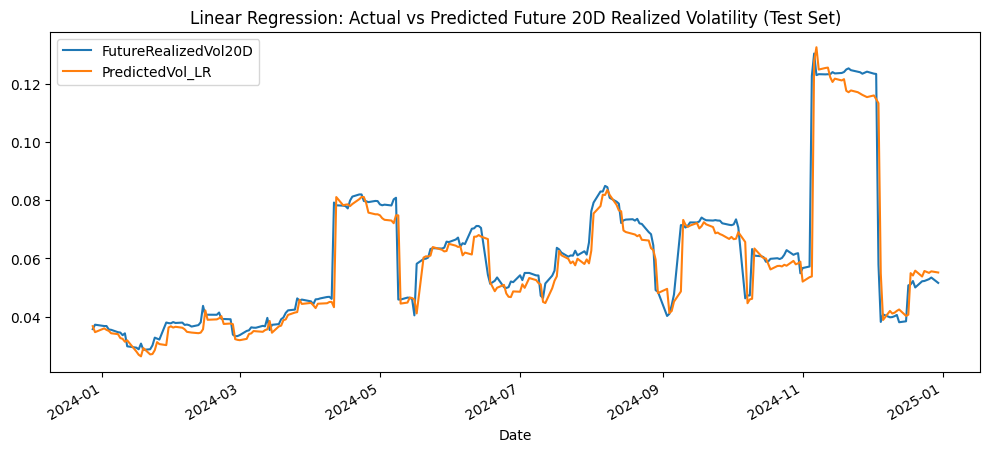

In [236]:
test_results.plot(
    x="Date",
    y=["FutureRealizedVol20D", "PredictedVol_LR"],
    figsize=(12, 5),
    title="Linear Regression: Actual vs Predicted Future 20D Realized Volatility (Test Set)"
)
plt.show()

In [237]:
lr_results.to_csv("data/processed/ml_linear_regression_vol_predictions.csv", index=False)

In [238]:
metrics_df = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_val, y_val_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    "RMSE": [
        mean_squared_error(y_train, y_train_pred, squared=False),
        mean_squared_error(y_val, y_val_pred, squared=False),
        mean_squared_error(y_test, y_test_pred, squared=False)
    ],
    "R2": [
        r2_score(y_train, y_train_pred),
        r2_score(y_val, y_val_pred),
        r2_score(y_test, y_test_pred)
    ]
})

metrics_df.to_csv("outputs/ml_linear_regression_metrics.csv", index=False)
metrics_df

,Set,MAE,RMSE,R2
0,Train,0.003053,0.005625,0.987273
1,Validation,0.002827,0.004657,0.947111
2,Test,0.003949,0.007737,0.895263


In [239]:
from sklearn.ensemble import RandomForestRegressor

In [240]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [241]:
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

In [242]:
regression_metrics(y_train, y_train_pred_rf, "RF Train")
print()
regression_metrics(y_val, y_val_pred_rf, "RF Validation")
print()
regression_metrics(y_test, y_test_pred_rf, "RF Test")

RF Train MAE:  0.002689
RF Train RMSE: 0.004934
RF Train R2:   0.990207

RF Validation MAE:  0.002446
RF Validation RMSE: 0.004587
RF Validation R2:   0.948673

RF Test MAE:  0.003238
RF Test RMSE: 0.007750
RF Test R2:   0.894903


In [243]:
train_results_rf = train_data[["Date", "FutureRealizedVol20D"]].copy()
train_results_rf["PredictedVol_RF"] = y_train_pred_rf
train_results_rf["Set"] = "Train"

val_results_rf = val_data[["Date", "FutureRealizedVol20D"]].copy()
val_results_rf["PredictedVol_RF"] = y_val_pred_rf
val_results_rf["Set"] = "Validation"

test_results_rf = test_data[["Date", "FutureRealizedVol20D"]].copy()
test_results_rf["PredictedVol_RF"] = y_test_pred_rf
test_results_rf["Set"] = "Test"

rf_results = pd.concat([train_results_rf, val_results_rf, test_results_rf], axis=0).reset_index(drop=True)
rf_results.head()

,Date,FutureRealizedVol20D,PredictedVol_RF,Set
0,2018-04-26,0.065443,0.067666,Train
1,2018-04-27,0.062739,0.065666,Train
2,2018-04-30,0.061240,0.062412,Train
3,2018-05-01,0.059886,0.061890,Train
4,2018-05-02,0.059686,0.060869,Train


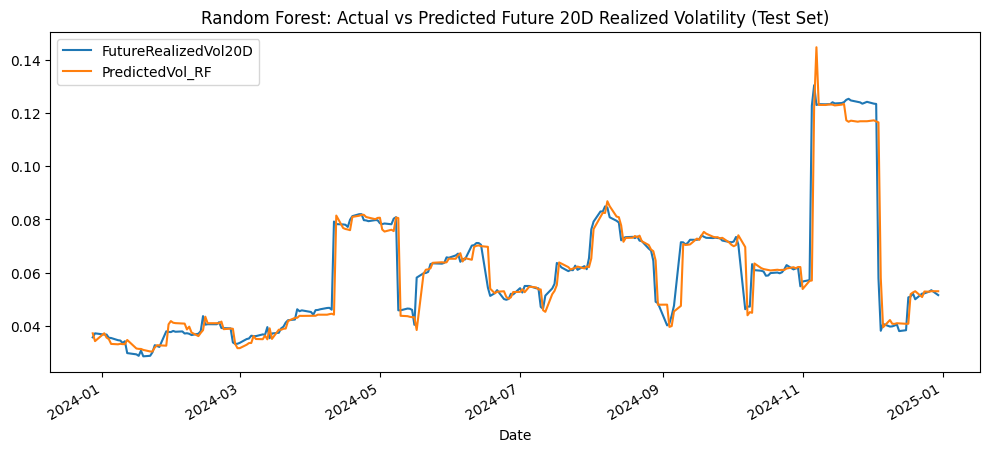

In [244]:
test_results_rf.plot(
    x="Date",
    y=["FutureRealizedVol20D", "PredictedVol_RF"],
    figsize=(12, 5),
    title="Random Forest: Actual vs Predicted Future 20D Realized Volatility (Test Set)"
)
plt.show()

In [245]:
rf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance

,Feature,Importance
12,RealizedVol_20D,0.714078
10,JPM_Vol_20D,0.239513
9,JPM_Vol_10D,0.035604
6,Corr_JPM_VIX_20D,0.005127
13,VolOfVol_20D,0.001514
5,Treasury_1Y_Mom_20D,0.001182
14,Treasury_3M,0.000673
16,Treasury_1Y,0.000650
7,Corr_JPM_VIX_60D,0.000336
15,Treasury_6M,0.000327


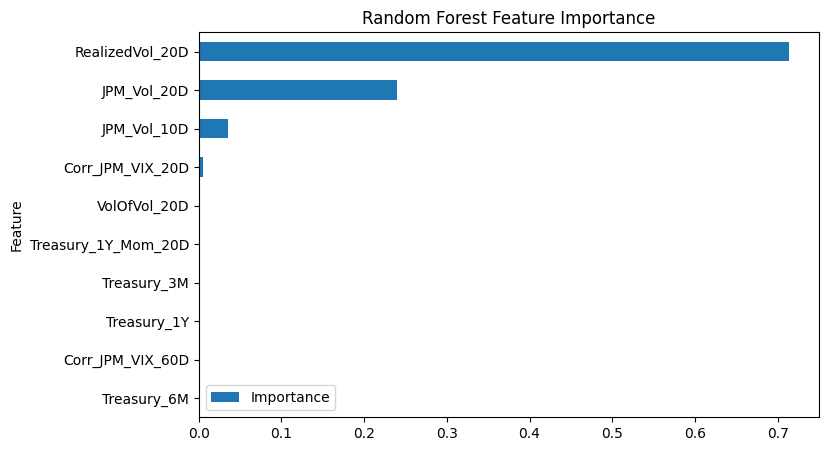

In [246]:
rf_importance.head(10).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 5),
    title="Random Forest Feature Importance"
)
plt.show()

In [247]:
rf_results.to_csv("data/processed/ml_random_forest_vol_predictions.csv", index=False)

rf_metrics_df = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred_rf),
        mean_absolute_error(y_val, y_val_pred_rf),
        mean_absolute_error(y_test, y_test_pred_rf)
    ],
    "RMSE": [
        mean_squared_error(y_train, y_train_pred_rf, squared=False),
        mean_squared_error(y_val, y_val_pred_rf, squared=False),
        mean_squared_error(y_test, y_test_pred_rf, squared=False)
    ],
    "R2": [
        r2_score(y_train, y_train_pred_rf),
        r2_score(y_val, y_val_pred_rf),
        r2_score(y_test, y_test_pred_rf)
    ]
})

rf_metrics_df.to_csv("outputs/ml_random_forest_metrics.csv", index=False)
rf_metrics_df

,Set,MAE,RMSE,R2
0,Train,0.002689,0.004934,0.990207
1,Validation,0.002446,0.004587,0.948673
2,Test,0.003238,0.007750,0.894903


In [248]:
from sklearn.ensemble import GradientBoostingRegressor

In [249]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [250]:
y_train_pred_gbr = gbr_model.predict(X_train)
y_val_pred_gbr = gbr_model.predict(X_val)
y_test_pred_gbr = gbr_model.predict(X_test)

In [251]:
regression_metrics(y_train, y_train_pred_gbr, "GBR Train")
print()
regression_metrics(y_val, y_val_pred_gbr, "GBR Validation")
print()
regression_metrics(y_test, y_test_pred_gbr, "GBR Test")

GBR Train MAE:  0.002156
GBR Train RMSE: 0.003244
GBR Train R2:   0.995766

GBR Validation MAE:  0.003019
GBR Validation RMSE: 0.004707
GBR Validation R2:   0.945964

GBR Test MAE:  0.003939
GBR Test RMSE: 0.007481
GBR Test R2:   0.902059


In [252]:
train_results_gbr = train_data[["Date", "FutureRealizedVol20D"]].copy()
train_results_gbr["PredictedVol_GBR"] = y_train_pred_gbr
train_results_gbr["Set"] = "Train"

val_results_gbr = val_data[["Date", "FutureRealizedVol20D"]].copy()
val_results_gbr["PredictedVol_GBR"] = y_val_pred_gbr
val_results_gbr["Set"] = "Validation"

test_results_gbr = test_data[["Date", "FutureRealizedVol20D"]].copy()
test_results_gbr["PredictedVol_GBR"] = y_test_pred_gbr
test_results_gbr["Set"] = "Test"

gbr_results = pd.concat([train_results_gbr, val_results_gbr, test_results_gbr], axis=0).reset_index(drop=True)
gbr_results.head()

,Date,FutureRealizedVol20D,PredictedVol_GBR,Set
0,2018-04-26,0.065443,0.065860,Train
1,2018-04-27,0.062739,0.064442,Train
2,2018-04-30,0.061240,0.060945,Train
3,2018-05-01,0.059886,0.060882,Train
4,2018-05-02,0.059686,0.059476,Train


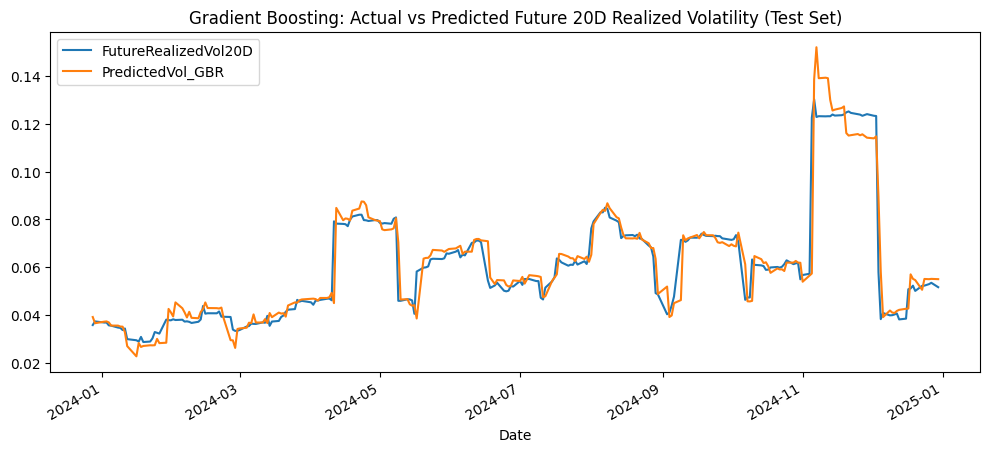

In [253]:
test_results_gbr.plot(
    x="Date",
    y=["FutureRealizedVol20D", "PredictedVol_GBR"],
    figsize=(12, 5),
    title="Gradient Boosting: Actual vs Predicted Future 20D Realized Volatility (Test Set)"
)
plt.show()

In [254]:
gbr_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": gbr_model.feature_importances_
}).sort_values("Importance", ascending=False)

gbr_importance

,Feature,Importance
12,RealizedVol_20D,0.782820
10,JPM_Vol_20D,0.175999
9,JPM_Vol_10D,0.028035
6,Corr_JPM_VIX_20D,0.002844
5,Treasury_1Y_Mom_20D,0.002793
13,VolOfVol_20D,0.002072
11,RealizedVol_5D,0.001516
7,Corr_JPM_VIX_60D,0.001338
14,Treasury_3M,0.000849
15,Treasury_6M,0.000310


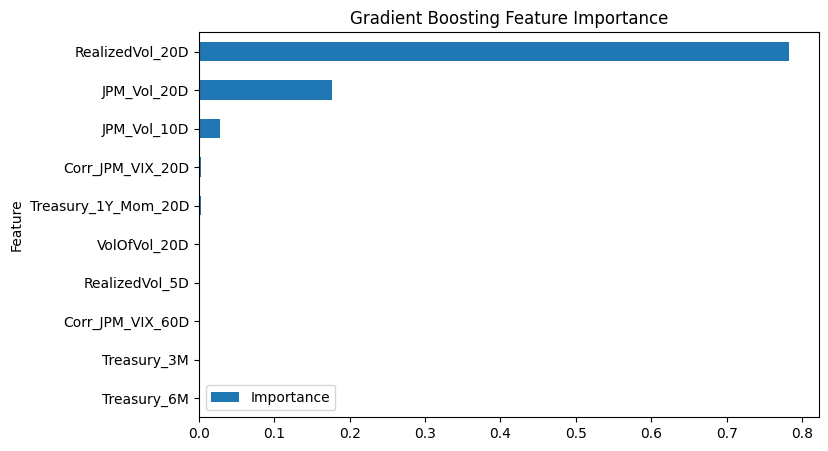

In [255]:
gbr_importance.head(10).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 5),
    title="Gradient Boosting Feature Importance"
)
plt.show()

In [256]:
gbr_results.to_csv("data/processed/ml_gradient_boosting_vol_predictions.csv", index=False)

gbr_metrics_df = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred_gbr),
        mean_absolute_error(y_val, y_val_pred_gbr),
        mean_absolute_error(y_test, y_test_pred_gbr)
    ],
    "RMSE": [
        mean_squared_error(y_train, y_train_pred_gbr, squared=False),
        mean_squared_error(y_val, y_val_pred_gbr, squared=False),
        mean_squared_error(y_test, y_test_pred_gbr, squared=False)
    ],
    "R2": [
        r2_score(y_train, y_train_pred_gbr),
        r2_score(y_val, y_val_pred_gbr),
        r2_score(y_test, y_test_pred_gbr)
    ]
})

gbr_metrics_df.to_csv("outputs/ml_gradient_boosting_metrics.csv", index=False)
gbr_metrics_df

,Set,MAE,RMSE,R2
0,Train,0.002156,0.003244,0.995766
1,Validation,0.003019,0.004707,0.945964
2,Test,0.003939,0.007481,0.902059


In [257]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "Validation_MAE": [
        mean_absolute_error(y_val, y_val_pred),
        mean_absolute_error(y_val, y_val_pred_rf),
        mean_absolute_error(y_val, y_val_pred_gbr)
    ],
    "Validation_RMSE": [
        mean_squared_error(y_val, y_val_pred, squared=False),
        mean_squared_error(y_val, y_val_pred_rf, squared=False),
        mean_squared_error(y_val, y_val_pred_gbr, squared=False)
    ],
    "Validation_R2": [
        r2_score(y_val, y_val_pred),
        r2_score(y_val, y_val_pred_rf),
        r2_score(y_val, y_val_pred_gbr)
    ],
    "Test_MAE": [
        mean_absolute_error(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_gbr)
    ],
    "Test_RMSE": [
        mean_squared_error(y_test, y_test_pred, squared=False),
        mean_squared_error(y_test, y_test_pred_rf, squared=False),
        mean_squared_error(y_test, y_test_pred_gbr, squared=False)
    ],
    "Test_R2": [
        r2_score(y_test, y_test_pred),
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_gbr)
    ]
})

model_comparison.to_csv("outputs/ml_model_comparison.csv", index=False)
model_comparison

,Model,Validation_MAE,Validation_RMSE,Validation_R2,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,0.002827,0.004657,0.947111,0.003949,0.007737,0.895263
1,Random Forest,0.002446,0.004587,0.948673,0.003238,0.007750,0.894903
2,Gradient Boosting,0.003019,0.004707,0.945964,0.003939,0.007481,0.902059


In [258]:
ml_pricing_data = gbr_results.merge(
    feature_data_ext,
    on="Date",
    how="left"
)

In [259]:
print(ml_pricing_data.shape)
print(ml_pricing_data.columns.tolist())

(1681, 33)
['Date', 'FutureRealizedVol20D', 'PredictedVol_GBR', 'Set', 'JPM_Close', 'VIX_Close', 'Treasury_1Y', 'Treasury_3M', 'Treasury_6M', 'JPM_Return', 'JPM_LogReturn', 'VIX_Return', 'Treasury_1Y_Change', 'Treasury_1Y_Mom_5D', 'Treasury_1Y_Mom_20D', 'Corr_JPM_VIX_20D', 'Corr_JPM_VIX_60D', 'RealizedVol_5D', 'RealizedVol_20D', 'JPM_Vol_20D', 'VolOfVol_20D', 'JPM_Vol_5D', 'JPM_Vol_10D', 'Sigma_Annual', 'RiskFree_1Y', 'ChooserPrice_BSM', 'BSM_Call', 'BSM_Put', 'ChooserPrice_q0', 'ChooserPrice_q2pct', 'ChooserPrice_q3pct', 'Diff_q2_minus_q0', 'Diff_q3_minus_q0']


In [260]:
if "RiskFree_1Y" not in ml_pricing_data.columns:
    ml_pricing_data["RiskFree_1Y"] = ml_pricing_data["Treasury_1Y"] / 100

In [261]:
ml_pricing_data["PredictedSigma_GBR_Annual"] = ml_pricing_data["PredictedVol_GBR"] * np.sqrt(252 / 20)

In [262]:
ml_pricing_data["BaselineSigma_Annual"] = ml_pricing_data["Sigma_Annual"]

In [263]:
K = 150
T = 1.0
tc = 0.5
q = 0.02

In [264]:
ml_pricing_data["ChooserPrice_BSM_Baseline"] = ml_pricing_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["BaselineSigma_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

In [265]:
ml_pricing_data["ChooserPrice_GBR_BSM"] = ml_pricing_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["PredictedSigma_GBR_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

In [266]:
ml_pricing_data[[
    "Date",
    "BaselineSigma_Annual",
    "PredictedSigma_GBR_Annual",
    "ChooserPrice_BSM_Baseline",
    "ChooserPrice_GBR_BSM"
]].head()

,Date,BaselineSigma_Annual,PredictedSigma_GBR_Annual,ChooserPrice_BSM_Baseline,ChooserPrice_GBR_BSM
0,2018-04-26,0.245665,0.233778,41.034349,40.690590
1,2018-04-27,0.238297,0.228747,41.414625,41.165350
2,2018-04-30,0.228379,0.216333,41.689379,41.421158
3,2018-05-01,0.222991,0.216109,41.537694,41.388987
4,2018-05-02,0.216896,0.211119,42.195598,42.086833


In [267]:
ml_pricing_data["Diff_ML_minus_BSM"] = ml_pricing_data["ChooserPrice_GBR_BSM"] - ml_pricing_data["ChooserPrice_BSM_Baseline"]

ml_pricing_data[[
    "Diff_ML_minus_BSM"
]].describe()

,Diff_ML_minus_BSM
count,1681.000000
mean,0.019858
std,1.152951
min,-16.572460
25%,-0.237726
50%,-0.003257
75%,0.258983
max,14.900593


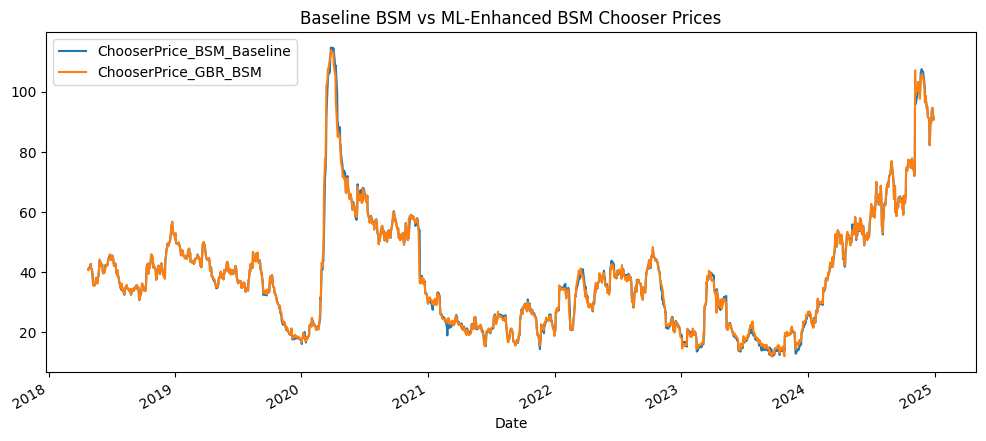

In [268]:
ml_pricing_data.plot(
    x="Date",
    y=["ChooserPrice_BSM_Baseline", "ChooserPrice_GBR_BSM"],
    figsize=(12, 5),
    title="Baseline BSM vs ML-Enhanced BSM Chooser Prices"
)
plt.show()

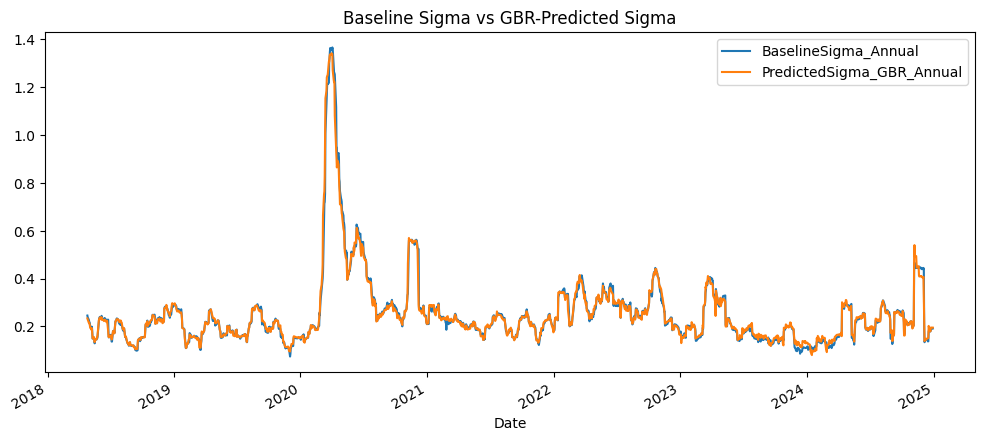

In [269]:
ml_pricing_data.plot(
    x="Date",
    y=["BaselineSigma_Annual", "PredictedSigma_GBR_Annual"],
    figsize=(12, 5),
    title="Baseline Sigma vs GBR-Predicted Sigma"
)
plt.show()

In [270]:
ml_pricing_data.to_csv("data/processed/ml_enhanced_bsm_chooser_prices.csv", index=False)

In [271]:
ml_pricing_data[[
    "BaselineSigma_Annual",
    "PredictedSigma_GBR_Annual",
    "ChooserPrice_BSM_Baseline",
    "ChooserPrice_GBR_BSM",
    "Diff_ML_minus_BSM"
]].describe().to_csv("outputs/ml_enhanced_bsm_summary.csv")

In [272]:
comparison_summary = ml_pricing_data[[
    "BaselineSigma_Annual",
    "PredictedSigma_GBR_Annual",
    "ChooserPrice_BSM_Baseline",
    "ChooserPrice_GBR_BSM",
    "Diff_ML_minus_BSM"
]].describe()

comparison_summary

,BaselineSigma_Annual,PredictedSigma_GBR_Annual,ChooserPrice_BSM_Baseline,ChooserPrice_GBR_BSM,Diff_ML_minus_BSM
count,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000
mean,0.253290,0.253551,38.652544,38.672402,0.019858
std,0.158934,0.156410,19.419986,19.294027,1.152951
min,0.074378,0.080304,12.004254,12.073182,-16.572460
25%,0.168490,0.168204,22.959293,23.285427,-0.237726
50%,0.218794,0.220560,35.745650,35.872399,-0.003257
75%,0.277645,0.271755,47.262007,47.154502,0.258983
max,1.366689,1.342361,114.647080,113.706536,14.900593


In [273]:
comparison_df = pd.read_csv("data/processed/multi_date_bsm_vs_market_comparison_extended.csv")
comparison_df.columns.tolist()

['Date',
 'ContractType',
 'Strike',
 'Expiration',
 'S',
 'r',
 'sigma',
 'q',
 'T',
 'BSM_Price',
 'Actual_Mark',
 'Error',
 'AbsError',
 'PctError',
 'Moneyness',
 'MoneynessGroup']

In [274]:
comparison_df.head()

,Date,ContractType,Strike,Expiration,S,r,sigma,q,T,BSM_Price,Actual_Mark,Error,AbsError,PctError,Moneyness,MoneynessGroup
0,2018-06-29,Call,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,0.059933,0.33,-0.270067,0.270067,-0.818386,0.694667,OTM
1,2018-06-29,Put,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,44.498709,45.35,-0.851291,0.851291,-0.018772,0.694667,OTM
2,2018-12-31,Call,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,1.126511,0.16,0.966511,0.966511,6.040695,0.650800,OTM
3,2018-12-31,Put,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,51.456172,53.15,-1.693828,1.693828,-0.031869,0.650800,OTM
4,2019-06-28,Call,150,2020-06-19,111.80,0.0192,0.180444,0.02,0.978082,0.464887,0.33,0.134887,0.134887,0.408748,0.745333,OTM


In [275]:
pricing_ml_data = comparison_df.copy()

pricing_ml_data["Date"] = pd.to_datetime(pricing_ml_data["Date"])
pricing_ml_data["Expiration"] = pd.to_datetime(pricing_ml_data["Expiration"])

In [276]:
pricing_ml_data["IsCall"] = (pricing_ml_data["ContractType"] == "Call").astype(int)

In [277]:
pricing_feature_cols = [
    "S",
    "r",
    "sigma",
    "q",
    "T",
    "Strike",
    "Moneyness",
    "IsCall"
]

X_price = pricing_ml_data[pricing_feature_cols]
y_price = pricing_ml_data["Actual_Mark"]

In [278]:
pricing_ml_data[["Date", "ContractType", "Actual_Mark"] + pricing_feature_cols].head()

,Date,ContractType,Actual_Mark,S,r,sigma,q,T,Strike,Moneyness,IsCall
0,2018-06-29,Call,0.33,104.20,0.0233,0.155584,0.02,0.978082,150,0.694667,1
1,2018-06-29,Put,45.35,104.20,0.0233,0.155584,0.02,0.978082,150,0.694667,0
2,2018-12-31,Call,0.16,97.62,0.0263,0.285406,0.02,1.046575,150,0.650800,1
3,2018-12-31,Put,53.15,97.62,0.0263,0.285406,0.02,1.046575,150,0.650800,0
4,2019-06-28,Call,0.33,111.80,0.0192,0.180444,0.02,0.978082,150,0.745333,1


In [279]:
n_price = len(pricing_ml_data)
train_end_price = int(n_price * 0.70)
val_end_price = int(n_price * 0.85)

train_price = pricing_ml_data.iloc[:train_end_price].copy()
val_price = pricing_ml_data.iloc[train_end_price:val_end_price].copy()
test_price = pricing_ml_data.iloc[val_end_price:].copy()

print("train:", train_price.shape)
print("val:", val_price.shape)
print("test:", test_price.shape)

print("Train:", train_price["Date"].min(), "to", train_price["Date"].max())
print("Val:", val_price["Date"].min(), "to", val_price["Date"].max())
print("Test:", test_price["Date"].min(), "to", test_price["Date"].max())

train: (16, 17)
val: (4, 17)
test: (4, 17)
Train: 2018-06-29 00:00:00 to 2021-12-31 00:00:00
Val: 2022-06-30 00:00:00 to 2022-12-30 00:00:00
Test: 2023-12-29 00:00:00 to 2024-12-31 00:00:00


In [280]:
X_train_price = train_price[pricing_feature_cols]
y_train_price = train_price["Actual_Mark"]

X_val_price = val_price[pricing_feature_cols]
y_val_price = val_price["Actual_Mark"]

X_test_price = test_price[pricing_feature_cols]
y_test_price = test_price["Actual_Mark"]

In [281]:
price_scaler = StandardScaler()

X_train_price_scaled = price_scaler.fit_transform(X_train_price)
X_val_price_scaled = price_scaler.transform(X_val_price)
X_test_price_scaled = price_scaler.transform(X_test_price)

In [282]:
price_lr_model = LinearRegression()
price_lr_model.fit(X_train_price_scaled, y_train_price)

LinearRegression()

In [283]:
y_train_price_pred = price_lr_model.predict(X_train_price_scaled)
y_val_price_pred = price_lr_model.predict(X_val_price_scaled)
y_test_price_pred = price_lr_model.predict(X_test_price_scaled)

In [284]:
regression_metrics(y_train_price, y_train_price_pred, "Price LR Train")
print()
regression_metrics(y_val_price, y_val_price_pred, "Price LR Validation")
print()
regression_metrics(y_test_price, y_test_price_pred, "Price LR Test")

Price LR Train MAE:  11.810469
Price LR Train RMSE: 12.897245
Price LR Train R2:   0.657350

Price LR Validation MAE:  7.086660
Price LR Validation RMSE: 9.092396
Price LR Validation R2:   0.598556

Price LR Test MAE:  50.205548
Price LR Test RMSE: 72.221174
Price LR Test R2:   -2.871678


In [285]:
price_gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

price_gbr_model.fit(X_train_price, y_train_price)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [286]:
y_train_price_pred_gbr = price_gbr_model.predict(X_train_price)
y_val_price_pred_gbr = price_gbr_model.predict(X_val_price)
y_test_price_pred_gbr = price_gbr_model.predict(X_test_price)

In [287]:
regression_metrics(y_train_price, y_train_price_pred_gbr, "Price GBR Train")
print()
regression_metrics(y_val_price, y_val_price_pred_gbr, "Price GBR Validation")
print()
regression_metrics(y_test_price, y_test_price_pred_gbr, "Price GBR Test")

Price GBR Train MAE:  0.000990
Price GBR Train RMSE: 0.001279
Price GBR Train R2:   1.000000

Price GBR Validation MAE:  3.301030
Price GBR Validation RMSE: 4.102471
Price GBR Validation R2:   0.918274

Price GBR Test MAE:  28.378528
Price GBR Test RMSE: 39.328586
Price GBR Test R2:   -0.148119


In [288]:
price_model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting"],
    "Validation_MAE": [
        mean_absolute_error(y_val_price, y_val_price_pred),
        mean_absolute_error(y_val_price, y_val_price_pred_gbr)
    ],
    "Validation_RMSE": [
        mean_squared_error(y_val_price, y_val_price_pred, squared=False),
        mean_squared_error(y_val_price, y_val_price_pred_gbr, squared=False)
    ],
    "Validation_R2": [
        r2_score(y_val_price, y_val_price_pred),
        r2_score(y_val_price, y_val_price_pred_gbr)
    ],
    "Test_MAE": [
        mean_absolute_error(y_test_price, y_test_price_pred),
        mean_absolute_error(y_test_price, y_test_price_pred_gbr)
    ],
    "Test_RMSE": [
        mean_squared_error(y_test_price, y_test_price_pred, squared=False),
        mean_squared_error(y_test_price, y_test_price_pred_gbr, squared=False)
    ],
    "Test_R2": [
        r2_score(y_test_price, y_test_price_pred),
        r2_score(y_test_price, y_test_price_pred_gbr)
    ]
})

price_model_comparison

,Model,Validation_MAE,Validation_RMSE,Validation_R2,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,7.08666,9.092396,0.598556,50.205548,72.221174,-2.871678
1,Gradient Boosting,3.30103,4.102471,0.918274,28.378528,39.328586,-0.148119


In [289]:
train_price_results = train_price[["Date", "ContractType", "Actual_Mark"]].copy()
train_price_results["PredictedPrice_LR"] = y_train_price_pred
train_price_results["PredictedPrice_GBR"] = y_train_price_pred_gbr
train_price_results["Set"] = "Train"

val_price_results = val_price[["Date", "ContractType", "Actual_Mark"]].copy()
val_price_results["PredictedPrice_LR"] = y_val_price_pred
val_price_results["PredictedPrice_GBR"] = y_val_price_pred_gbr
val_price_results["Set"] = "Validation"

test_price_results = test_price[["Date", "ContractType", "Actual_Mark"]].copy()
test_price_results["PredictedPrice_LR"] = y_test_price_pred
test_price_results["PredictedPrice_GBR"] = y_test_price_pred_gbr
test_price_results["Set"] = "Test"

pricing_results = pd.concat(
    [train_price_results, val_price_results, test_price_results],
    axis=0
).reset_index(drop=True)

pricing_results.to_csv("data/processed/ml_direct_pricing_predictions.csv", index=False)
price_model_comparison.to_csv("outputs/ml_direct_pricing_model_comparison.csv", index=False)

In [290]:
ml_pricing_data.sort_values("Diff_ML_minus_BSM", ascending=False)[[
    "Date",
    "BaselineSigma_Annual",
    "PredictedSigma_GBR_Annual",
    "ChooserPrice_BSM_Baseline",
    "ChooserPrice_GBR_BSM",
    "Diff_ML_minus_BSM"
]].head(10)

,Date,BaselineSigma_Annual,PredictedSigma_GBR_Annual,ChooserPrice_BSM_Baseline,ChooserPrice_GBR_BSM,Diff_ML_minus_BSM
468,2020-03-06,0.426606,0.664718,52.622583,67.523176,14.900593
472,2020-03-12,0.755385,0.995315,79.725217,92.769256,13.044039
473,2020-03-13,1.007595,1.153866,91.853728,101.904561,10.050833
471,2020-03-11,0.720287,0.827344,74.774673,81.132353,6.357680
469,2020-03-09,0.635452,0.752804,71.304079,77.616959,6.312880
639,2020-11-06,0.335725,0.463944,52.380523,57.790654,5.410131
1645,2024-11-07,0.467078,0.540224,96.663510,101.468198,4.804688
479,2020-03-23,1.218763,1.307840,106.492183,111.111616,4.619434
475,2020-03-17,1.170728,1.241225,102.784242,107.144399,4.360157
713,2021-02-25,0.186306,0.228398,19.022990,23.285427,4.262437


In [291]:
ml_pricing_data.sort_values("Diff_ML_minus_BSM", ascending=True)[[
    "Date",
    "BaselineSigma_Annual",
    "PredictedSigma_GBR_Annual",
    "ChooserPrice_BSM_Baseline",
    "ChooserPrice_GBR_BSM",
    "Diff_ML_minus_BSM"
]].head(10)

,Date,BaselineSigma_Annual,PredictedSigma_GBR_Annual,ChooserPrice_BSM_Baseline,ChooserPrice_GBR_BSM,Diff_ML_minus_BSM
659,2020-12-07,0.523665,0.291298,54.004762,37.432303,-16.572460
492,2020-04-09,1.253345,1.082404,108.662107,97.108686,-11.553421
493,2020-04-13,1.117235,0.945044,99.392893,88.231729,-11.161164
957,2022-02-11,0.336168,0.269635,34.319075,27.586887,-6.732188
488,2020-04-03,1.362508,1.271082,114.042576,108.987969,-5.054607
1663,2024-12-04,0.442655,0.317719,101.157297,96.343193,-4.814103
495,2020-04-15,0.947951,0.864960,89.719853,84.931829,-4.788024
499,2020-04-21,0.907721,0.832397,87.834218,83.665180,-4.169038
489,2020-04-06,1.291406,1.230107,110.120317,106.507932,-3.612385
511,2020-05-07,0.614209,0.539572,71.586307,68.292585,-3.293722


In [292]:
temp = ml_pricing_data.copy()
temp["Year"] = pd.to_datetime(temp["Date"]).dt.year
temp.groupby("Year")["Diff_ML_minus_BSM"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
Year,,,,
2018,-0.004301,0.128723,-0.603718,0.364200
2019,0.055231,0.237661,-0.733404,1.143985
2020,-0.172093,2.417367,-16.572460,14.900593
2021,-0.005387,0.684823,-2.066733,4.262437
2022,-0.082227,0.933399,-6.732188,3.298468
2023,0.325865,0.978417,-3.166282,2.631541
2024,0.017022,0.731544,-4.814103,4.804688


In [293]:
gbr_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": gbr_model.feature_importances_
}).sort_values("Importance", ascending=False)

gbr_importance

,Feature,Importance
12,RealizedVol_20D,0.782820
10,JPM_Vol_20D,0.175999
9,JPM_Vol_10D,0.028035
6,Corr_JPM_VIX_20D,0.002844
5,Treasury_1Y_Mom_20D,0.002793
13,VolOfVol_20D,0.002072
11,RealizedVol_5D,0.001516
7,Corr_JPM_VIX_60D,0.001338
14,Treasury_3M,0.000849
15,Treasury_6M,0.000310


In [294]:
rf_imp = rf_importance.rename(columns={"Importance": "RF_Importance"})
gbr_imp = gbr_importance.rename(columns={"Importance": "GBR_Importance"})

importance_compare = rf_imp.merge(gbr_imp, on="Feature", how="outer")
importance_compare

,Feature,RF_Importance,GBR_Importance
0,RealizedVol_20D,0.714078,0.782820
1,JPM_Vol_20D,0.239513,0.175999
2,JPM_Vol_10D,0.035604,0.028035
3,Corr_JPM_VIX_20D,0.005127,0.002844
4,VolOfVol_20D,0.001514,0.002072
5,Treasury_1Y_Mom_20D,0.001182,0.002793
6,Treasury_3M,0.000673,0.000849
7,Treasury_1Y,0.000650,0.000275
8,Corr_JPM_VIX_60D,0.000336,0.001338
9,Treasury_6M,0.000327,0.000310


In [295]:
importance_compare.sort_values("GBR_Importance", ascending=False)

,Feature,RF_Importance,GBR_Importance
0,RealizedVol_20D,0.714078,0.782820
1,JPM_Vol_20D,0.239513,0.175999
2,JPM_Vol_10D,0.035604,0.028035
3,Corr_JPM_VIX_20D,0.005127,0.002844
5,Treasury_1Y_Mom_20D,0.001182,0.002793
4,VolOfVol_20D,0.001514,0.002072
10,RealizedVol_5D,0.000250,0.001516
8,Corr_JPM_VIX_60D,0.000336,0.001338
6,Treasury_3M,0.000673,0.000849
9,Treasury_6M,0.000327,0.000310


In [296]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [297]:
rf_param_grid = [
    {"n_estimators": 100, "max_depth": 4, "min_samples_leaf": 3},
    {"n_estimators": 100, "max_depth": 6, "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 4, "min_samples_leaf": 3},
    {"n_estimators": 200, "max_depth": 6, "min_samples_leaf": 5},
    {"n_estimators": 300, "max_depth": 6, "min_samples_leaf": 5},
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 3}
]

In [298]:
rf_tuning_results = []

for params in rf_param_grid:
    model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    y_val_pred_temp = model.predict(X_val)
    y_test_pred_temp = model.predict(X_test)
    
    rf_tuning_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "Val_MAE": mean_absolute_error(y_val, y_val_pred_temp),
        "Val_RMSE": mean_squared_error(y_val, y_val_pred_temp, squared=False),
        "Val_R2": r2_score(y_val, y_val_pred_temp),
        "Test_MAE": mean_absolute_error(y_test, y_test_pred_temp),
        "Test_RMSE": mean_squared_error(y_test, y_test_pred_temp, squared=False),
        "Test_R2": r2_score(y_test, y_test_pred_temp)
    })

rf_tuning_results_df = pd.DataFrame(rf_tuning_results).sort_values("Val_RMSE")
rf_tuning_results_df

,n_estimators,max_depth,min_samples_leaf,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
5,300,8,3,0.002486,0.004573,0.949001,0.003240,0.007784,0.893971
4,300,6,5,0.002434,0.004584,0.948740,0.003281,0.007773,0.894285
3,200,6,5,0.002446,0.004587,0.948673,0.003238,0.007750,0.894903
1,100,6,5,0.002440,0.004588,0.948660,0.003212,0.007755,0.894752
2,200,4,3,0.002904,0.004967,0.939834,0.004426,0.008243,0.881110
0,100,4,3,0.002923,0.004997,0.939105,0.004499,0.008287,0.879825


In [299]:
rf_tuning_results_df.to_csv("outputs/rf_tuning_results.csv", index=False)

In [300]:
gbr_param_grid = [
    {"n_estimators": 100, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 200, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 2},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3}
]

In [301]:
gbr_tuning_results = []

for params in gbr_param_grid:
    model = GradientBoostingRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_val_pred_temp = model.predict(X_val)
    y_test_pred_temp = model.predict(X_test)
    
    gbr_tuning_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "Val_MAE": mean_absolute_error(y_val, y_val_pred_temp),
        "Val_RMSE": mean_squared_error(y_val, y_val_pred_temp, squared=False),
        "Val_R2": r2_score(y_val, y_val_pred_temp),
        "Test_MAE": mean_absolute_error(y_test, y_test_pred_temp),
        "Test_RMSE": mean_squared_error(y_test, y_test_pred_temp, squared=False),
        "Test_R2": r2_score(y_test, y_test_pred_temp)
    })

gbr_tuning_results_df = pd.DataFrame(gbr_tuning_results).sort_values("Val_RMSE")
gbr_tuning_results_df

,n_estimators,learning_rate,max_depth,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
2,200,0.03,2,0.002397,0.004394,0.952916,0.003152,0.007206,0.909136
4,300,0.03,2,0.002442,0.004403,0.952727,0.003196,0.007038,0.913330
1,100,0.05,3,0.002489,0.004436,0.952015,0.003454,0.007376,0.904809
3,200,0.05,3,0.003019,0.004707,0.945964,0.003939,0.007481,0.902059
5,300,0.05,3,0.003727,0.005198,0.934111,0.004447,0.007616,0.898494
0,100,0.03,2,0.004181,0.005575,0.924208,0.004519,0.008178,0.882956


In [302]:
gbr_tuning_results_df.to_csv("outputs/gbr_tuning_results.csv", index=False)

In [303]:
best_rf_params = rf_tuning_results_df.iloc[0].to_dict()
best_rf_params

{'n_estimators': 300.0,
 'max_depth': 8.0,
 'min_samples_leaf': 3.0,
 'Val_MAE': 0.0024862781237698192,
 'Val_RMSE': 0.0045727990823567705,
 'Val_R2': 0.9490006621058176,
 'Test_MAE': 0.0032398728443743382,
 'Test_RMSE': 0.007784142184651767,
 'Test_R2': 0.8939712075233599}

In [304]:
best_gbr_params = gbr_tuning_results_df.iloc[0].to_dict()
best_gbr_params

{'n_estimators': 200.0,
 'learning_rate': 0.03,
 'max_depth': 2.0,
 'Val_MAE': 0.0023966030186864684,
 'Val_RMSE': 0.00439378292385205,
 'Val_R2': 0.952915551134918,
 'Test_MAE': 0.003151852243675087,
 'Test_RMSE': 0.0072060057062932744,
 'Test_R2': 0.9091360738116455}

In [305]:
tuned_model_comparison = pd.DataFrame({
    "Model": ["Best Random Forest", "Best Gradient Boosting"],
    "Validation_MAE": [
        rf_tuning_results_df.iloc[0]["Val_MAE"],
        gbr_tuning_results_df.iloc[0]["Val_MAE"]
    ],
    "Validation_RMSE": [
        rf_tuning_results_df.iloc[0]["Val_RMSE"],
        gbr_tuning_results_df.iloc[0]["Val_RMSE"]
    ],
    "Validation_R2": [
        rf_tuning_results_df.iloc[0]["Val_R2"],
        gbr_tuning_results_df.iloc[0]["Val_R2"]
    ],
    "Test_MAE": [
        rf_tuning_results_df.iloc[0]["Test_MAE"],
        gbr_tuning_results_df.iloc[0]["Test_MAE"]
    ],
    "Test_RMSE": [
        rf_tuning_results_df.iloc[0]["Test_RMSE"],
        gbr_tuning_results_df.iloc[0]["Test_RMSE"]
    ],
    "Test_R2": [
        rf_tuning_results_df.iloc[0]["Test_R2"],
        gbr_tuning_results_df.iloc[0]["Test_R2"]
    ]
})

tuned_model_comparison

,Model,Validation_MAE,Validation_RMSE,Validation_R2,Test_MAE,Test_RMSE,Test_R2
0,Best Random Forest,0.002486,0.004573,0.949001,0.003240,0.007784,0.893971
1,Best Gradient Boosting,0.002397,0.004394,0.952916,0.003152,0.007206,0.909136


In [306]:
tuned_model_comparison.to_csv("outputs/tuned_vol_model_comparison.csv", index=False)

In [307]:
final_gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,
    random_state=42
)

final_gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.03, max_depth=2, n_estimators=200,
                          random_state=42)

In [308]:
X_all = ml_vol_data[feature_cols]
y_all = ml_vol_data["FutureRealizedVol20D"]

y_all_pred_final_gbr = final_gbr_model.predict(X_all)

In [309]:
final_gbr_results = ml_vol_data[["Date", "FutureRealizedVol20D"]].copy()
final_gbr_results["PredictedVol_GBR_Final"] = y_all_pred_final_gbr
final_gbr_results.head()

,Date,FutureRealizedVol20D,PredictedVol_GBR_Final
0,2018-04-26,0.065443,0.066608
1,2018-04-27,0.062739,0.065044
2,2018-04-30,0.061240,0.062005
3,2018-05-01,0.059886,0.061828
4,2018-05-02,0.059686,0.059926


In [310]:
final_ml_pricing_data = final_gbr_results.merge(
    feature_data_ext,
    on="Date",
    how="left"
)

In [311]:
if "RiskFree_1Y" not in final_ml_pricing_data.columns:
    final_ml_pricing_data["RiskFree_1Y"] = final_ml_pricing_data["Treasury_1Y"] / 100

In [312]:
final_ml_pricing_data["FinalPredictedSigma_Annual"] = final_ml_pricing_data["PredictedVol_GBR_Final"] * np.sqrt(252 / 20)
final_ml_pricing_data["BaselineSigma_Annual"] = final_ml_pricing_data["Sigma_Annual"]

In [313]:
K = 150
T = 1.0
tc = 0.5
q = 0.02

In [314]:
final_ml_pricing_data["ChooserPrice_BSM_Baseline"] = final_ml_pricing_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["BaselineSigma_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

final_ml_pricing_data["ChooserPrice_GBR_Final"] = final_ml_pricing_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["FinalPredictedSigma_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

In [315]:
final_ml_pricing_data["Diff_FinalML_minus_BSM"] = (
    final_ml_pricing_data["ChooserPrice_GBR_Final"] - final_ml_pricing_data["ChooserPrice_BSM_Baseline"]
)

final_ml_pricing_data[[
    "Date",
    "BaselineSigma_Annual",
    "FinalPredictedSigma_Annual",
    "ChooserPrice_BSM_Baseline",
    "ChooserPrice_GBR_Final",
    "Diff_FinalML_minus_BSM"
]].head()

,Date,BaselineSigma_Annual,FinalPredictedSigma_Annual,ChooserPrice_BSM_Baseline,ChooserPrice_GBR_Final,Diff_FinalML_minus_BSM
0,2018-04-26,0.245665,0.236435,41.034349,40.764418,-0.269931
1,2018-04-27,0.238297,0.230882,41.414625,41.219132,-0.195493
2,2018-04-30,0.228379,0.220097,41.689379,41.501125,-0.188254
3,2018-05-01,0.222991,0.219467,41.537694,41.460072,-0.077622
4,2018-05-02,0.216896,0.212718,42.195598,42.116126,-0.079472


In [316]:
final_gbr_results.to_csv("data/processed/final_gbr_vol_predictions.csv", index=False)
final_ml_pricing_data.to_csv("data/processed/final_ml_enhanced_bsm_prices.csv", index=False)

In [317]:
benchmark_final = comparison_df.copy()
benchmark_final["Date"] = pd.to_datetime(benchmark_final["Date"])
final_ml_pricing_data["Date"] = pd.to_datetime(final_ml_pricing_data["Date"])

benchmark_final = benchmark_final.merge(
    final_ml_pricing_data[["Date", "FinalPredictedSigma_Annual"]],
    on="Date",
    how="left"
)

benchmark_final.head()

,Date,ContractType,Strike,Expiration,S,r,sigma,q,T,BSM_Price,Actual_Mark,Error,AbsError,PctError,Moneyness,MoneynessGroup,FinalPredictedSigma_Annual
0,2018-06-29,Call,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,0.059933,0.33,-0.270067,0.270067,-0.818386,0.694667,OTM,0.157713
1,2018-06-29,Put,150,2019-06-21,104.20,0.0233,0.155584,0.02,0.978082,44.498709,45.35,-0.851291,0.851291,-0.018772,0.694667,OTM,0.157713
2,2018-12-31,Call,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,1.126511,0.16,0.966511,0.966511,6.040695,0.650800,OTM,0.292940
3,2018-12-31,Put,150,2020-01-17,97.62,0.0263,0.285406,0.02,1.046575,51.456172,53.15,-1.693828,1.693828,-0.031869,0.650800,OTM,0.292940
4,2019-06-28,Call,150,2020-06-19,111.80,0.0192,0.180444,0.02,0.978082,0.464887,0.33,0.134887,0.134887,0.408748,0.745333,OTM,0.186693


In [318]:
benchmark_final = benchmark_final.rename(columns={"BSM_Price": "BSM_Price_Baseline"})

In [319]:
def price_option_row(row):
    if row["ContractType"] == "Call":
        return bs_call_price(
            S=row["S"],
            K=row["Strike"],
            r=row["r"],
            q=row["q"],
            sigma=row["FinalPredictedSigma_Annual"],
            T=row["T"]
        )
    else:
        return bs_put_price(
            S=row["S"],
            K=row["Strike"],
            r=row["r"],
            q=row["q"],
            sigma=row["FinalPredictedSigma_Annual"],
            T=row["T"]
        )

benchmark_final["BSM_Price_GBR_Final"] = benchmark_final.apply(price_option_row, axis=1)

In [320]:
benchmark_final["Error_Baseline"] = benchmark_final["BSM_Price_Baseline"] - benchmark_final["Actual_Mark"]
benchmark_final["AbsError_Baseline"] = benchmark_final["Error_Baseline"].abs()

benchmark_final["Error_GBR_Final"] = benchmark_final["BSM_Price_GBR_Final"] - benchmark_final["Actual_Mark"]
benchmark_final["AbsError_GBR_Final"] = benchmark_final["Error_GBR_Final"].abs()

In [321]:
benchmark_comparison_summary = pd.DataFrame({
    "Model": ["Baseline BSM", "GBR-Enhanced BSM"],
    "MAE": [
        benchmark_final["AbsError_Baseline"].mean(),
        benchmark_final["AbsError_GBR_Final"].mean()
    ],
    "RMSE": [
        np.sqrt((benchmark_final["Error_Baseline"]**2).mean()),
        np.sqrt((benchmark_final["Error_GBR_Final"]**2).mean())
    ]
})

benchmark_comparison_summary

,Model,MAE,RMSE
0,Baseline BSM,4.587644,7.334773
1,GBR-Enhanced BSM,4.934644,8.290735


In [322]:
by_type_summary = benchmark_final.groupby("ContractType").agg(
    Baseline_MAE=("AbsError_Baseline", "mean"),
    Baseline_RMSE=("Error_Baseline", lambda x: np.sqrt((x**2).mean())),
    GBR_MAE=("AbsError_GBR_Final", "mean"),
    GBR_RMSE=("Error_GBR_Final", lambda x: np.sqrt((x**2).mean()))
).reset_index()

by_type_summary

,ContractType,Baseline_MAE,Baseline_RMSE,GBR_MAE,GBR_RMSE
0,Call,4.428790,7.310743,4.757686,8.260585
1,Put,4.746498,7.358725,5.111602,8.320775


In [323]:
by_moneyness_summary = benchmark_final.groupby("MoneynessGroup").agg(
    Baseline_MAE=("AbsError_Baseline", "mean"),
    Baseline_RMSE=("Error_Baseline", lambda x: np.sqrt((x**2).mean())),
    GBR_MAE=("AbsError_GBR_Final", "mean"),
    GBR_RMSE=("Error_GBR_Final", lambda x: np.sqrt((x**2).mean()))
).reset_index()

by_moneyness_summary

,MoneynessGroup,Baseline_MAE,Baseline_RMSE,GBR_MAE,GBR_RMSE
0,ITM,3.861743,4.253887,5.089404,5.092073
1,Near-ATM,3.513370,3.734517,3.465341,3.752566
2,OTM,5.255447,9.004410,5.542237,9.913372


In [324]:
benchmark_final["AbsError_Improvement"] = (
    benchmark_final["AbsError_Baseline"] - benchmark_final["AbsError_GBR_Final"]
)

benchmark_final[[
    "Date",
    "ContractType",
    "Actual_Mark",
    "BSM_Price_Baseline",
    "BSM_Price_GBR_Final",
    "AbsError_Baseline",
    "AbsError_GBR_Final",
    "AbsError_Improvement"
]].head()

,Date,ContractType,Actual_Mark,BSM_Price_Baseline,BSM_Price_GBR_Final,AbsError_Baseline,AbsError_GBR_Final,AbsError_Improvement
0,2018-06-29,Call,0.33,0.059933,0.066712,0.270067,0.263288,0.006780
1,2018-06-29,Put,45.35,44.498709,44.505488,0.851291,0.844512,0.006780
2,2018-12-31,Call,0.16,1.126511,1.255762,0.966511,1.095762,-0.129251
3,2018-12-31,Put,53.15,51.456172,51.585423,1.693828,1.564577,0.129251
4,2019-06-28,Call,0.33,0.464887,0.548404,0.134887,0.218404,-0.083517


In [325]:
benchmark_final["AbsError_Improvement"].describe()

count    22.000000
mean     -0.121652
std       0.871515
min      -2.646576
25%      -0.181597
50%       0.045148
75%       0.193058
max       0.813867
Name: AbsError_Improvement, dtype: float64

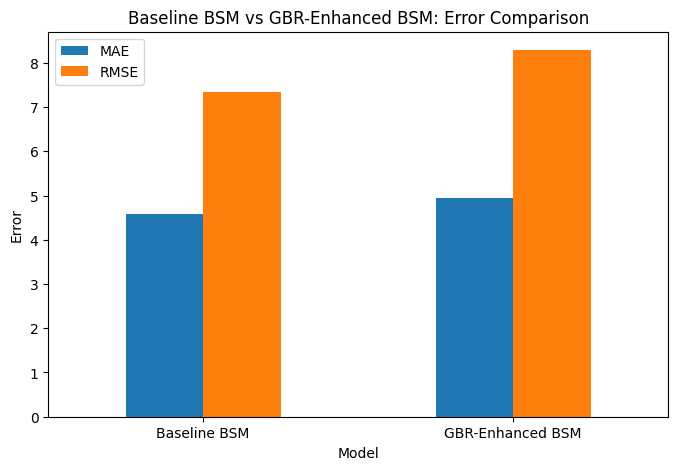

In [326]:
benchmark_comparison_summary.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5),
    title="Baseline BSM vs GBR-Enhanced BSM: Error Comparison"
)
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

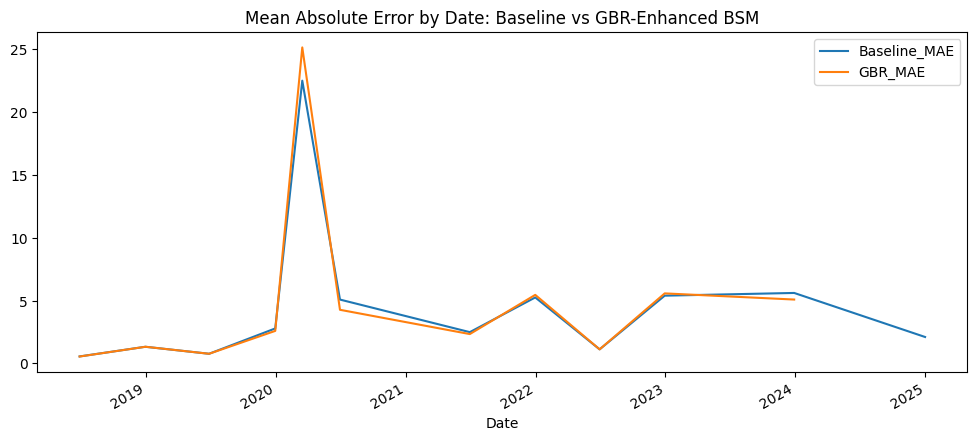

In [327]:
by_date_summary = benchmark_final.groupby("Date").agg(
    Baseline_MAE=("AbsError_Baseline", "mean"),
    GBR_MAE=("AbsError_GBR_Final", "mean")
).reset_index()

by_date_summary.plot(
    x="Date",
    y=["Baseline_MAE", "GBR_MAE"],
    figsize=(12, 5),
    title="Mean Absolute Error by Date: Baseline vs GBR-Enhanced BSM"
)
plt.show()

In [328]:
benchmark_final.to_csv("data/processed/final_benchmark_comparison_with_ml.csv", index=False)
benchmark_comparison_summary.to_csv("outputs/final_benchmark_error_summary.csv", index=False)
by_type_summary.to_csv("outputs/final_benchmark_error_by_type.csv", index=False)
by_moneyness_summary.to_csv("outputs/final_benchmark_error_by_moneyness.csv", index=False)

In [329]:
import shap

In [330]:
explainer = shap.Explainer(final_gbr_model, X_train)
shap_values = explainer(X_test)

In [331]:
X_test_small = X_test.iloc[:100].copy()
explainer = shap.Explainer(final_gbr_model, X_train)
shap_values = explainer(X_test_small)

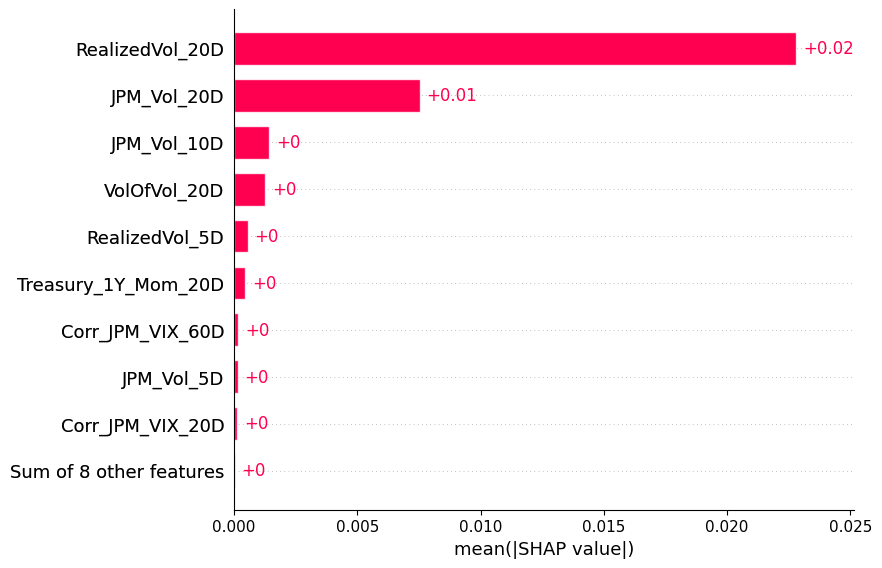

In [332]:
shap.plots.bar(shap_values, max_display=10)

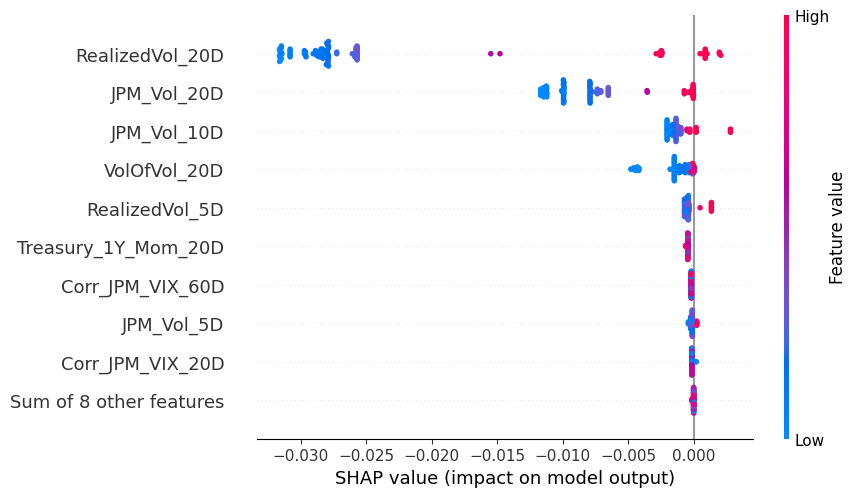

In [333]:
shap.plots.beeswarm(shap_values, max_display=10)

In [334]:
test_shap_df = X_test.copy()
test_shap_df["PredictedVol"] = final_gbr_model.predict(X_test)

test_shap_df_sorted = test_shap_df.sort_values("PredictedVol", ascending=False)
test_shap_df_sorted.head()

,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,Treasury_1Y_Mom_5D,Treasury_1Y_Mom_20D,Corr_JPM_VIX_20D,Corr_JPM_VIX_60D,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D,RealizedVol_5D,RealizedVol_20D,VolOfVol_20D,Treasury_3M,Treasury_6M,Treasury_1Y,PredictedVol
1645,-0.043228,-0.044191,-0.065765,-0.03,0.002342,0.014218,-0.585724,-0.439827,0.057830,0.040249,0.029423,0.119055,0.130380,0.004620,4.63,4.40,4.28,0.138843
1648,0.001128,0.001128,-0.017368,0.06,0.025761,0.047847,-0.622169,-0.436455,0.056482,0.039337,0.028010,0.118284,0.123221,0.006600,4.63,4.45,4.38,0.125182
1647,0.009748,0.009700,0.002008,0.00,0.016471,0.033493,-0.609668,-0.437174,0.056132,0.039759,0.028004,0.118532,0.123284,0.006104,4.63,4.42,4.32,0.125182
1644,0.115445,0.109254,-0.205954,0.04,0.007009,0.016509,-0.725577,-0.498280,0.051226,0.036374,0.027128,0.111112,0.122693,0.003186,4.64,4.41,4.31,0.125182
1646,0.002538,0.002535,-0.017105,0.04,0.009346,0.033493,-0.605537,-0.439255,0.057908,0.039833,0.028016,0.118994,0.122956,0.005465,4.63,4.42,4.32,0.125182


In [335]:
top_idx = test_shap_df_sorted.index[0]
row_position = list(X_test.index).index(top_idx)

In [337]:
test_shap_df_small = X_test.iloc[:100].copy()
test_shap_df_small["PredictedVol"] = final_gbr_model.predict(X_test.iloc[:100])

test_shap_df_small.sort_values("PredictedVol", ascending=False).head()

,JPM_Return,JPM_LogReturn,VIX_Return,Treasury_1Y_Change,Treasury_1Y_Mom_5D,Treasury_1Y_Mom_20D,Corr_JPM_VIX_20D,Corr_JPM_VIX_60D,JPM_Vol_5D,JPM_Vol_10D,JPM_Vol_20D,RealizedVol_5D,RealizedVol_20D,VolOfVol_20D,Treasury_3M,Treasury_6M,Treasury_1Y,PredictedVol
1508,0.004892,0.004880,0.017846,0.03,0.001938,0.034000,-0.622414,-0.538235,0.008424,0.025516,0.018797,0.035434,0.081992,0.004053,5.46,5.40,5.17,0.084438
1507,0.014413,0.014310,-0.073790,-0.02,-0.007722,0.028000,-0.625554,-0.538655,0.011264,0.025512,0.018794,0.035322,0.081979,0.003989,5.45,5.39,5.14,0.084438
1509,0.001502,0.001501,-0.037570,0.04,0.005792,0.044088,-0.607620,-0.534634,0.009720,0.025529,0.018221,0.034869,0.079732,0.004065,5.47,5.41,5.21,0.083157
1500,-0.064678,-0.066864,0.160966,-0.04,0.015842,0.017857,-0.754223,-0.551169,0.029266,0.021341,0.018117,0.067944,0.079217,0.002224,5.45,5.36,5.13,0.082096
1506,0.019429,0.019243,-0.094602,-0.01,0.000000,0.036145,-0.603133,-0.524485,0.015244,0.024823,0.018540,0.034278,0.081243,0.003860,5.42,5.39,5.16,0.082051


In [338]:
top_pos = test_shap_df_small["PredictedVol"].values.argmax()
top_pos

79

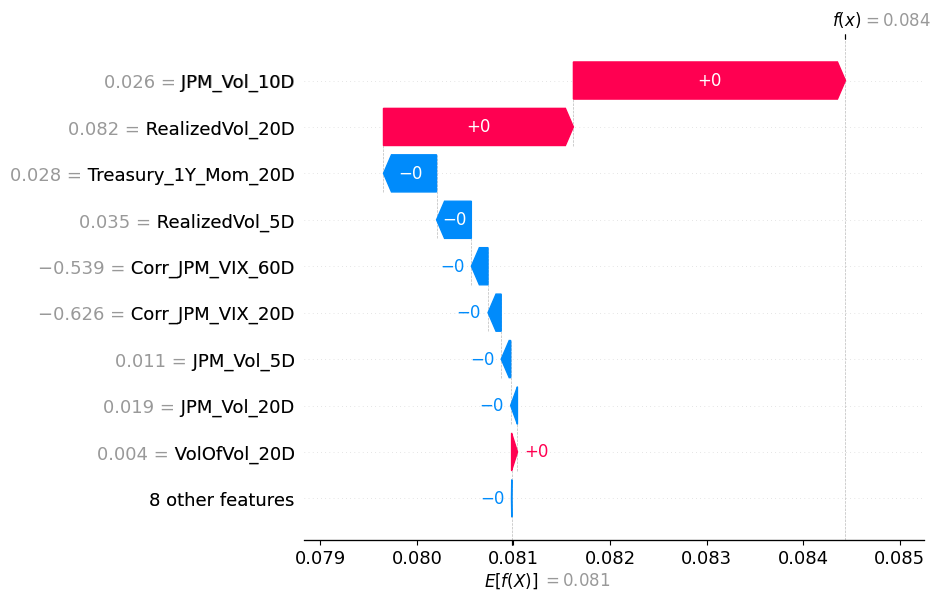

In [339]:
shap.plots.waterfall(shap_values[top_pos])

In [340]:
import matplotlib.pyplot as plt

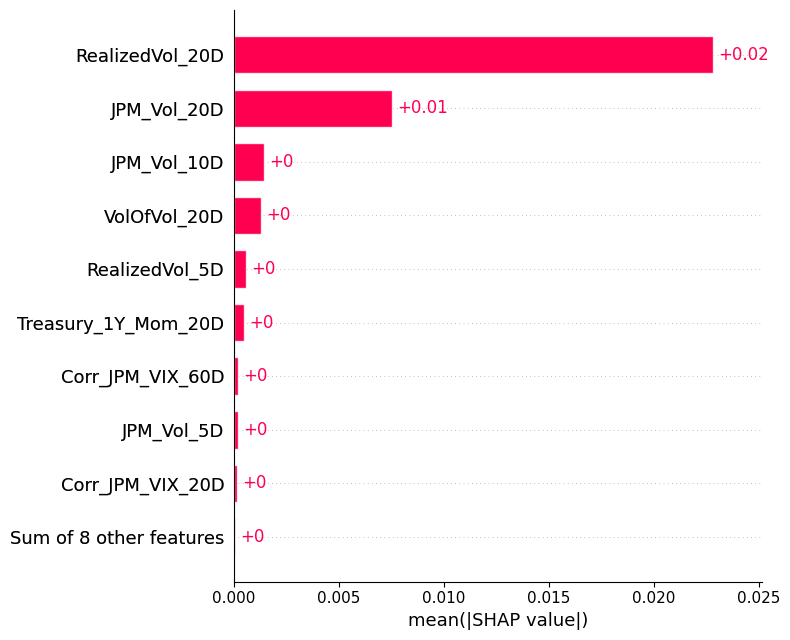

In [341]:
plt.figure()
shap.plots.bar(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_bar_gbr.png", dpi=300, bbox_inches="tight")
plt.show()

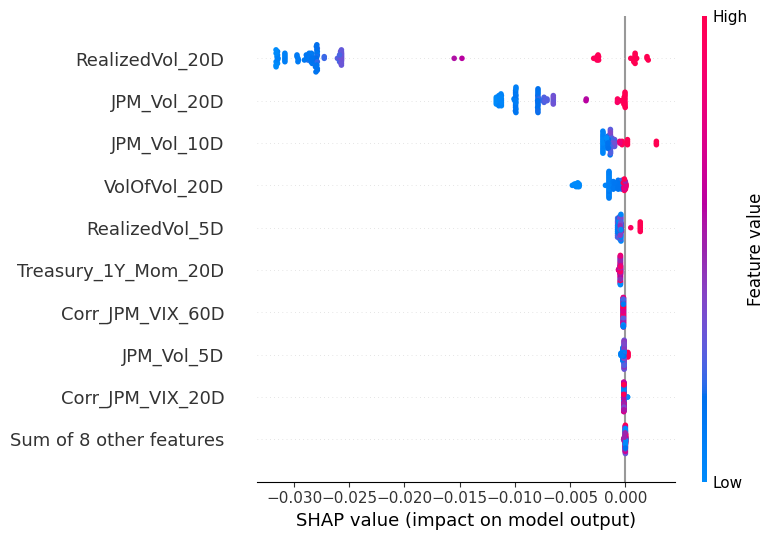

In [342]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm_gbr.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

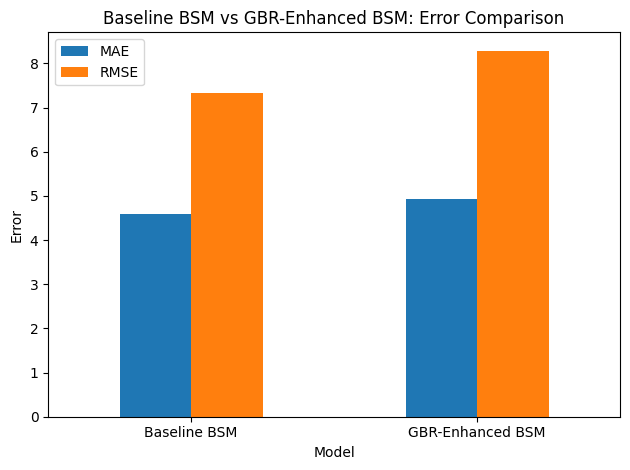

In [343]:
plt.figure(figsize=(8, 5))
benchmark_comparison_summary.set_index("Model").plot(kind="bar")
plt.title("Baseline BSM vs GBR-Enhanced BSM: Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/error_comparison_bar.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x500 with 0 Axes>

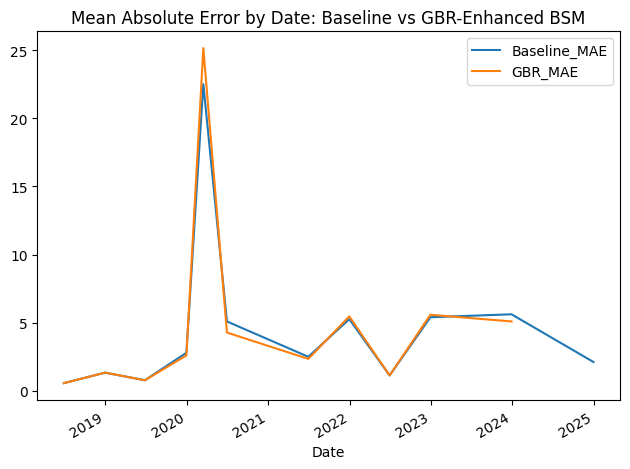

In [344]:
plt.figure(figsize=(12, 5))
by_date_summary.plot(x="Date", y=["Baseline_MAE", "GBR_MAE"])
plt.title("Mean Absolute Error by Date: Baseline vs GBR-Enhanced BSM")
plt.tight_layout()
plt.savefig("outputs/mae_by_date.png", dpi=300, bbox_inches="tight")
plt.show()

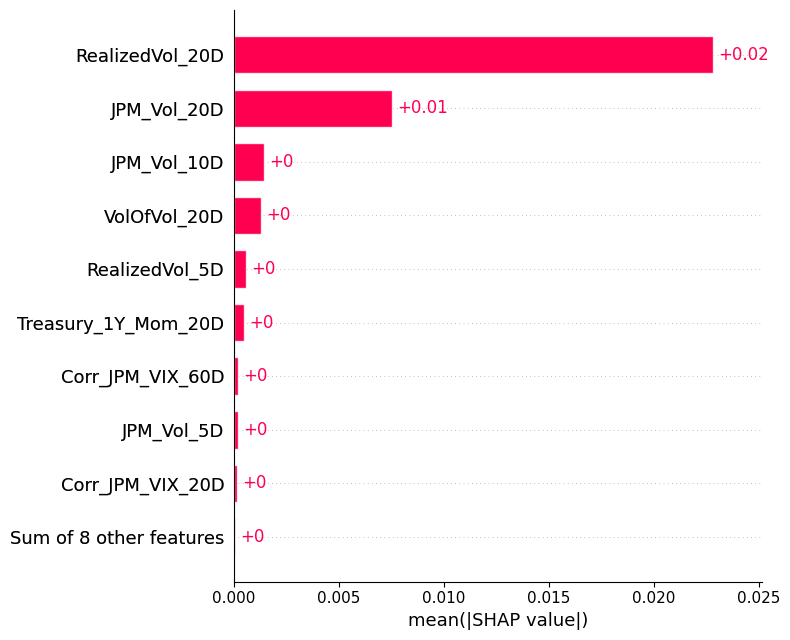

In [345]:
import matplotlib.pyplot as plt

plt.figure()
shap.plots.bar(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_bar_gbr.png", dpi=300, bbox_inches="tight")
plt.show()

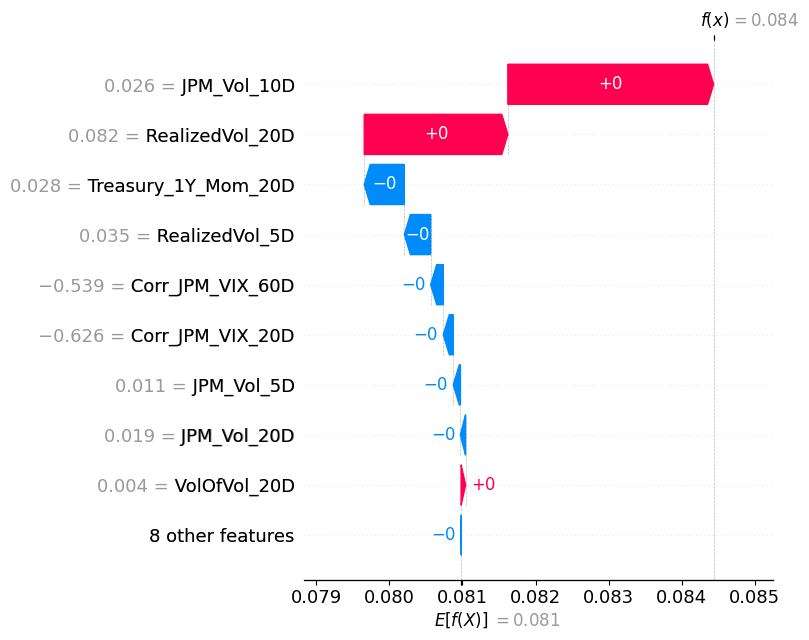

In [346]:
plt.figure()
shap.plots.waterfall(shap_values[top_pos], show=False)
plt.tight_layout()
plt.savefig("outputs/shap_waterfall_gbr.png", dpi=300, bbox_inches="tight")
plt.show()

In [347]:
final_ml_pricing_data.columns.tolist()

['Date',
 'FutureRealizedVol20D',
 'PredictedVol_GBR_Final',
 'JPM_Close',
 'VIX_Close',
 'Treasury_1Y',
 'Treasury_3M',
 'Treasury_6M',
 'JPM_Return',
 'JPM_LogReturn',
 'VIX_Return',
 'Treasury_1Y_Change',
 'Treasury_1Y_Mom_5D',
 'Treasury_1Y_Mom_20D',
 'Corr_JPM_VIX_20D',
 'Corr_JPM_VIX_60D',
 'RealizedVol_5D',
 'RealizedVol_20D',
 'JPM_Vol_20D',
 'VolOfVol_20D',
 'JPM_Vol_5D',
 'JPM_Vol_10D',
 'Sigma_Annual',
 'RiskFree_1Y',
 'ChooserPrice_BSM',
 'BSM_Call',
 'BSM_Put',
 'ChooserPrice_q0',
 'ChooserPrice_q2pct',
 'ChooserPrice_q3pct',
 'Diff_q2_minus_q0',
 'Diff_q3_minus_q0',
 'FinalPredictedSigma_Annual',
 'BaselineSigma_Annual',
 'ChooserPrice_BSM_Baseline',
 'ChooserPrice_GBR_Final',
 'Diff_FinalML_minus_BSM']

In [348]:
scenario_data = final_ml_pricing_data.copy()

In [349]:
K = 150
T = 1.0
tc = 0.5
q = 0.02

In [350]:
scenario_data["Baseline_Base"] = scenario_data["ChooserPrice_BSM_Baseline"]
scenario_data["ML_Base"] = scenario_data["ChooserPrice_GBR_Final"]

In [351]:
scenario_data["Baseline_VolSpike"] = scenario_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["BaselineSigma_Annual"] * 1.5,
        T=T,
        tc=tc
    ),
    axis=1
)

In [352]:
scenario_data["ML_VolSpike"] = scenario_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"],
        q=q,
        sigma=row["FinalPredictedSigma_Annual"] * 1.5,
        T=T,
        tc=tc
    ),
    axis=1
)

In [353]:
scenario_data["Baseline_RateHike"] = scenario_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"] + 0.02,
        q=q,
        sigma=row["BaselineSigma_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

In [354]:
scenario_data["ML_RateHike"] = scenario_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"] + 0.02,
        q=q,
        sigma=row["FinalPredictedSigma_Annual"],
        T=T,
        tc=tc
    ),
    axis=1
)

In [355]:
scenario_data["Baseline_CombinedShock"] = scenario_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"] + 0.02,
        q=q,
        sigma=row["BaselineSigma_Annual"] * 1.5,
        T=T,
        tc=tc
    ),
    axis=1
)

In [356]:
scenario_data["ML_CombinedShock"] = scenario_data.apply(
    lambda row: chooser_option_price(
        S=row["JPM_Close"],
        K=K,
        r=row["RiskFree_1Y"] + 0.02,
        q=q,
        sigma=row["FinalPredictedSigma_Annual"] * 1.5,
        T=T,
        tc=tc
    ),
    axis=1
)

In [357]:
scenario_summary = pd.DataFrame({
    "Scenario": [
        "Baseline Base",
        "Baseline Vol Spike",
        "Baseline Rate Hike",
        "Baseline Combined Shock",
        "ML Base",
        "ML Vol Spike",
        "ML Rate Hike",
        "ML Combined Shock"
    ],
    "MeanPrice": [
        scenario_data["Baseline_Base"].mean(),
        scenario_data["Baseline_VolSpike"].mean(),
        scenario_data["Baseline_RateHike"].mean(),
        scenario_data["Baseline_CombinedShock"].mean(),
        scenario_data["ML_Base"].mean(),
        scenario_data["ML_VolSpike"].mean(),
        scenario_data["ML_RateHike"].mean(),
        scenario_data["ML_CombinedShock"].mean()
    ]
})

scenario_summary

,Scenario,MeanPrice
0,Baseline Base,38.652544
1,Baseline Vol Spike,46.661229
2,Baseline Rate Hike,37.827986
3,Baseline Combined Shock,45.858791
4,ML Base,38.621532
5,ML Vol Spike,46.615138
6,ML Rate Hike,37.794272
7,ML Combined Shock,45.809833


In [358]:
scenario_change_summary = pd.DataFrame({
    "Scenario": [
        "Baseline Vol Spike",
        "Baseline Rate Hike",
        "Baseline Combined Shock",
        "ML Vol Spike",
        "ML Rate Hike",
        "ML Combined Shock"
    ],
    "MeanChange_vs_Base": [
        (scenario_data["Baseline_VolSpike"] - scenario_data["Baseline_Base"]).mean(),
        (scenario_data["Baseline_RateHike"] - scenario_data["Baseline_Base"]).mean(),
        (scenario_data["Baseline_CombinedShock"] - scenario_data["Baseline_Base"]).mean(),
        (scenario_data["ML_VolSpike"] - scenario_data["ML_Base"]).mean(),
        (scenario_data["ML_RateHike"] - scenario_data["ML_Base"]).mean(),
        (scenario_data["ML_CombinedShock"] - scenario_data["ML_Base"]).mean()
    ]
})

scenario_change_summary

,Scenario,MeanChange_vs_Base
0,Baseline Vol Spike,8.008685
1,Baseline Rate Hike,-0.824559
2,Baseline Combined Shock,7.206246
3,ML Vol Spike,7.993605
4,ML Rate Hike,-0.827261
5,ML Combined Shock,7.188300


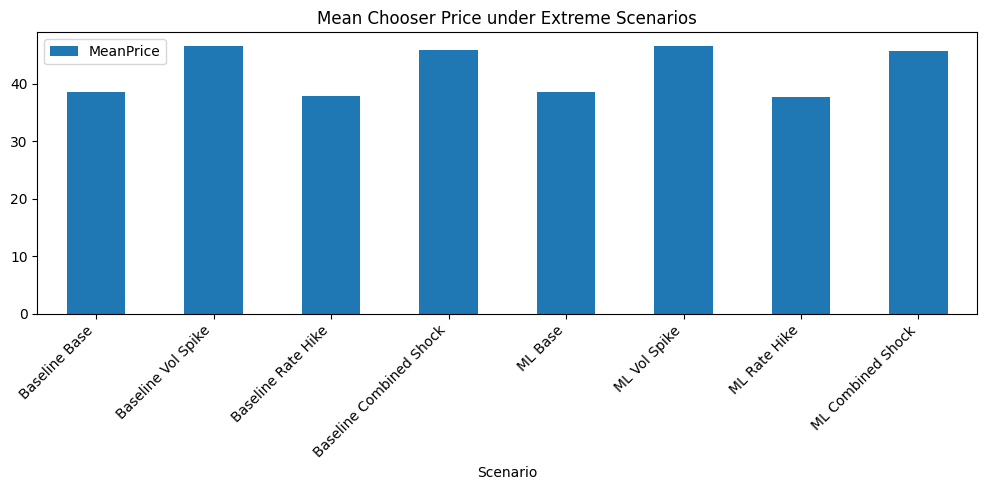

In [359]:
scenario_summary.plot(
    x="Scenario",
    y="MeanPrice",
    kind="bar",
    figsize=(10, 5),
    title="Mean Chooser Price under Extreme Scenarios"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

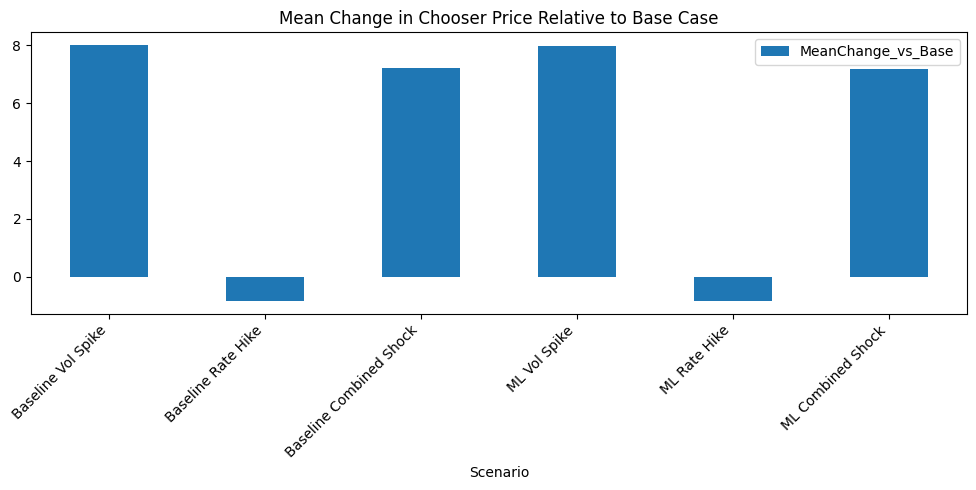

In [360]:
scenario_change_summary.plot(
    x="Scenario",
    y="MeanChange_vs_Base",
    kind="bar",
    figsize=(10, 5),
    title="Mean Change in Chooser Price Relative to Base Case"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [361]:
example_row = scenario_data.iloc[0][[
    "Baseline_Base",
    "Baseline_VolSpike",
    "Baseline_RateHike",
    "Baseline_CombinedShock",
    "ML_Base",
    "ML_VolSpike",
    "ML_RateHike",
    "ML_CombinedShock"
]]
example_row

Baseline_Base             41.034349
Baseline_VolSpike         46.275554
Baseline_RateHike         38.473987
Baseline_CombinedShock    44.110291
ML_Base                   40.764418
ML_VolSpike               45.558903
ML_RateHike                38.17031
ML_CombinedShock          43.356282
Name: 0, dtype: object

In [362]:
scenario_data.to_csv("data/processed/week7_extreme_scenario_results.csv", index=False)
scenario_summary.to_csv("outputs/week7_extreme_scenario_summary.csv", index=False)
scenario_change_summary.to_csv("outputs/week7_extreme_scenario_change_summary.csv", index=False)

In [364]:
scenario_data["Date"] = pd.to_datetime(scenario_data["Date"])
scenario_data["Year"] = scenario_data["Date"].dt.year

scenario_data["Regime"] = scenario_data["Year"].apply(
    lambda x: "Stress_2020" if x == 2020 else "Normal"
)

scenario_data[["Date", "Year", "Regime"]].head()

,Date,Year,Regime
0,2018-04-26,2018,Normal
1,2018-04-27,2018,Normal
2,2018-04-30,2018,Normal
3,2018-05-01,2018,Normal
4,2018-05-02,2018,Normal


In [365]:
regime_summary = scenario_data.groupby("Regime").agg(
    Baseline_Base=("Baseline_Base", "mean"),
    Baseline_VolSpike=("Baseline_VolSpike", "mean"),
    Baseline_RateHike=("Baseline_RateHike", "mean"),
    Baseline_CombinedShock=("Baseline_CombinedShock", "mean"),
    ML_Base=("ML_Base", "mean"),
    ML_VolSpike=("ML_VolSpike", "mean"),
    ML_RateHike=("ML_RateHike", "mean"),
    ML_CombinedShock=("ML_CombinedShock", "mean")
).reset_index()

regime_summary

,Regime,Baseline_Base,Baseline_VolSpike,Baseline_RateHike,Baseline_CombinedShock,ML_Base,ML_VolSpike,ML_RateHike,ML_CombinedShock
0,Normal,35.502614,42.721695,34.934382,42.136679,35.512364,42.754880,34.942354,42.167858
1,Stress_2020,56.431601,68.897022,54.160263,66.867389,56.170517,68.403467,53.891261,66.366118


In [366]:
regime_change_summary = pd.DataFrame({
    "Regime": ["Normal", "Stress_2020"],
    "Baseline_VolSpike_Change": [
        (scenario_data.loc[scenario_data["Regime"] == "Normal", "Baseline_VolSpike"]
         - scenario_data.loc[scenario_data["Regime"] == "Normal", "Baseline_Base"]).mean(),
        (scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "Baseline_VolSpike"]
         - scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "Baseline_Base"]).mean()
    ],
    "Baseline_RateHike_Change": [
        (scenario_data.loc[scenario_data["Regime"] == "Normal", "Baseline_RateHike"]
         - scenario_data.loc[scenario_data["Regime"] == "Normal", "Baseline_Base"]).mean(),
        (scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "Baseline_RateHike"]
         - scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "Baseline_Base"]).mean()
    ],
    "Baseline_CombinedShock_Change": [
        (scenario_data.loc[scenario_data["Regime"] == "Normal", "Baseline_CombinedShock"]
         - scenario_data.loc[scenario_data["Regime"] == "Normal", "Baseline_Base"]).mean(),
        (scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "Baseline_CombinedShock"]
         - scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "Baseline_Base"]).mean()
    ],
    "ML_VolSpike_Change": [
        (scenario_data.loc[scenario_data["Regime"] == "Normal", "ML_VolSpike"]
         - scenario_data.loc[scenario_data["Regime"] == "Normal", "ML_Base"]).mean(),
        (scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "ML_VolSpike"]
         - scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "ML_Base"]).mean()
    ],
    "ML_RateHike_Change": [
        (scenario_data.loc[scenario_data["Regime"] == "Normal", "ML_RateHike"]
         - scenario_data.loc[scenario_data["Regime"] == "Normal", "ML_Base"]).mean(),
        (scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "ML_RateHike"]
         - scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "ML_Base"]).mean()
    ],
    "ML_CombinedShock_Change": [
        (scenario_data.loc[scenario_data["Regime"] == "Normal", "ML_CombinedShock"]
         - scenario_data.loc[scenario_data["Regime"] == "Normal", "ML_Base"]).mean(),
        (scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "ML_CombinedShock"]
         - scenario_data.loc[scenario_data["Regime"] == "Stress_2020", "ML_Base"]).mean()
    ]
})

regime_change_summary

,Regime,Baseline_VolSpike_Change,Baseline_RateHike_Change,Baseline_CombinedShock_Change,ML_VolSpike_Change,ML_RateHike_Change,ML_CombinedShock_Change
0,Normal,7.219081,-0.568232,6.634066,7.242517,-0.570009,6.655494
1,Stress_2020,12.465421,-2.271338,10.435787,12.232951,-2.279256,10.195602


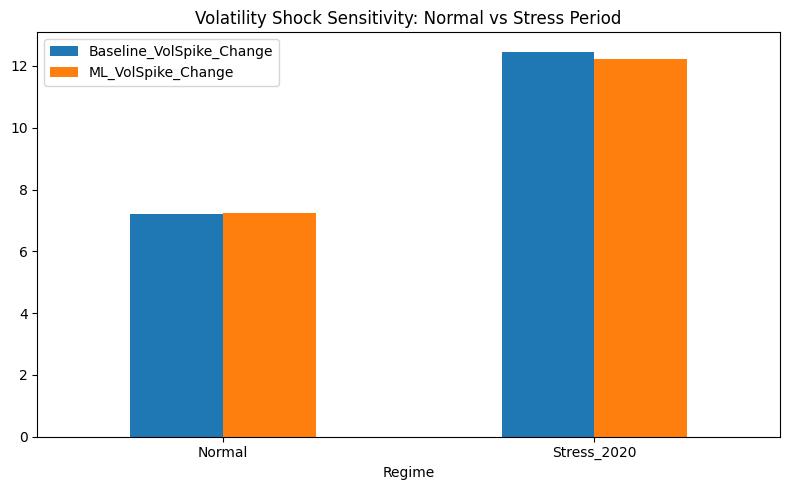

In [367]:
regime_change_summary.plot(
    x="Regime",
    y=["Baseline_VolSpike_Change", "ML_VolSpike_Change"],
    kind="bar",
    figsize=(8, 5),
    title="Volatility Shock Sensitivity: Normal vs Stress Period"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

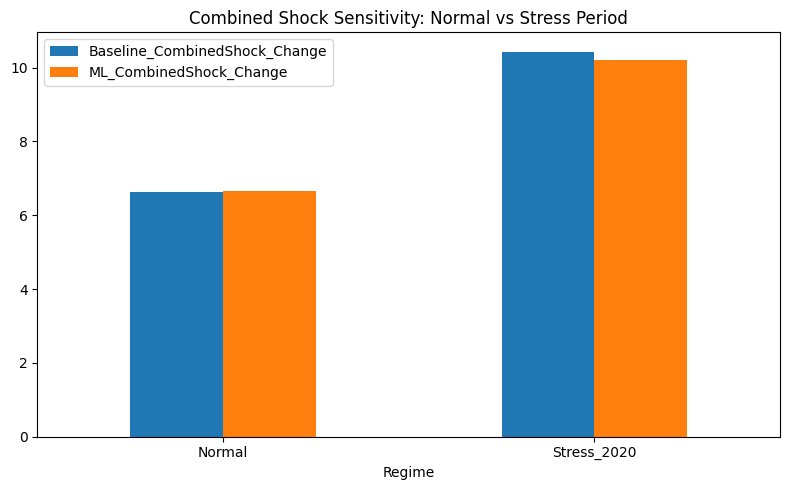

In [368]:
regime_change_summary.plot(
    x="Regime",
    y=["Baseline_CombinedShock_Change", "ML_CombinedShock_Change"],
    kind="bar",
    figsize=(8, 5),
    title="Combined Shock Sensitivity: Normal vs Stress Period"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [369]:
regime_summary.to_csv("outputs/week7_regime_summary.csv", index=False)
regime_change_summary.to_csv("outputs/week7_regime_change_summary.csv", index=False)

<Figure size 1000x500 with 0 Axes>

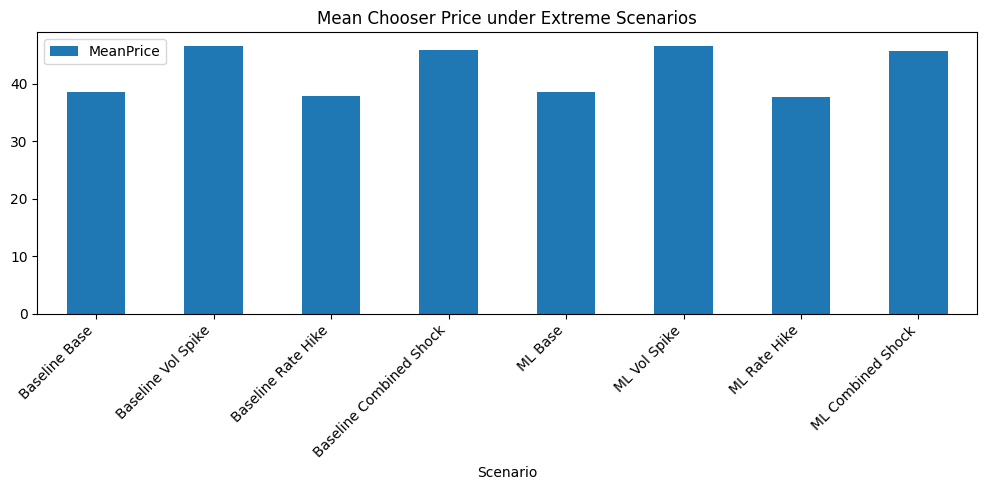

In [370]:
plt.figure(figsize=(10, 5))
scenario_summary.plot(
    x="Scenario",
    y="MeanPrice",
    kind="bar",
    figsize=(10, 5),
    title="Mean Chooser Price under Extreme Scenarios"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/week7_mean_price_extreme_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x500 with 0 Axes>

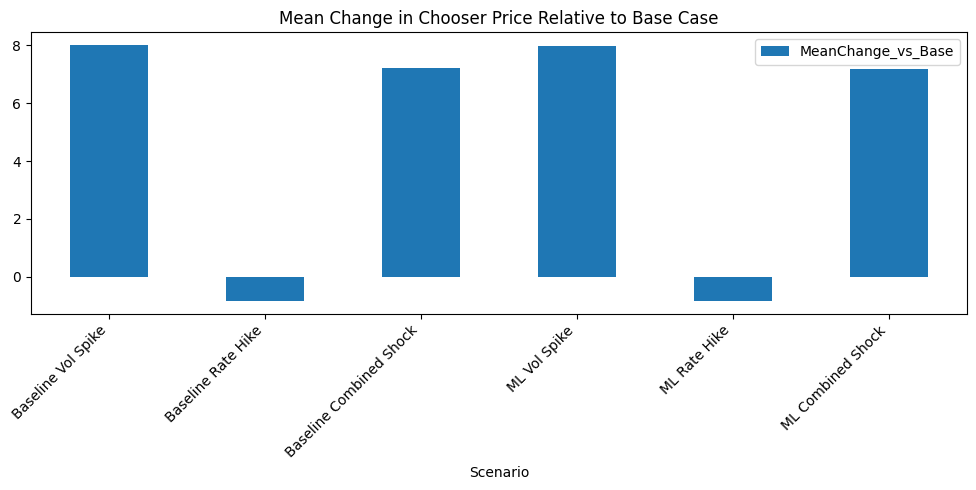

In [371]:
plt.figure(figsize=(10, 5))
scenario_change_summary.plot(
    x="Scenario",
    y="MeanChange_vs_Base",
    kind="bar",
    figsize=(10, 5),
    title="Mean Change in Chooser Price Relative to Base Case"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/week7_mean_change_vs_base.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

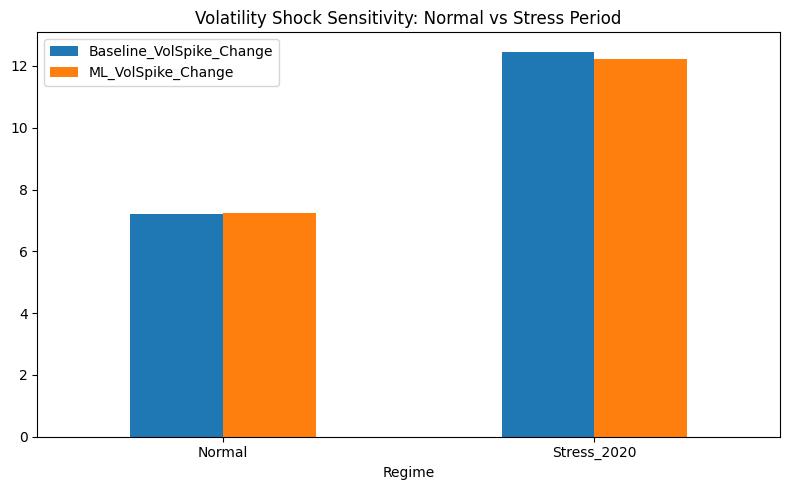

In [372]:
plt.figure(figsize=(8, 5))
regime_change_summary.plot(
    x="Regime",
    y=["Baseline_VolSpike_Change", "ML_VolSpike_Change"],
    kind="bar",
    figsize=(8, 5),
    title="Volatility Shock Sensitivity: Normal vs Stress Period"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/week7_vol_shock_normal_vs_stress.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

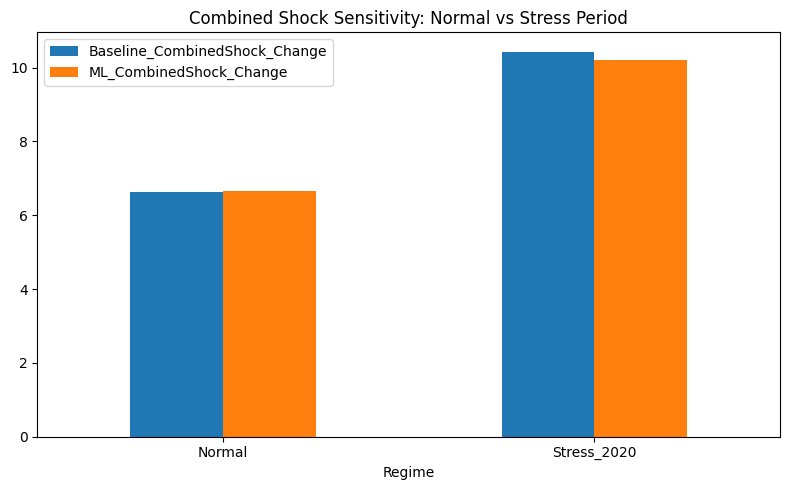

In [373]:
plt.figure(figsize=(8, 5))
regime_change_summary.plot(
    x="Regime",
    y=["Baseline_CombinedShock_Change", "ML_CombinedShock_Change"],
    kind="bar",
    figsize=(8, 5),
    title="Combined Shock Sensitivity: Normal vs Stress Period"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/week7_combined_shock_normal_vs_stress.png", dpi=300, bbox_inches="tight")
plt.show()

In [375]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [376]:
benchmark_sig = benchmark_final.copy()
benchmark_sig["Date"] = pd.to_datetime(benchmark_sig["Date"])
benchmark_sig["AbsError_Improvement"] = (
    benchmark_sig["AbsError_Baseline"] - benchmark_sig["AbsError_GBR_Final"]
)
benchmark_sig["PctImprovement"] = (
    benchmark_sig["AbsError_Improvement"] / benchmark_sig["AbsError_Baseline"].replace(0, np.nan)
)

In [377]:
def assign_regime(date):
    if pd.Timestamp("2020-02-20") <= date <= pd.Timestamp("2020-03-31"):
        return "Crash_2020"
    elif pd.Timestamp("2020-04-01") <= date <= pd.Timestamp("2020-08-31"):
        return "Recovery_2020"
    elif pd.Timestamp("2020-09-01") <= date <= pd.Timestamp("2020-12-31"):
        return "Late2020"
    elif date.year == 2020:
        return "Other_2020"
    else:
        return "Normal"

benchmark_sig["Regime"] = benchmark_sig["Date"].apply(assign_regime)

In [378]:
def significance_report(df, group_name="All"):
    x = df["AbsError_Improvement"].dropna().values
    
    if len(x) < 5:
        return {
            "Group": group_name,
            "N": len(x),
            "MeanImprovement": np.nan,
            "MedianImprovement": np.nan,
            "ImprovementRatio": np.nan,
            "Paired_t_pvalue": np.nan,
            "Wilcoxon_pvalue": np.nan,
            "Bootstrap_CI_Low": np.nan,
            "Bootstrap_CI_High": np.nan
        }
    
    # paired t-test against zero
    t_stat, t_p = stats.ttest_1samp(x, 0.0, alternative="greater")
    
    # wilcoxon
    try:
        w_stat, w_p = stats.wilcoxon(x, alternative="greater")
    except:
        w_p = np.nan
    
    # bootstrap CI
    boot_means = []
    rng = np.random.default_rng(42)
    for _ in range(5000):
        sample = rng.choice(x, size=len(x), replace=True)
        boot_means.append(sample.mean())
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    
    return {
        "Group": group_name,
        "N": len(x),
        "MeanImprovement": np.mean(x),
        "MedianImprovement": np.median(x),
        "ImprovementRatio": np.mean(x > 0),
        "Paired_t_pvalue": t_p,
        "Wilcoxon_pvalue": w_p,
        "Bootstrap_CI_Low": ci_low,
        "Bootstrap_CI_High": ci_high
    }

In [379]:
sig_results = []
sig_results.append(significance_report(benchmark_sig, "All"))

for g, subdf in benchmark_sig.groupby("Regime"):
    sig_results.append(significance_report(subdf, g))

sig_results_df = pd.DataFrame(sig_results)
sig_results_df
sig_results_df.to_csv("outputs/week7_significance_tests.csv", index=False)

In [380]:
tail_df = scenario_data.copy()

tail_df["Baseline_VolSpike_Return"] = (
    tail_df["Baseline_VolSpike"] / tail_df["Baseline_Base"] - 1
)
tail_df["ML_VolSpike_Return"] = (
    tail_df["ML_VolSpike"] / tail_df["ML_Base"] - 1
)

tail_df["Baseline_RateHike_Return"] = (
    tail_df["Baseline_RateHike"] / tail_df["Baseline_Base"] - 1
)
tail_df["ML_RateHike_Return"] = (
    tail_df["ML_RateHike"] / tail_df["ML_Base"] - 1
)

tail_df["Baseline_Combined_Return"] = (
    tail_df["Baseline_CombinedShock"] / tail_df["Baseline_Base"] - 1
)
tail_df["ML_Combined_Return"] = (
    tail_df["ML_CombinedShock"] / tail_df["ML_Base"] - 1
)

In [381]:
def tail_stats(series, name):
    s = series.dropna()
    return {
        "Scenario": name,
        "Mean": s.mean(),
        "Std": s.std(),
        "Median": s.median(),
        "P95": s.quantile(0.95),
        "P99": s.quantile(0.99),
        "Max": s.max(),
        "Share_gt_20pct": (s > 0.20).mean()
    }

In [382]:
tail_stats_df = pd.DataFrame([
    tail_stats(tail_df["Baseline_VolSpike_Return"], "Baseline_VolSpike"),
    tail_stats(tail_df["ML_VolSpike_Return"], "ML_VolSpike"),
    tail_stats(tail_df["Baseline_RateHike_Return"], "Baseline_RateHike"),
    tail_stats(tail_df["ML_RateHike_Return"], "ML_RateHike"),
    tail_stats(tail_df["Baseline_Combined_Return"], "Baseline_Combined"),
    tail_stats(tail_df["ML_Combined_Return"], "ML_Combined"),
])

tail_stats_df.to_csv("outputs/week7_tail_statistics.csv", index=False)
tail_stats_df

,Scenario,Mean,Std,Median,P95,P99,Max,Share_gt_20pct
0,Baseline_VolSpike,0.253819,0.173517,0.232823,0.495047,0.497618,0.498932,0.543129
1,ML_VolSpike,0.254869,0.173085,0.231593,0.495186,0.497723,0.498842,0.538370
2,Baseline_RateHike,-0.021978,0.050476,-0.036713,0.066966,0.112112,0.150075,0.000000
3,ML_RateHike,-0.022286,0.049166,-0.036647,0.065704,0.099681,0.115990,0.000000
4,Baseline_Combined,0.231762,0.183201,0.203382,0.488293,0.497823,0.505969,0.503272
5,ML_Combined,0.232539,0.182774,0.202497,0.488209,0.497033,0.504535,0.505651


In [383]:
tail_df["VolShock_Diff_ML_minus_BSM"] = tail_df["ML_VolSpike_Return"] - tail_df["Baseline_VolSpike_Return"]

extreme_vol = tail_df[tail_df["Baseline_VolSpike_Return"] > 0.20].copy()
extreme_vol_summary = extreme_vol[[
    "Baseline_VolSpike_Return",
    "ML_VolSpike_Return",
    "VolShock_Diff_ML_minus_BSM"
]].describe()

extreme_vol_summary.to_csv("outputs/week7_extreme_vol_samples_summary.csv")
extreme_vol_summary

,Baseline_VolSpike_Return,ML_VolSpike_Return,VolShock_Diff_ML_minus_BSM
count,913.000000,913.000000,913.000000
mean,0.396708,0.397191,0.000483
std,0.092712,0.092740,0.008687
min,0.200185,0.183157,-0.037968
25%,0.329877,0.332896,-0.001910
50%,0.421809,0.422894,0.000011
75%,0.480269,0.480857,0.001173
max,0.498932,0.498842,0.075294


In [384]:
tail_df["Date"] = pd.to_datetime(tail_df["Date"])
tail_df["Regime"] = tail_df["Date"].apply(assign_regime)

In [385]:
regime_tail = tail_df.groupby("Regime").agg(
    Baseline_VolSpike_Mean=("Baseline_VolSpike_Return", "mean"),
    Baseline_VolSpike_P95=("Baseline_VolSpike_Return", lambda x: x.quantile(0.95)),
    Baseline_VolSpike_Share_gt20=("Baseline_VolSpike_Return", lambda x: (x > 0.20).mean()),
    ML_VolSpike_Mean=("ML_VolSpike_Return", "mean"),
    ML_VolSpike_P95=("ML_VolSpike_Return", lambda x: x.quantile(0.95)),
    ML_VolSpike_Share_gt20=("ML_VolSpike_Return", lambda x: (x > 0.20).mean()),
).reset_index()

regime_tail.to_csv("outputs/week7_regime_tail_statistics.csv", index=False)
regime_tail

,Regime,Baseline_VolSpike_Mean,Baseline_VolSpike_P95,Baseline_VolSpike_Share_gt20,ML_VolSpike_Mean,ML_VolSpike_P95,ML_VolSpike_Share_gt20
0,Crash_2020,0.310336,0.367293,1.000000,0.322355,0.364465,1.000000
1,Late2020,0.174637,0.390313,0.435294,0.171215,0.388593,0.423529
2,Normal,0.259601,0.495650,0.534314,0.261317,0.495694,0.530112
3,Other_2020,0.349035,0.396775,1.000000,0.349211,0.396368,1.000000
4,Recovery_2020,0.194302,0.330317,0.481132,0.187248,0.329663,0.471698


In [386]:
sigma_df = final_ml_pricing_data.copy()
sigma_df["Date"] = pd.to_datetime(sigma_df["Date"])

sigma_df["SigmaGap"] = (
    sigma_df["FinalPredictedSigma_Annual"] - sigma_df["BaselineSigma_Annual"]
)
sigma_df["AbsSigmaGap"] = sigma_df["SigmaGap"].abs()

sigma_gap_summary = sigma_df["SigmaGap"].describe()
sigma_gap_summary.to_csv("outputs/week7_sigma_gap_summary.csv")
sigma_gap_summary

count    1681.000000
mean       -0.000303
std         0.016107
min        -0.156226
25%        -0.005163
50%        -0.000059
75%         0.004726
max         0.239915
Name: SigmaGap, dtype: float64

In [387]:
sigma_corr = sigma_df[["BaselineSigma_Annual", "FinalPredictedSigma_Annual"]].corr()
sigma_corr.to_csv("outputs/week7_sigma_correlation.csv")
sigma_corr

,BaselineSigma_Annual,FinalPredictedSigma_Annual
BaselineSigma_Annual,1.000000,0.995048
FinalPredictedSigma_Annual,0.995048,1.000000


In [388]:
sigma_df["PriceGap"] = (
    sigma_df["ChooserPrice_GBR_Final"] - sigma_df["ChooserPrice_BSM_Baseline"]
)
sigma_df["AbsPriceGap"] = sigma_df["PriceGap"].abs()

corr_sigma_price = sigma_df[["AbsSigmaGap", "AbsPriceGap"]].corr()
corr_sigma_price.to_csv("outputs/week7_sigma_price_gap_correlation.csv")
corr_sigma_price

,AbsSigmaGap,AbsPriceGap
AbsSigmaGap,1.000000,0.943781
AbsPriceGap,0.943781,1.000000


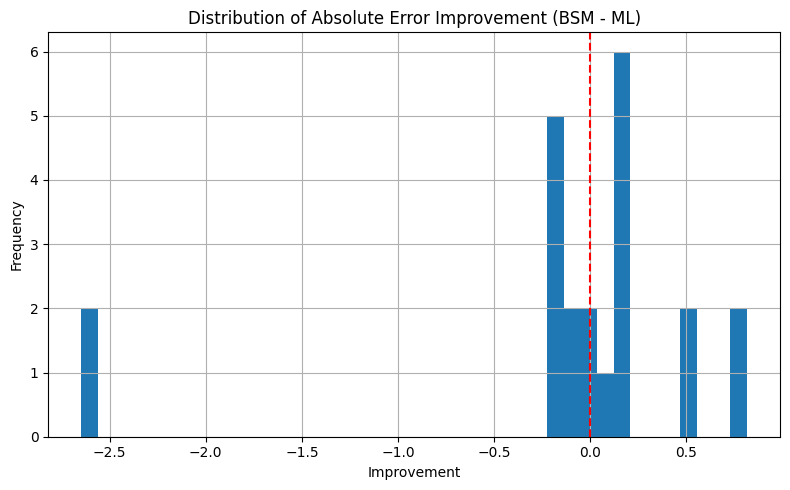

In [389]:
plt.figure(figsize=(8,5))
benchmark_sig["AbsError_Improvement"].hist(bins=40)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Absolute Error Improvement (BSM - ML)")
plt.xlabel("Improvement")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/week7_improvement_distribution.png", dpi=300)
plt.show()

<Figure size 1000x500 with 0 Axes>

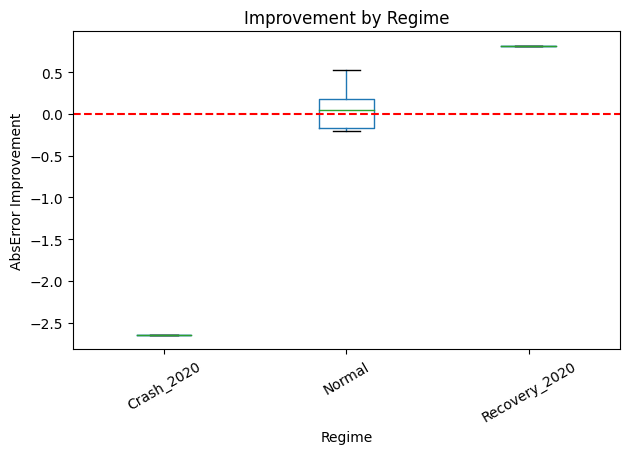

In [390]:
plt.figure(figsize=(10,5))
benchmark_sig.boxplot(column="AbsError_Improvement", by="Regime", grid=False)
plt.axhline(0, color="red", linestyle="--")
plt.title("Improvement by Regime")
plt.suptitle("")
plt.ylabel("AbsError Improvement")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/week7_improvement_by_regime.png", dpi=300)
plt.show()

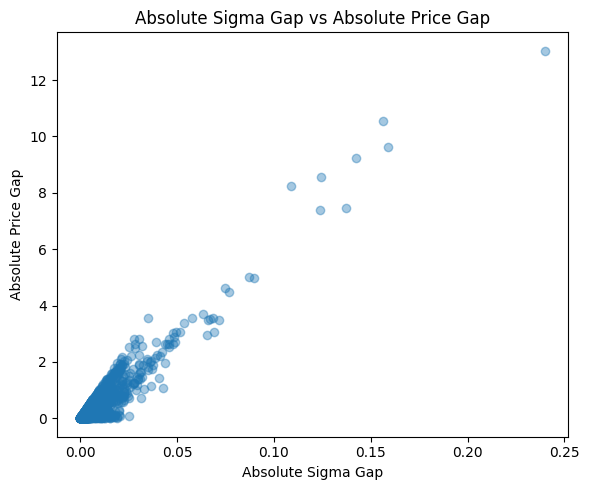

In [391]:
plt.figure(figsize=(6,5))
plt.scatter(sigma_df["AbsSigmaGap"], sigma_df["AbsPriceGap"], alpha=0.4)
plt.xlabel("Absolute Sigma Gap")
plt.ylabel("Absolute Price Gap")
plt.title("Absolute Sigma Gap vs Absolute Price Gap")
plt.tight_layout()
plt.savefig("outputs/week7_sigma_gap_vs_price_gap.png", dpi=300)
plt.show()

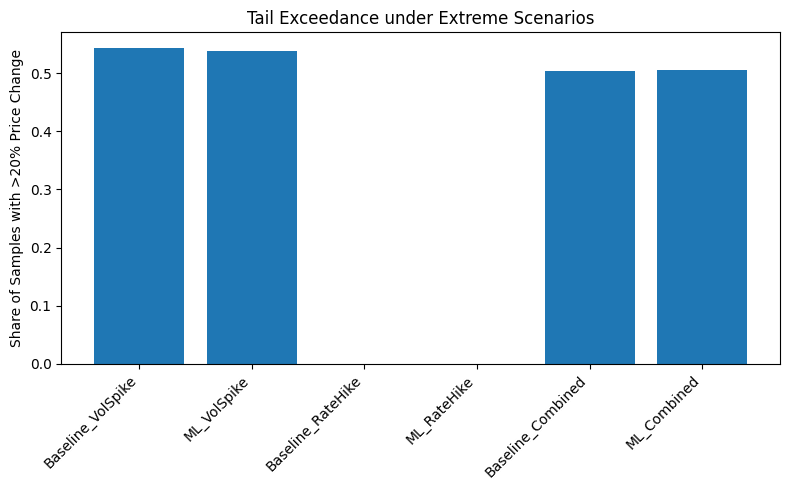

In [392]:
tail_plot_df = tail_stats_df[["Scenario", "Share_gt_20pct"]]

plt.figure(figsize=(8,5))
plt.bar(tail_plot_df["Scenario"], tail_plot_df["Share_gt_20pct"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share of Samples with >20% Price Change")
plt.title("Tail Exceedance under Extreme Scenarios")
plt.tight_layout()
plt.savefig("outputs/week7_tail_exceedance.png", dpi=300)
plt.show()